# Presentation boards

Boards for the talk, organized by section. Each render cell saves a PNG to `TALK_DIR` (default `notebooks/talk_boards/`) so slides can pull them directly.

In [21]:
import os, sys, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from board_style import draw_board
from data.othello import OthelloBoardState

%matplotlib inline

# Use a monospace font across all figures for the 1980s computer aesthetic.
plt.rcParams['font.family'] = 'monospace'

# Where PNGs land.  Created on demand.
TALK_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'talk_boards')
os.makedirs(TALK_DIR, exist_ok=True)

HIGHLIGHT_COLOR = 'orange'
OUTLINE_LW = 4.0


def render_board(state, highlight_cells, out_name, title=None,
                    figsize=(5, 5), show_coords=True, save=True):
    """Render an 8x8 board with the given cells outlined in orange.

    state:            (8, 8) numpy array, values in {-1, 0, 1}.
    highlight_cells:  iterable of (row, col) tuples to outline.
    out_name:         PNG filename (saved under TALK_DIR when save=True).
    """
    highlights = {
        (r, c): {'border': HIGHLIGHT_COLOR, 'border_lw': OUTLINE_LW}
        for r, c in highlight_cells
    }
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights, title=None,
                show_coords=show_coords)
    if save:
        out_path = os.path.join(TALK_DIR, out_name)
        plt.savefig(out_path, dpi=200, facecolor='white')
        print(f'  saved {out_path}')
    plt.show()

def compute_flank_lines(snapshot):
    """Flanked lines for a move: segments (played_cell -> flanker) for every
    direction whose run of opponent pieces is capped by a mover piece."""
    r, c = snapshot['cell']
    mover = 1 if snapshot['mover'] == 'black' else -1
    after = snapshot['state_after']
    flipped = set(tuple(x) for x in snapshot['flipped'])
    DIRS = [(-1, -1), (-1, 0), (-1, 1), (0, -1),
            (0, 1), (1, -1), (1, 0), (1, 1)]
    lines = []
    for dr, dc in DIRS:
        k = 1
        while (r + k * dr, c + k * dc) in flipped:
            k += 1
        if k > 1:                                   # >=1 flipped cell this way
            fr, fc = r + k * dr, c + k * dc          # the flanker
            if 0 <= fr < 8 and 0 <= fc < 8 and after[fr, fc] == mover:
                lines.append(((r, c), (fr, fc)))
    return lines


def render_board_lines(state, highlight_cells, lines, out_name, title=None,
                       figsize=(5, 5), show_coords=True, save=True):
    """Like render_board, but also draws an orange line from the middle of one
    cell to another (piece centers are at (col, row) in draw_board coords)."""
    highlights = {
        (r, c): {'border': HIGHLIGHT_COLOR, 'border_lw': OUTLINE_LW}
        for r, c in highlight_cells
    }
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights, title=None,
               show_coords=show_coords)
    for (r0, c0), (r1, c1) in lines:
        ax.plot([c0, c1], [r0, r1], color=HIGHLIGHT_COLOR, linewidth=OUTLINE_LW,
                solid_capstyle='round', zorder=5)
    if save:
        out_path = os.path.join(TALK_DIR, out_name)
        plt.savefig(out_path, dpi=200, facecolor='white')
        print(f'  saved {out_path}')
    plt.show()

## Section 1 — First four moves of a game

Each move gets two slides:
- **A**: the new piece is placed (orange outline marks it).
- **B**: all opponent pieces that get flipped by that move are shown flipped, with orange outlines.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move0_start.png


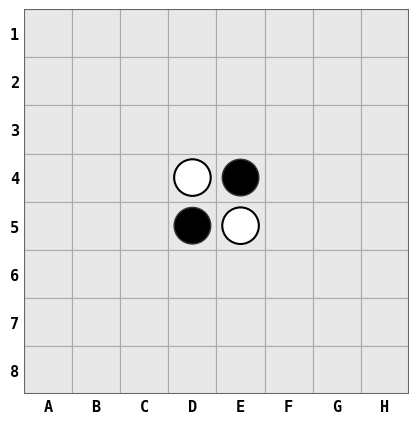

In [22]:
# Starting board (before any move).
start_state = np.zeros((8, 8), dtype=np.int8)
start_state[3, 3] = -1   # d4 white
start_state[3, 4] =  1   # e4 black
start_state[4, 3] =  1   # d5 black
start_state[4, 4] = -1   # e5 white

render_board(start_state,
             highlight_cells=[],
             out_name='move0_start.png',
             title='Starting position')

In [23]:
# Play 4 moves and capture per-move snapshots.  Seed for reproducibility.
SEED = 0
N_MOVES = 4

rng = random.Random(SEED)
board = OthelloBoardState()

snapshots = []
for i in range(N_MOVES):
    valid = board.get_valid_moves()
    if not valid:
        board.update([])
        valid = board.get_valid_moves()
        if not valid:
            break
    move = rng.choice(valid)
    r, c = move // 8, move % 8
    state_before = np.asarray(board.state, dtype=np.int8).reshape(8, 8).copy()
    board.update([move])
    state_after = np.asarray(board.state, dtype=np.int8).reshape(8, 8).copy()

    mover_color = int(state_after[r, c])   # +1 black / -1 white
    state_placed = state_before.copy()
    state_placed[r, c] = mover_color

    flipped = [(rr, cc) for rr in range(8) for cc in range(8)
                if (rr, cc) != (r, c)
                and state_before[rr, cc] != state_after[rr, cc]]

    snapshots.append({
        'move_idx': i + 1,
        'cell': (r, c),
        'mover': 'black' if mover_color == 1 else 'white',
        'state_placed': state_placed,
        'state_after': state_after,
        'flipped': flipped,
    })

for s in snapshots:
    print(f"Move {s['move_idx']}: {s['mover']} plays ({s['cell'][0]}, {s['cell'][1]}); "
          f"flips {len(s['flipped'])} piece(s) at {s['flipped']}")

Move 1: black plays (5, 4); flips 1 piece(s) at [(4, 4)]
Move 2: white plays (5, 3); flips 1 piece(s) at [(4, 3)]
Move 3: black plays (2, 2); flips 1 piece(s) at [(3, 3)]
Move 4: white plays (3, 5); flips 1 piece(s) at [(4, 4)]


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move1a_place.png


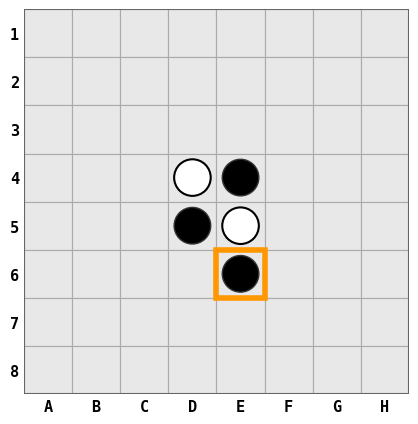

In [24]:
# Move 1A — piece placed, no flips yet
s = snapshots[0]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move1a2_flank.png


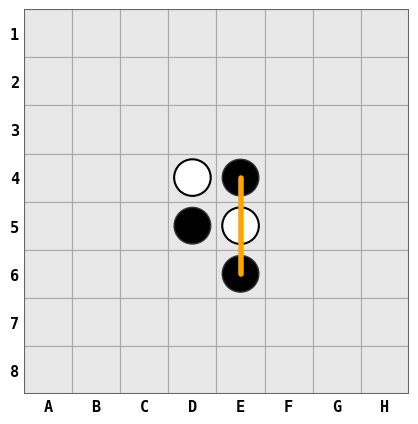

In [25]:
# Move 1 flank lines - orange line from played piece to each flanker
s = snapshots[0]
render_board_lines(s['state_placed'],
                   highlight_cells=[],
                   lines=compute_flank_lines(s),
                   out_name=f"move{s['move_idx']}a2_flank.png",
                   title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move1b_flip.png


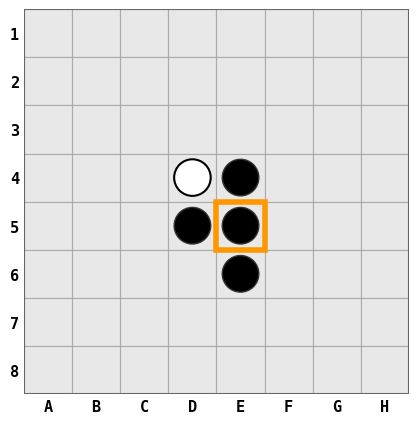

In [26]:
# Move 1B — flips resolved, flipped cells outlined
s = snapshots[0]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move2a_place.png


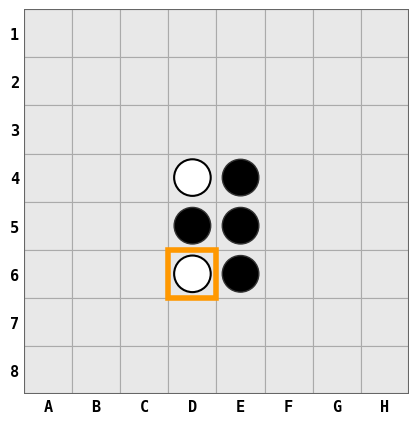

In [27]:
# Move 2A
s = snapshots[1]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move2a2_flank.png


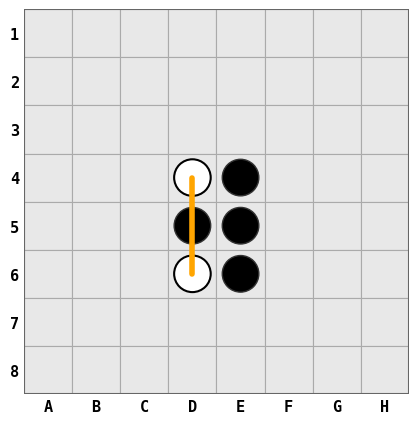

In [28]:
# Move 2 flank lines - orange line from played piece to each flanker
s = snapshots[1]
render_board_lines(s['state_placed'],
                   highlight_cells=[],
                   lines=compute_flank_lines(s),
                   out_name=f"move{s['move_idx']}a2_flank.png",
                   title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move2b_flip.png


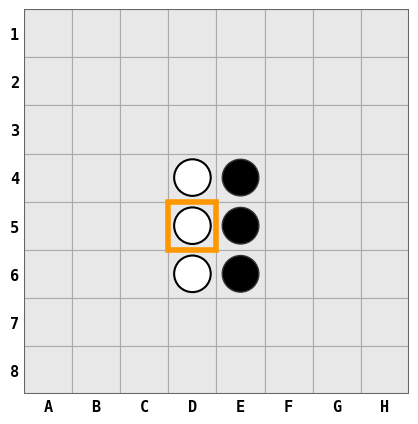

In [29]:
# Move 2B
s = snapshots[1]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move3a_place.png


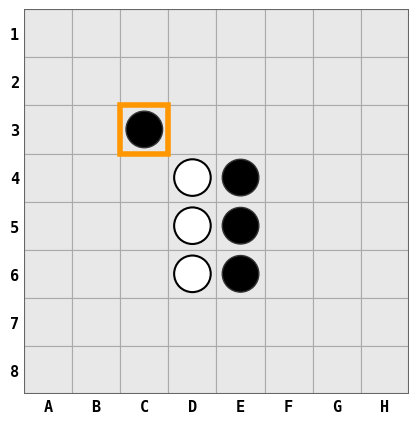

In [30]:
# Move 3A
s = snapshots[2]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move3a2_flank.png


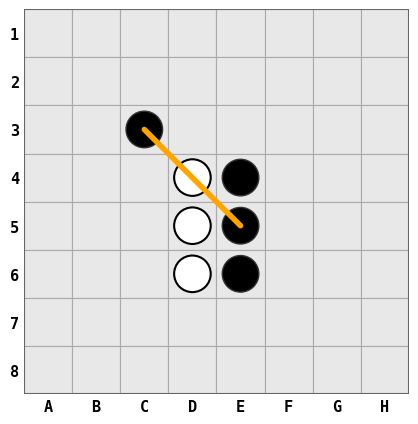

In [31]:
# Move 3 flank lines - orange line from played piece to each flanker
s = snapshots[2]
render_board_lines(s['state_placed'],
                   highlight_cells=[],
                   lines=compute_flank_lines(s),
                   out_name=f"move{s['move_idx']}a2_flank.png",
                   title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move3b_flip.png


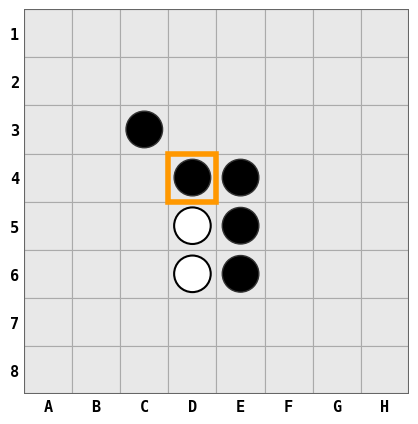

In [32]:
# Move 3B
s = snapshots[2]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move4a_place.png


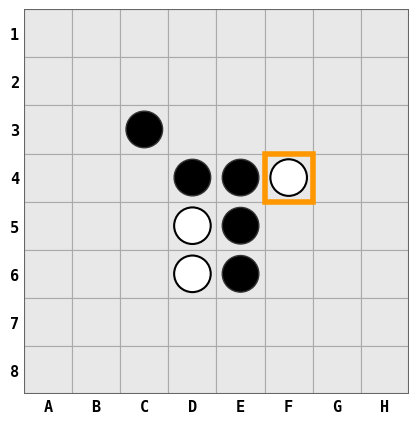

In [33]:
# Move 4A
s = snapshots[3]
render_board(s['state_placed'],
             highlight_cells=[s['cell']],
             out_name=f"move{s['move_idx']}a_place.png",
             title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move4a2_flank.png


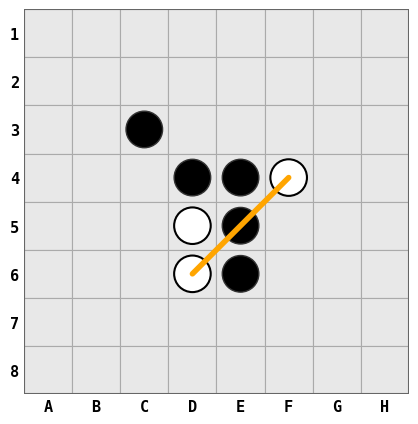

In [34]:
# Move 4 flank lines - orange line from played piece to each flanker
s = snapshots[3]
render_board_lines(s['state_placed'],
                   highlight_cells=[],
                   lines=compute_flank_lines(s),
                   out_name=f"move{s['move_idx']}a2_flank.png",
                   title=f"Move {s['move_idx']}")

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/move4b_flip.png


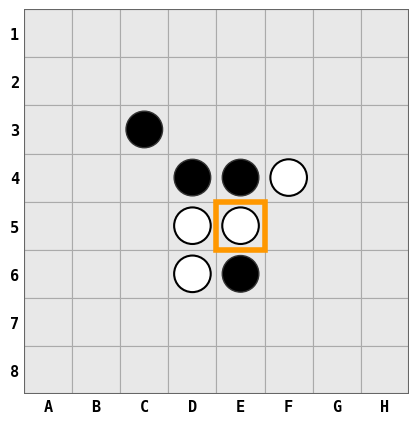

In [35]:
# Move 4B
s = snapshots[3]
render_board(s['state_after'],
             highlight_cells=s['flipped'],
             out_name=f"move{s['move_idx']}b_flip.png",
             title=f"Move {s['move_idx']}")

## Section 2 — Architecture diagrams

Three minimalist black-and-white diagrams: Othello-GPT, the trained MLP, and the hand-crafted MLP.  '1980s computer' aesthetic — sharp rectangles, straight arrows, monospace text, no fills.

In [97]:
MONO = {'family': 'monospace'}


def arch_box(ax, cx, cy, w, h, label, fontsize=11, lw=1.6):
    """Sharp-cornered rectangle with centered monospace text."""
    ax.add_patch(mpatches.Rectangle(
        (cx - w / 2, cy - h / 2), w, h,
        facecolor='white', edgecolor='black', linewidth=lw))
    ax.text(cx, cy, label, ha='center', va='center',
             fontsize=fontsize, fontdict=MONO, color='black')


def arch_arrow(ax, x0, y0, x1, y1, lw=1.3):
    """Straight arrow, sharp arrowhead."""
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                 arrowprops=dict(arrowstyle='-|>', linewidth=lw,
                                  color='black', mutation_scale=12))


def render_arch(build_fn, out_name, figsize):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_aspect('equal')
    ax.axis('off')
    build_fn(ax)
    plt.tight_layout()
    out_path = os.path.join(TALK_DIR, out_name)
    plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f'  saved {out_path}')
    plt.show()

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/arch_ogpt.png


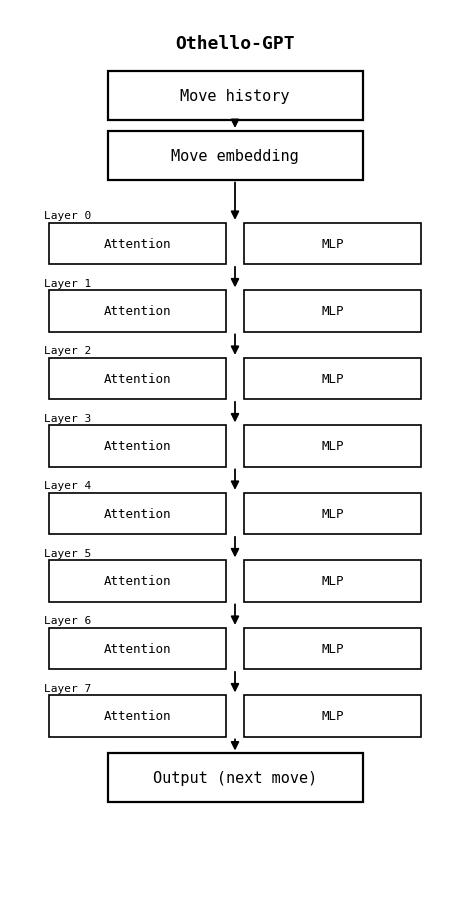

In [37]:
# Othello-GPT: input -> 8 transformer layers (attention + MLP) -> output
def build_ogpt(ax):
    ax.set_xlim(0, 6.0)
    ax.set_ylim(0, 12.0)

    cx = 3.0
    box_w = 3.4
    box_h = 0.65

    # Header label (matches the 'Trained'/'Handcrafted' style below)
    ax.text(cx, 11.55, 'Othello-GPT', ha='center', va='center',
             fontsize=13, fontdict=MONO, color='black', fontweight='bold')

    arch_box(ax, cx, 10.85, box_w, box_h, 'Move history')
    arch_box(ax, cx, 10.05, box_w, box_h, 'Move embedding')
    arch_arrow(ax, cx, 10.85 - box_h/2, cx, 10.05 + box_h/2)

    # 8 transformer layers, each Attention + MLP (side by side).  No
    # outer rectangle; layer label sits ABOVE the two inner boxes.
    layer_top = 9.25
    layer_h = 0.65
    layer_gap = 0.25
    attn_cx = 1.7
    mlp_cx = 4.3
    inner_w = 2.35
    inner_h = 0.55

    for i in range(8):
        cy = layer_top - i * (layer_h + layer_gap) - layer_h / 2
        # Layer label above the inner boxes.
        ax.text(0.45, cy - 0.05 + inner_h / 2 + 0.03, f'Layer {i}',
                 ha='left', va='bottom', fontsize=8, fontdict=MONO)
        arch_box(ax, attn_cx, cy - 0.05, inner_w, inner_h,
                  'Attention', fontsize=9, lw=1.2)
        arch_box(ax, mlp_cx, cy - 0.05, inner_w, inner_h,
                  'MLP', fontsize=9, lw=1.2)
        # arrow from previous layer / embedding into this layer
        prev_bottom = (10.05 - box_h / 2) if i == 0 else (
            layer_top - (i - 1) * (layer_h + layer_gap) - layer_h)
        arch_arrow(ax, cx, prev_bottom, cx, cy - 0.05 + inner_h / 2)

    last_bottom = layer_top - (7) * (layer_h + layer_gap) - layer_h
    arch_box(ax, cx, last_bottom - 0.55, box_w, box_h, 'Output (next move)')
    arch_arrow(ax, cx, last_bottom, cx, last_bottom - 0.55 + box_h/2)


render_arch(build_ogpt, 'arch_ogpt.png', figsize=(4.8, 10.5))

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/arch_mlp_trained.png


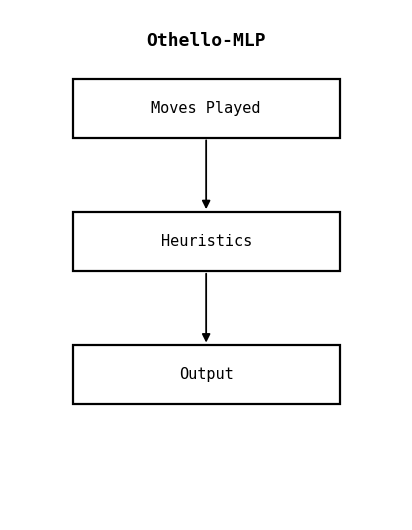

In [38]:
# Trained MLP: Input (60 x 2) -> Hidden (H=512) -> Output (960)
def build_mlp_trained(ax):
    ax.set_xlim(0, 5.0)
    ax.set_ylim(0, 6.5)

    cx = 2.5
    box_w = 3.4
    box_h = 0.75

    ax.text(cx, 6.1, 'Othello-MLP', ha='center', va='center',
             fontsize=13, fontdict=MONO, color='black', fontweight='bold')

    arch_box(ax, cx, 5.25, box_w, box_h, 'Moves Played')
    arch_box(ax, cx, 3.55, box_w, box_h, 'Heuristics')
    arch_box(ax, cx, 1.85, box_w, box_h, 'Output')

    arch_arrow(ax, cx, 5.25 - box_h/2, cx, 3.55 + box_h/2)
    arch_arrow(ax, cx, 3.55 - box_h/2, cx, 1.85 + box_h/2)


render_arch(build_mlp_trained, 'arch_mlp_trained.png', figsize=(4.6, 5.4))

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/arch_mlp_handcrafted.png


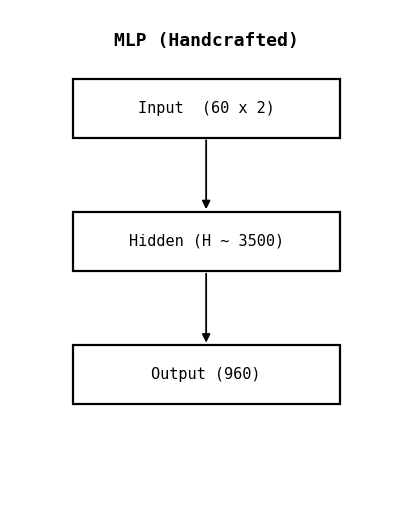

In [39]:
# Hand-crafted MLP: Input (60 x 2) -> Hidden (~3500 leaves) -> Output (960)
def build_mlp_handcrafted(ax):
    ax.set_xlim(0, 5.0)
    ax.set_ylim(0, 6.5)

    cx = 2.5
    box_w = 3.4
    box_h = 0.75

    ax.text(cx, 6.1, 'MLP (Handcrafted)', ha='center', va='center',
             fontsize=13, fontdict=MONO, color='black', fontweight='bold')

    arch_box(ax, cx, 5.25, box_w, box_h, 'Input  (60 x 2)')
    arch_box(ax, cx, 3.55, box_w, box_h, 'Hidden (H ~ 3500)')
    arch_box(ax, cx, 1.85, box_w, box_h, 'Output (960)')

    arch_arrow(ax, cx, 5.25 - box_h/2, cx, 3.55 + box_h/2)
    arch_arrow(ax, cx, 3.55 - box_h/2, cx, 1.85 + box_h/2)


render_arch(build_mlp_handcrafted, 'arch_mlp_handcrafted.png', figsize=(4.6, 5.4))

## Section 3 — Performance figures

**Data + model loading** (needed for the boards below).  We use the adversarial records in `experiment1_by_depth/adversarial_records.npz` plus the trained MLP checkpoint to compute per-cell probabilities on the fly.

This section is scaffolding — pick a model, load once, then render three groups of boards:
1. **Adversarial position**: every cell with p > 1% outlined, p printed inside.
2. **Adversarial game triptych**: the position at t\_L (last legal same-parity turn), t\_I (illegal move chosen), and t\_I + 1 (or +2, next same-parity turn).
3. **No-flanker-but-p-grows example**: search regular games for a position where p(cell) increases as an opponent-piece line grows in one direction, even though the flanking terminal is missing.

In [40]:
# Hardcoded game data for Section 3 boards.
# Games + metadata are visible/editable here.  Probs come from the
# pre-computed npz at notebooks/talk_data/performance_data.npz (row k
# of top_probs matches ADV_GAMES[k]).
#
# The npz is produced on the cluster by:
#   python notebooks/prep_performance_data.py --adv-search-k 300

PERF_PATH = os.path.join(REPO_ROOT, 'notebooks/talk_data/performance_data.npz')
perf = np.load(PERF_PATH, allow_pickle=True)

ADV_GAMES = [
    {
        'label': '#1  adv[13]',
        'game': [37, 45, 19, 34, 41, 33, 42, 48, 26, 38, 54, 43, 40, 25, 49,
                 57, 58, 10, 20, 51, 12, 21, 17, 9, 1, 18, 56, 63, 50, 11, 2,
                 3, 4],
        't_L': 22, 't_transition': 24, 'T': 32, 'C': 24,
        'P_L': 0.0615, 'P_I': 0.2247,
    },
    {
        'label': '#2  adv[4]',
        'game': [19, 18, 17, 9, 44, 16, 0, 1, 2, 45, 25, 34, 33, 43, 52, 20,
                 11, 59, 54],
        't_L': 14, 't_transition': 16, 'T': 18, 'C': 37,
        'P_L': 0.1045, 'P_I': 0.2138,
    },
    {
        'label': '#3  adv[271]',
        'game': [19, 20, 37, 44, 45, 30, 43, 51, 59, 53, 38, 34, 46, 52, 33,
                 39, 55, 29, 31, 54, 62, 60, 13, 23],
        't_L': 17, 't_transition': 19, 'T': 23, 'C': 42,
        'P_L': 0.0998, 'P_I': 0.2075,
    },
    {
        'label': '#4  adv[146]',
        'game': [37, 43, 26, 21, 29, 45, 14, 7, 20, 19, 30, 38, 13, 12, 18,
                 17, 22, 31, 4],
        't_L': 16, 't_transition': 18, 'T': 18, 'C': 44,
        'P_L': 0.2009, 'P_I': 0.2826,
    },
    {
        'label': '#5  adv[2]',
        'game': [19, 18, 17, 9, 44, 16, 0, 1, 2, 45, 25, 34, 33, 43, 52, 20,
                 11, 59, 13],
        't_L': 14, 't_transition': 16, 'T': 18, 'C': 37,
        'P_L': 0.1045, 'P_I': 0.2004,
    },
]

# For the no-flanker figure: the single winning position (line_len=6) and
# the (short) line-growth sequence found in that game (lengths 1..3).
NOFLANK = {
    'target_cell': (3, 5),          # row, col
    'direction': (1, 0),            # down (dr, dc)
}


def state_after_replay(game, turn):
    """Replay `game[0..turn]` (i.e., turn+1 moves) and return (8, 8) state.
    Matches state_at_turn convention in the prep script."""
    board = OthelloBoardState()
    for m in game[:turn + 1]:
        board.umpire(int(m))
    return np.asarray(board.state, dtype=np.int8).reshape(8, 8).copy()


def render_probs_board(state, probs, focus_cell, legal, out_name,
                          title=None, min_p=0.01, figsize=(5, 5),
                          force_focus_label=True):
    """Board with cells > min_p labeled, focus cell outlined green/red.

    force_focus_label=True (default): the focus cell always gets its P
    printed, even if p <= min_p.  Ensures the target P is visible on
    every board in a sequence.
    """
    highlights = {}
    for r in range(8):
        for c in range(8):
            if state[r, c] != 0:
                continue
            p = float(probs[r, c])
            is_focus = ((r, c) == tuple(focus_cell))
            spec = {}
            if p > min_p or (is_focus and force_focus_label):
                # Round-up for numbers under 1% so we don't show "0%".
                if p >= 0.005:
                    spec['label'] = f'{100*p:.0f}%'
                else:
                    spec['label'] = f'{100*p:.1f}%'
            if is_focus:
                spec['border'] = 'green' if legal else 'red'
                spec['border_lw'] = 4.0
            if spec:
                highlights[(r, c)] = spec
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights, title=None,
                show_coords=True, fontsize=8)
    out_path = os.path.join(TALK_DIR, out_name)
    plt.savefig(out_path, dpi=200, facecolor='white')
    print(f'  saved {out_path}')
    plt.show()


print(f'ADV_GAMES: {len(ADV_GAMES)} adversarial records hardcoded')
print(f'perf npz has top_probs shape {perf["top_probs"].shape}')

ADV_GAMES: 5 adversarial records hardcoded
perf npz has top_probs shape (5, 3, 8, 8)



=== #1  adv[13]: C=24 at (3, 0)   P_L=0.061  P_I=0.225  retention=3.65
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv1_moment1.png


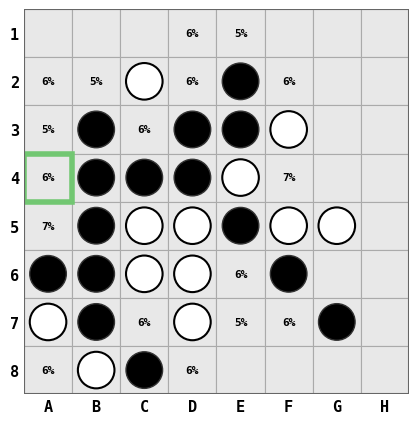

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv1_moment2.png


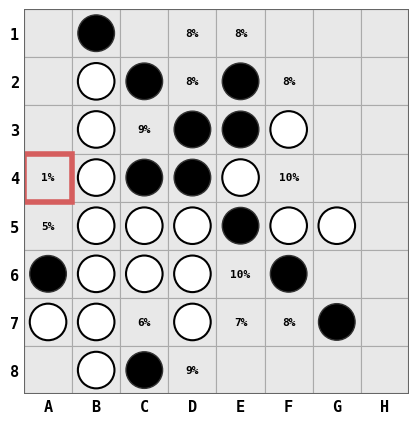

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv1_moment3.png


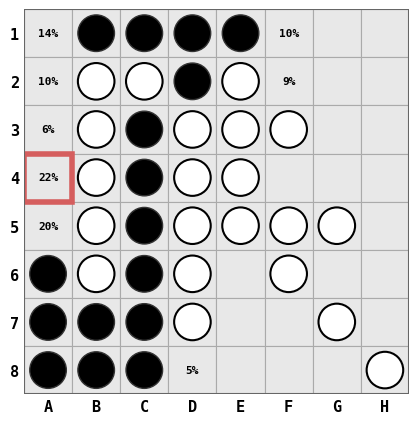


=== #2  adv[4]: C=37 at (4, 5)   P_L=0.104  P_I=0.214  retention=2.05
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv2_moment1.png


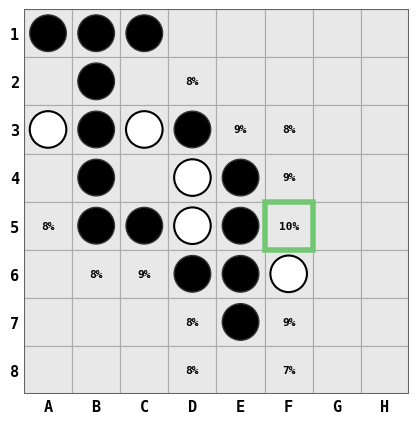

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv2_moment2.png


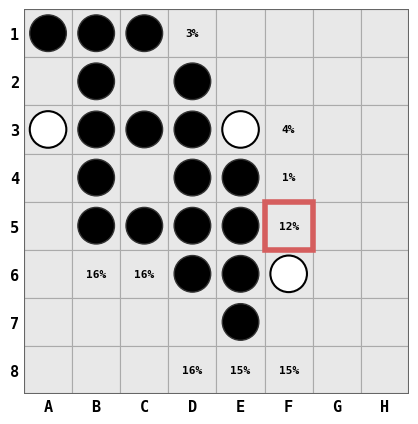

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv2_moment3.png


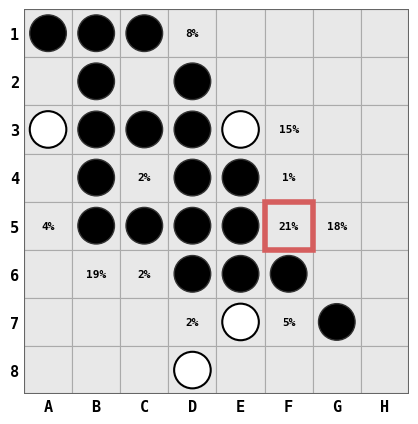


=== #3  adv[271]: C=42 at (5, 2)   P_L=0.100  P_I=0.207  retention=2.08
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv3_moment1.png


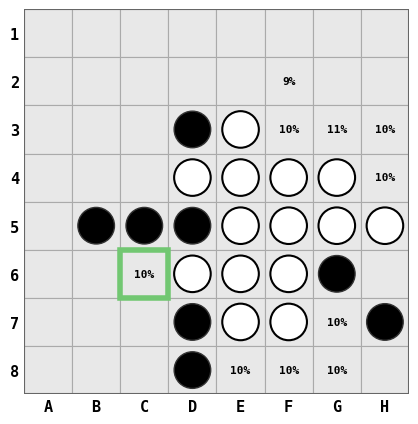

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv3_moment2.png


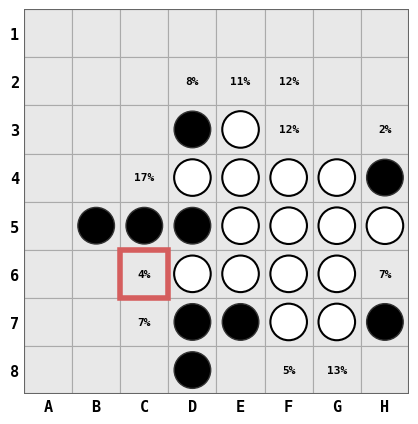

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv3_moment3.png


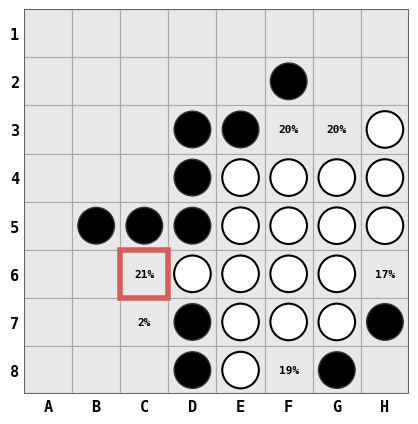


=== #4  adv[146]: C=44 at (5, 4)   P_L=0.201  P_I=0.283  retention=1.41
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv4_moment1.png


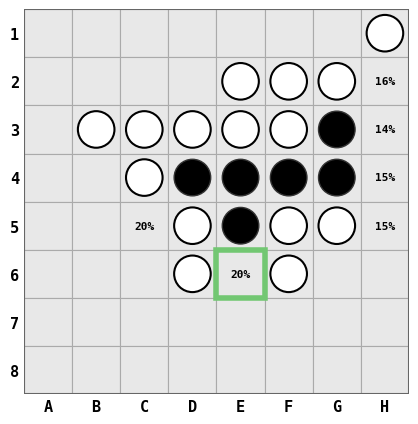

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv4_moment2.png


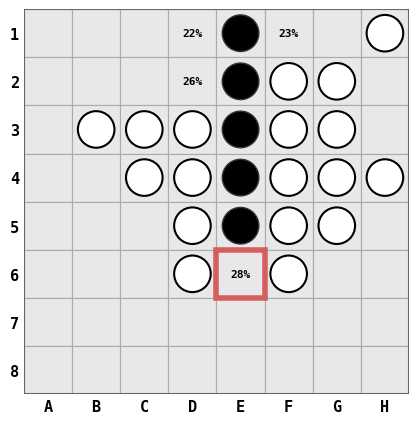

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv4_moment3.png


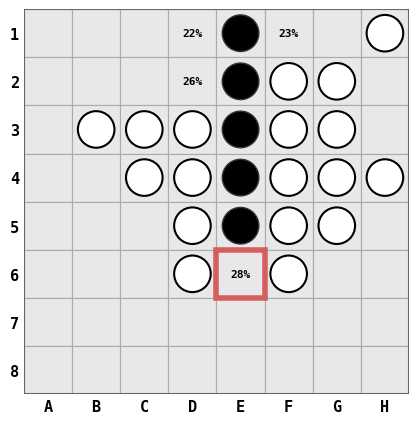


=== #5  adv[2]: C=37 at (4, 5)   P_L=0.104  P_I=0.200  retention=1.92
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv5_moment1.png


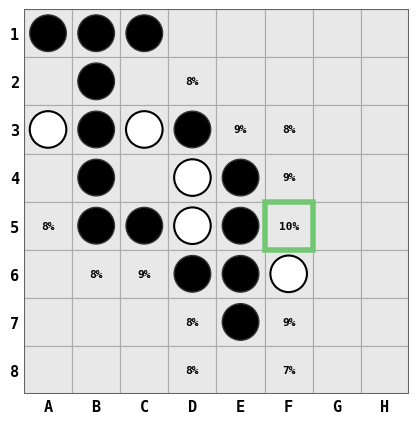

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv5_moment2.png


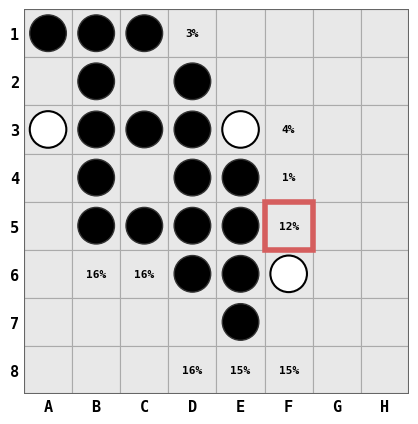

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/adv5_moment3.png


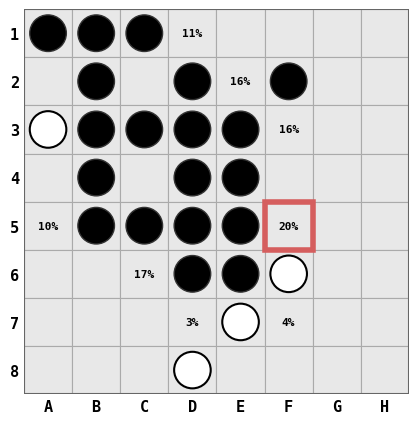

In [41]:
# Section 3a — top-5 adversarial triptychs.
# For each ADV_GAMES[k]: 3 boards at (t_L, t_transition, T).
# States are replayed locally from the hardcoded game.
# Probs come from perf['top_probs'][k, moment].
moment_names = ['t_L (C legal)', 't_transition (C becomes illegal)',
                 'T (adversarial move)']
moment_keys = ['t_L', 't_transition', 'T']

for k, entry in enumerate(ADV_GAMES):
    Cr, Cc = entry['C'] // 8, entry['C'] % 8
    print(f'\n=== {entry["label"]}: C={entry["C"]} at ({Cr}, {Cc})   '
           f'P_L={entry["P_L"]:.3f}  P_I={entry["P_I"]:.3f}  '
           f'retention={entry["P_I"] / max(entry["P_L"], 1e-6):.2f}')
    for m, (name, key) in enumerate(zip(moment_names, moment_keys)):
        t = entry[key]
        state = state_after_replay(entry['game'], t)
        probs = perf['top_probs'][k, m]
        # Legality: is C in valid moves after replaying game[:t+1]?
        board = OthelloBoardState()
        for mv in entry['game'][:t + 1]:
            board.umpire(int(mv))
        legal = entry['C'] in set(board.get_valid_moves())
        p_at_C = float(probs[Cr, Cc])
        title = (f'Adversarial game, move {t}')
        render_probs_board(state, probs,
                            focus_cell=(Cr, Cc), legal=legal,
                            out_name=f'adv{k+1}_moment{m+1}.png',
                            title=title)

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_winning.png


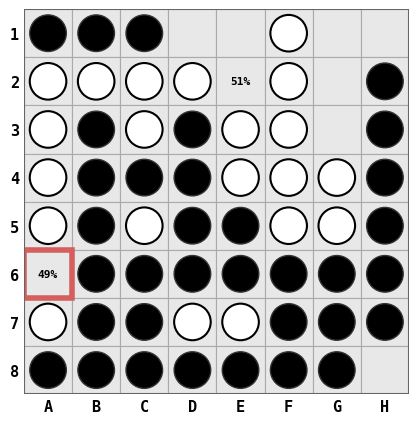


Monotonic growth at target (7, 2), direction (-1, 0):
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_growth_len3.png


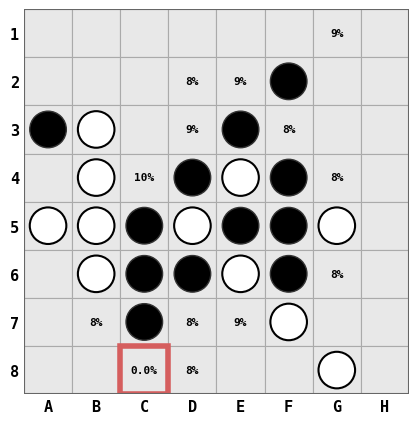

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_growth_len5.png


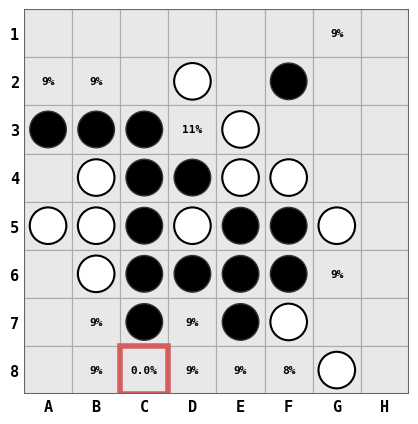

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_growth_len6.png


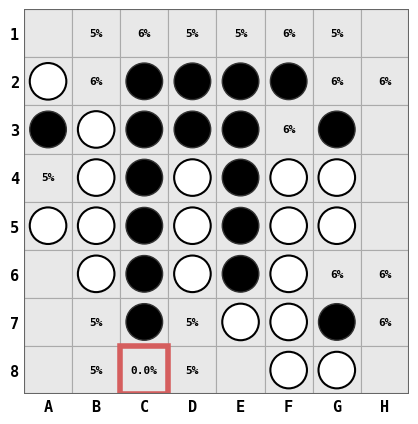

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_growth_len7.png


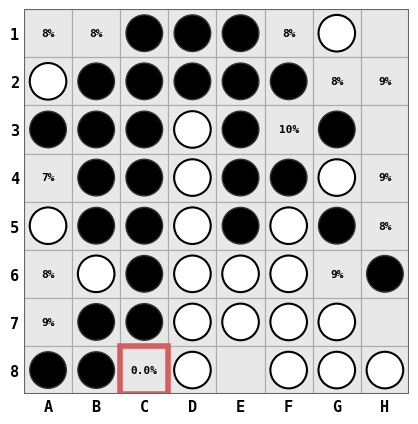

In [42]:
# Section 3b — no-flanker figures.
# (1) The single winning position: opp line of length 6 toward the target
#     cell, no valid flanker, model still assigns P ~ 99.85%.
# (2) The MONOTONIC line-growth sequence from a game where the opp-line
#     toward a specific target grows over same-parity turns while the
#     target is always empty AND has no valid flanker (illegal throughout).

# (1) Winning single position (best score across all games)
Tr_flank, Tc_flank = int(perf['flank_target_cell'][0]), int(perf['flank_target_cell'][1])
render_probs_board(
    perf['flank_state'], perf['flank_probs'],
    focus_cell=(Tr_flank, Tc_flank), legal=False,
    out_name='noflank_winning.png',
    title=(f'No-flanker winning example  '
            f'(line length {int(perf["flank_line_len"])}, '
            f'P(target) = {100*float(perf["flank_p_target"]):.1f}%)'))

# (2) Monotonic growth sequence: uses growth_target_cell (may be from a
#     different game than the single winner above).
if perf['growth_states'].shape[0] == 0:
    print('No monotonic growth game found; rerun prep with --growth-* args.')
else:
    Gr, Gc = int(perf['growth_target_cell'][0]), int(perf['growth_target_cell'][1])
    Gd = tuple(int(x) for x in perf['growth_direction'])
    print(f'\nMonotonic growth at target ({Gr}, {Gc}), direction {Gd}:')
    for m in range(perf['growth_states'].shape[0]):
        L = int(perf['growth_line_lens'][m])
        p = float(perf['growth_p_target'][m])
        title = (f'Opp line length {L}  '
                  f'(turn {int(perf["growth_turns"][m])}, '
                  f'P(target) = {100*p:.1f}%)')
        render_probs_board(
            perf['growth_states'][m], perf['growth_probs'][m],
            focus_cell=(Gr, Gc), legal=False,
            out_name=f'noflank_growth_len{L}.png',
            title=title)

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top1.png


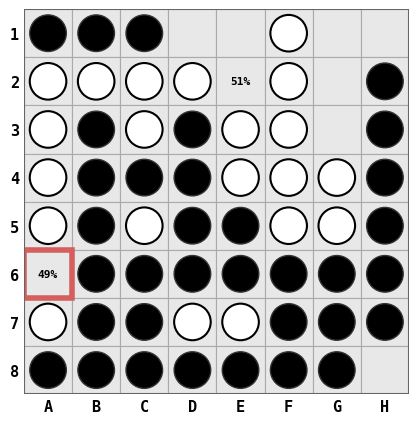

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top2.png


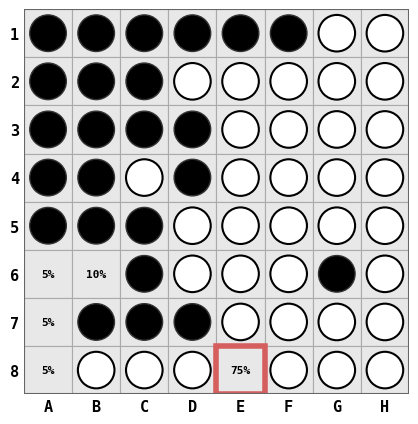

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top3.png


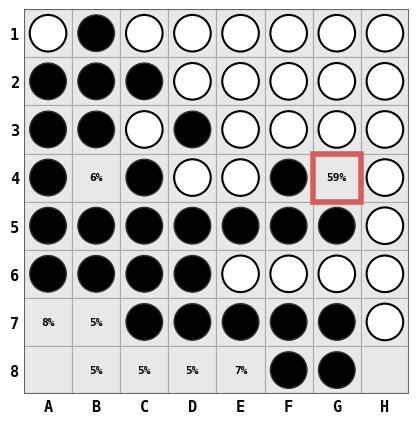

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top4.png


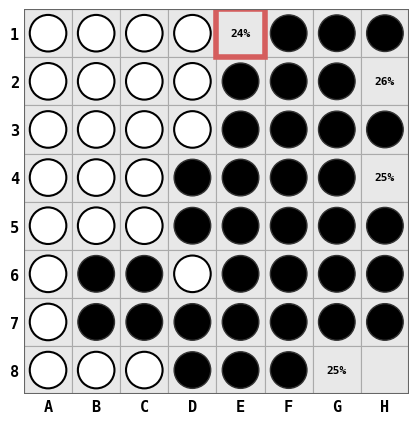

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/noflank_top5.png


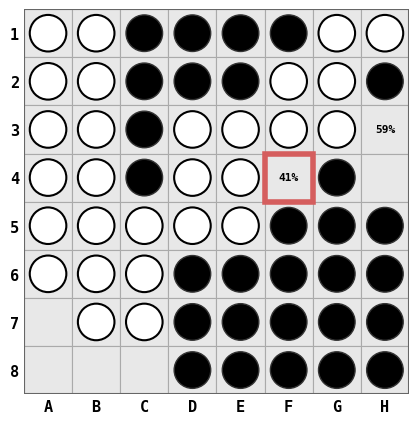

In [43]:
# Section 3c — top-K no-flanker examples across many games.
# Each panel is a distinct game/position where the model puts high prob
# on an illegal cell that has a long opp line but no valid flanker.
if 'top_flank_states' in perf.files:
    for k in range(perf['top_flank_states'].shape[0]):
        tr, tc = int(perf['top_flank_target_cells'][k, 0]), \
                  int(perf['top_flank_target_cells'][k, 1])
        title = (f'No-flanker #{k+1}  '
                  f'(line length {int(perf["top_flank_line_lens"][k])}, '
                  f'P(target) = {100*float(perf["top_flank_p"][k]):.1f}%, '
                  f'turn {int(perf["top_flank_turns"][k])})')
        render_probs_board(
            perf['top_flank_states'][k], perf['top_flank_probs'][k],
            focus_cell=(tr, tc), legal=False,
            out_name=f'noflank_top{k+1}.png',
            title=title)
else:
    print('top_flank_* not in npz — rerun prep_performance_data.py to '
           'populate the top-K no-flanker examples')

## Section 4 — Nanda probe: decoding accuracy by turn

Per-cell accuracy of Nanda's linear {MINE, YOURS, EMPTY} probe on OthelloGPT layer 6, averaged over all 64 cells per turn.  Numbers come from the `.npz` produced by `plot_ogpt_overall_by_turn.py --n-games 1000`.  Copy that file to `notebooks/talk_data/ogpt_probe_accuracy_by_turn.npz` before running.

Style matches Section 2 architecture diagrams: pure black-on-white, monospace text, sharp lines.

Loaded 59 turns from /Users/jmorriso/Git/othello_world/notebooks/talk_data/ogpt_probe_accuracy_by_turn.npz
  n_games = 1000, mean acc = 0.9804, min = 0.2149 at turn 0
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/ogpt_probe_accuracy_by_turn.png


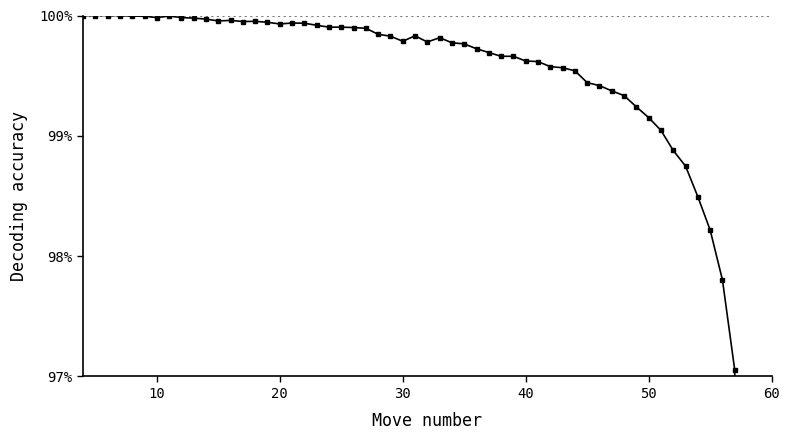

In [44]:
# Nanda probe accuracy by turn - minimal B&W 1980s aesthetic.
import matplotlib.ticker as mticker
MONO = {'family': 'monospace'}   # in case Section 2 hasn't been run yet

# X-axis range (move number).
X_MIN = 5
X_MAX = 60

# Y-axis range for the plot (accuracy as a fraction, 0..1).
Y_MIN = 0.97
Y_MAX = 1.0

NANDA_ACC_NPZ = os.path.join(REPO_ROOT,
    'notebooks/talk_data/ogpt_probe_accuracy_by_turn.npz')
d = np.load(NANDA_ACC_NPZ)
turns = d['turns']
acc = d['per_turn_overall']
n_games = int(d['n_games']) if 'n_games' in d.files else int(d['per_turn_n'][0])
print(f'Loaded {len(turns)} turns from {NANDA_ACC_NPZ}')
print(f'  n_games = {n_games}, mean acc = {acc.mean():.4f}, '
      f'min = {acc.min():.4f} at turn {int(turns[np.argmin(acc)])}')

fig, ax = plt.subplots(figsize=(8.0, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Data: thin black line, small filled square markers on each point.
ax.plot(turns, acc, color='black', linewidth=1.2,
        marker='s', markersize=3.2, markerfacecolor='black',
        markeredgecolor='black')

# Axes: black, sharp, monospace tick labels.
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1.2)
for spine in ('right', 'top'):
    ax.spines[spine].set_visible(False)

# Small padding on the x-axis so markers at the edges aren't clipped.
ax.set_xlim(X_MIN - 1, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
# Auto-pick x ticks based on the current range.
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=7, steps=[1, 2, 5, 10],
                                                integer=True))
# Auto-pick y ticks based on the current range, formatted as percentages.
ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=4))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{int(round(100 * y))}%'))
ax.tick_params(axis='both', direction='out', length=4, width=1.0,
               colors='black', labelsize=10)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('monospace')

# Dashed horizontal reference at 100% (only shown if it's in the y range).
if Y_MIN <= 1.0 <= Y_MAX:
    ax.axhline(1.0, color='black', linestyle=(0, (2, 3)), linewidth=0.8, alpha=0.5)

# Axis labels in monospace.
ax.set_xlabel('Move number', fontdict=MONO, fontsize=12, color='black',
              labelpad=8)
ax.set_ylabel('Decoding accuracy', fontdict=MONO, fontsize=12, color='black',
              labelpad=8)

plt.tight_layout()
out_path = os.path.join(TALK_DIR, 'ogpt_probe_accuracy_by_turn.png')
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'  saved {out_path}')
plt.show()

## Section 4b — J1 tree-MLP board decoder: accuracy by turn

Same linear {MINE, YOURS, EMPTY} probe, decoded from the **J1 per-pattern tree hidden layer** instead of OthelloGPT. Data: `reeval_state_decoder.py` -> `notebooks/talk_data/j1_probe_accuracy_by_turn.npz`. Tree-decoder range is lower than the transformer (`Y_MIN` widened; tune later).

Loaded 48 turns from /Users/jmorriso/Git/othello_world/notebooks/talk_data/j1_probe_accuracy_by_turn.npz
  n_games = 500000, mean acc = 0.9049, min = 0.7817 at turn 53
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j1_probe_accuracy_by_turn.png


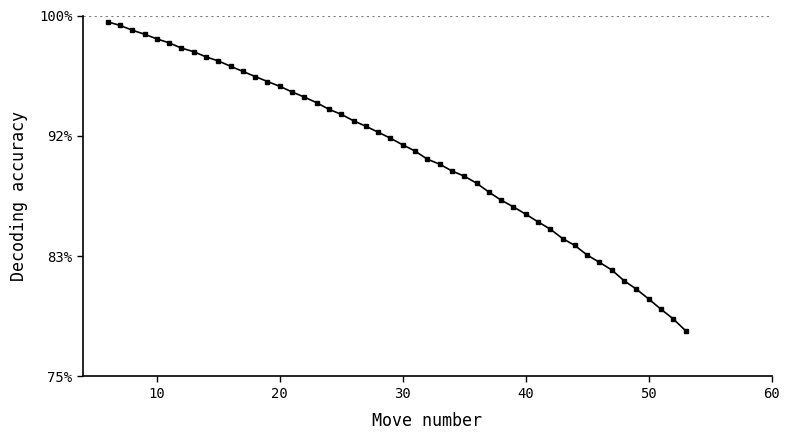

In [45]:
# J1 tree-MLP board-decoder accuracy by turn - minimal B&W 1980s aesthetic.
import matplotlib.ticker as mticker
MONO = {'family': 'monospace'}   # in case Section 2 hasn't been run yet

# X-axis range (move number).
X_MIN = 5
X_MAX = 60

# Y-axis range for the plot (accuracy as a fraction, 0..1).
Y_MIN = 0.75   # widened for tree-decoder range (adjust)
Y_MAX = 1.0

NANDA_ACC_NPZ = os.path.join(REPO_ROOT,
    'notebooks/talk_data/j1_probe_accuracy_by_turn.npz')
d = np.load(NANDA_ACC_NPZ)
turns = d['turns']
acc = d['per_turn_overall']
n_games = int(d['n_games']) if 'n_games' in d.files else int(d['per_turn_n'][0])
print(f'Loaded {len(turns)} turns from {NANDA_ACC_NPZ}')
print(f'  n_games = {n_games}, mean acc = {acc.mean():.4f}, '
      f'min = {acc.min():.4f} at turn {int(turns[np.argmin(acc)])}')

fig, ax = plt.subplots(figsize=(8.0, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Data: thin black line, small filled square markers on each point.
ax.plot(turns, acc, color='black', linewidth=1.2,
        marker='s', markersize=3.2, markerfacecolor='black',
        markeredgecolor='black')

# Axes: black, sharp, monospace tick labels.
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1.2)
for spine in ('right', 'top'):
    ax.spines[spine].set_visible(False)

# Small padding on the x-axis so markers at the edges aren't clipped.
ax.set_xlim(X_MIN - 1, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
# Auto-pick x ticks based on the current range.
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=7, steps=[1, 2, 5, 10],
                                                integer=True))
# Auto-pick y ticks based on the current range, formatted as percentages.
ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=4))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{int(round(100 * y))}%'))
ax.tick_params(axis='both', direction='out', length=4, width=1.0,
               colors='black', labelsize=10)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('monospace')

# Dashed horizontal reference at 100% (only shown if it's in the y range).
if Y_MIN <= 1.0 <= Y_MAX:
    ax.axhline(1.0, color='black', linestyle=(0, (2, 3)), linewidth=0.8, alpha=0.5)

# Axis labels in monospace.
ax.set_xlabel('Move number', fontdict=MONO, fontsize=12, color='black',
              labelpad=8)
ax.set_ylabel('Decoding accuracy', fontdict=MONO, fontsize=12, color='black',
              labelpad=8)

plt.tight_layout()
out_path = os.path.join(TALK_DIR, 'j1_probe_accuracy_by_turn.png')
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'  saved {out_path}')
plt.show()

## Section 4c — J3 ordinal tree MLP board decoder: accuracy by turn

Same mine/yours probe on the **J3 ordinal (time-split) tree hidden layer**. Data: `notebooks/talk_data/j3_probe_accuracy_by_turn.npz`.

Loaded 48 turns from /Users/jmorriso/Git/othello_world/notebooks/talk_data/j3_probe_accuracy_by_turn.npz
  n_games = 500000, mean acc = 0.9234, min = 0.8179 at turn 53
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j3_probe_accuracy_by_turn.png


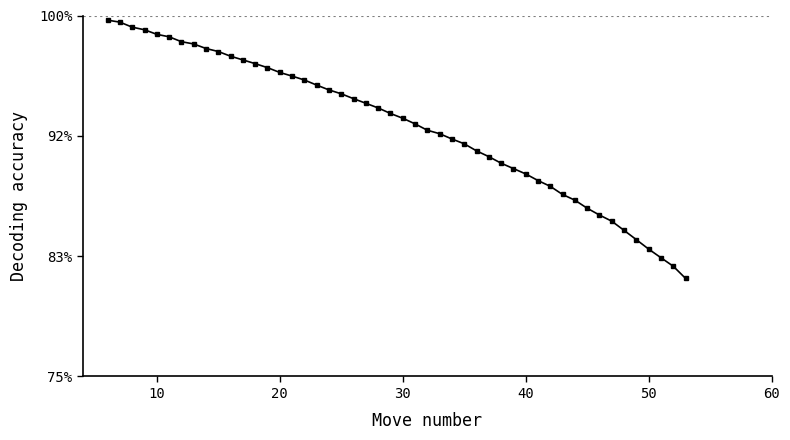

In [46]:
# J3 tree-MLP board-decoder accuracy by turn - minimal B&W 1980s aesthetic.
import matplotlib.ticker as mticker
MONO = {'family': 'monospace'}   # in case Section 2 hasn't been run yet

# X-axis range (move number).
X_MIN = 5
X_MAX = 60

# Y-axis range for the plot (accuracy as a fraction, 0..1).
Y_MIN = 0.75   # widened for tree-decoder range (adjust)
Y_MAX = 1.0

NANDA_ACC_NPZ = os.path.join(REPO_ROOT,
    'notebooks/talk_data/j3_probe_accuracy_by_turn.npz')
d = np.load(NANDA_ACC_NPZ)
turns = d['turns']
acc = d['per_turn_overall']
n_games = int(d['n_games']) if 'n_games' in d.files else int(d['per_turn_n'][0])
print(f'Loaded {len(turns)} turns from {NANDA_ACC_NPZ}')
print(f'  n_games = {n_games}, mean acc = {acc.mean():.4f}, '
      f'min = {acc.min():.4f} at turn {int(turns[np.argmin(acc)])}')

fig, ax = plt.subplots(figsize=(8.0, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Data: thin black line, small filled square markers on each point.
ax.plot(turns, acc, color='black', linewidth=1.2,
        marker='s', markersize=3.2, markerfacecolor='black',
        markeredgecolor='black')

# Axes: black, sharp, monospace tick labels.
for spine in ('left', 'bottom'):
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(1.2)
for spine in ('right', 'top'):
    ax.spines[spine].set_visible(False)

# Small padding on the x-axis so markers at the edges aren't clipped.
ax.set_xlim(X_MIN - 1, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
# Auto-pick x ticks based on the current range.
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=7, steps=[1, 2, 5, 10],
                                                integer=True))
# Auto-pick y ticks based on the current range, formatted as percentages.
ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=4))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{int(round(100 * y))}%'))
ax.tick_params(axis='both', direction='out', length=4, width=1.0,
               colors='black', labelsize=10)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('monospace')

# Dashed horizontal reference at 100% (only shown if it's in the y range).
if Y_MIN <= 1.0 <= Y_MAX:
    ax.axhline(1.0, color='black', linestyle=(0, (2, 3)), linewidth=0.8, alpha=0.5)

# Axis labels in monospace.
ax.set_xlabel('Move number', fontdict=MONO, fontsize=12, color='black',
              labelpad=8)
ax.set_ylabel('Decoding accuracy', fontdict=MONO, fontsize=12, color='black',
              labelpad=8)

plt.tight_layout()
out_path = os.path.join(TALK_DIR, 'j3_probe_accuracy_by_turn.png')
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'  saved {out_path}')
plt.show()

### Nanda probe: decoding accuracy by square

Per-cell accuracy from the same probe, computed over positions 5..54.  Produced on the cluster by:

```
python analyze_nanda_probe_per_cell.py --n-games 1000 --seed 0 \
    --data-out experiments/plots/ogpt_probe_accuracy_by_cell.npz
```

Copy that npz to `notebooks/talk_data/ogpt_probe_accuracy_by_cell.npz` before running the cell below.

Loaded (8, 8) per-cell accuracy from /Users/jmorriso/Git/othello_world/notebooks/talk_data/ogpt_probe_accuracy_by_cell.npz
  n_games = 1000, positions 5..58, mean = 0.9936, min = 0.9822, max = 0.9989
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/ogpt_probe_accuracy_by_cell.png


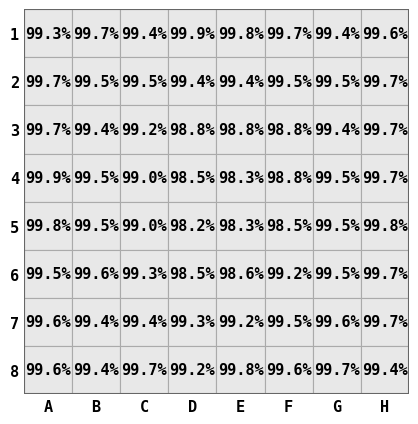

In [47]:
# Nanda probe accuracy by square - render_board style, no heatmap.
NANDA_CELL_NPZ = os.path.join(REPO_ROOT,
    'notebooks/talk_data/ogpt_probe_accuracy_by_cell.npz')
dc = np.load(NANDA_CELL_NPZ)
acc_cell = dc['acc']  # (8, 8) in [0, 1]
n_games_c = int(dc['n_games']) if 'n_games' in dc.files else 1000
pos_start = int(dc['pos_start']) if 'pos_start' in dc.files else 5
pos_end   = int(dc['pos_end'])   if 'pos_end'   in dc.files else 54
print(f'Loaded {acc_cell.shape} per-cell accuracy from {NANDA_CELL_NPZ}')
print(f'  n_games = {n_games_c}, positions {pos_start}..{pos_end - 1}, '
      f'mean = {acc_cell.mean():.4f}, min = {acc_cell.min():.4f}, '
      f'max = {acc_cell.max():.4f}')

state = np.zeros((8, 8), dtype=np.int8)
highlights = {(r, c): {'label': f'{100 * acc_cell[r, c]:.1f}%'}
              for r in range(8) for c in range(8)}

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')
draw_board(ax, state, highlights=highlights,
           title=None,
           show_coords=True, fontsize=11)
out_path = os.path.join(TALK_DIR, 'ogpt_probe_accuracy_by_cell.png')
plt.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()

Grayscale range: 98.0% .. 100.0%
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/ogpt_probe_accuracy_by_cell_gray.png


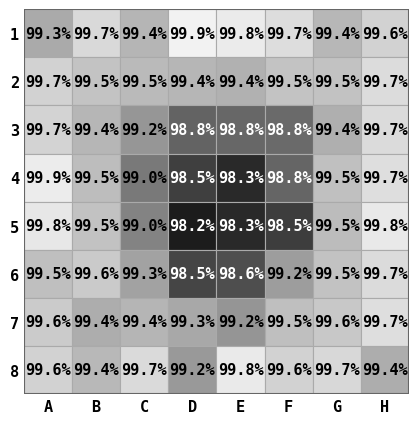

In [48]:
# Nanda probe accuracy by square - render_board style, grayscale heatmap.
# Convention: higher accuracy = LIGHTER fill.
HEATMAP_VMIN = 0.98   # lower bound of the grayscale mapping
HEATMAP_VMAX = 1.00   # upper bound of the grayscale mapping

# Reuse per-cell data loaded above (cell-25).
print(f'Grayscale range: {100 * HEATMAP_VMIN:.1f}% .. {100 * HEATMAP_VMAX:.1f}%')

# Normalize into [0, 1] within the visible band, with clipping.
norm = np.clip(
    (acc_cell - HEATMAP_VMIN) / max(HEATMAP_VMAX - HEATMAP_VMIN, 1e-9),
    0.0, 1.0)
# draw_board's heatmap maps value v -> fill (1-v, 1-v, 1-v).
# We want higher accuracy = lighter (whiter), so pass (1 - norm) so that
# high accuracy -> value 0 -> fill (1, 1, 1) = white.
heatmap = {(r, c): float(1.0 - norm[r, c])
           for r in range(8) for c in range(8)}

state = np.zeros((8, 8), dtype=np.int8)
highlights = {(r, c): {'label': f'{100 * acc_cell[r, c]:.1f}%'}
              for r in range(8) for c in range(8)}

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')
draw_board(ax, state, highlights=highlights, heatmap=heatmap,
           title=None,
           show_coords=True, fontsize=11)

out_path = os.path.join(TALK_DIR, 'ogpt_probe_accuracy_by_cell_gray.png')
plt.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()

### J1 tree-MLP board decoder: accuracy by square

Per-cell accuracy of the same mine/yours probe on the **J1 per-pattern tree hidden layer**. Data: `notebooks/talk_data/j1_probe_accuracy_by_cell.npz`.

Loaded (8, 8) per-cell accuracy from /Users/jmorriso/Git/othello_world/notebooks/talk_data/j1_probe_accuracy_by_cell.npz
  n_games = 500000, positions 5..53, mean = 0.9049, min = 0.7215, max = 0.9997
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j1_probe_accuracy_by_cell.png


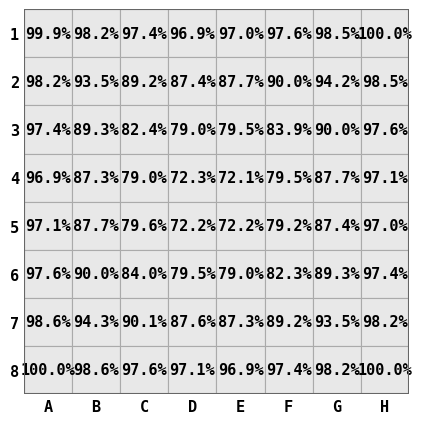

In [49]:
# Nanda probe accuracy by square - render_board style, no heatmap.
NANDA_CELL_NPZ = os.path.join(REPO_ROOT,
    'notebooks/talk_data/j1_probe_accuracy_by_cell.npz')
dc = np.load(NANDA_CELL_NPZ)
acc_cell = dc['acc']  # (8, 8) in [0, 1]
n_games_c = int(dc['n_games']) if 'n_games' in dc.files else 1000
pos_start = int(dc['pos_start']) if 'pos_start' in dc.files else 5
pos_end   = int(dc['pos_end'])   if 'pos_end'   in dc.files else 54
print(f'Loaded {acc_cell.shape} per-cell accuracy from {NANDA_CELL_NPZ}')
print(f'  n_games = {n_games_c}, positions {pos_start}..{pos_end - 1}, '
      f'mean = {acc_cell.mean():.4f}, min = {acc_cell.min():.4f}, '
      f'max = {acc_cell.max():.4f}')

state = np.zeros((8, 8), dtype=np.int8)
highlights = {(r, c): {'label': f'{100 * acc_cell[r, c]:.1f}%'}
              for r in range(8) for c in range(8)}

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')
draw_board(ax, state, highlights=highlights,
           title=None,
           show_coords=True, fontsize=11)
out_path = os.path.join(TALK_DIR, 'j1_probe_accuracy_by_cell.png')
plt.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()

Grayscale range: 70.0% .. 100.0%
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j1_probe_accuracy_by_cell_gray.png


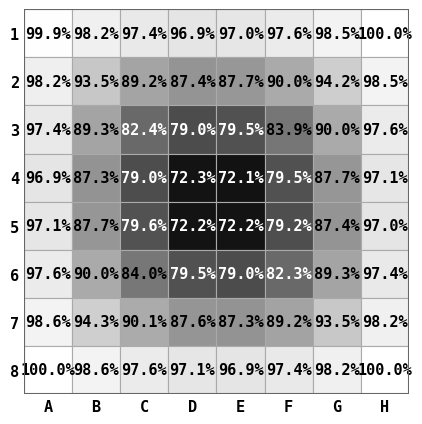

In [50]:
# Nanda probe accuracy by square - render_board style, grayscale heatmap.
# Convention: higher accuracy = LIGHTER fill.
HEATMAP_VMIN = 0.70   # tree-decoder range (adjust)   # lower bound of the grayscale mapping
HEATMAP_VMAX = 1.00   # upper bound of the grayscale mapping

# Reuse per-cell data loaded above (cell-25).
print(f'Grayscale range: {100 * HEATMAP_VMIN:.1f}% .. {100 * HEATMAP_VMAX:.1f}%')

# Normalize into [0, 1] within the visible band, with clipping.
norm = np.clip(
    (acc_cell - HEATMAP_VMIN) / max(HEATMAP_VMAX - HEATMAP_VMIN, 1e-9),
    0.0, 1.0)
# draw_board's heatmap maps value v -> fill (1-v, 1-v, 1-v).
# We want higher accuracy = lighter (whiter), so pass (1 - norm) so that
# high accuracy -> value 0 -> fill (1, 1, 1) = white.
heatmap = {(r, c): float(1.0 - norm[r, c])
           for r in range(8) for c in range(8)}

state = np.zeros((8, 8), dtype=np.int8)
highlights = {(r, c): {'label': f'{100 * acc_cell[r, c]:.1f}%'}
              for r in range(8) for c in range(8)}

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')
draw_board(ax, state, highlights=highlights, heatmap=heatmap,
           title=None,
           show_coords=True, fontsize=11)

out_path = os.path.join(TALK_DIR, 'j1_probe_accuracy_by_cell_gray.png')
plt.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()

### J3 ordinal tree MLP board decoder: accuracy by square

Per-cell accuracy on the **J3 ordinal tree hidden layer**. Data: `notebooks/talk_data/j3_probe_accuracy_by_cell.npz`.

Loaded (8, 8) per-cell accuracy from /Users/jmorriso/Git/othello_world/notebooks/talk_data/j3_probe_accuracy_by_cell.npz
  n_games = 500000, positions 5..53, mean = 0.9234, min = 0.7721, max = 0.9994
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j3_probe_accuracy_by_cell.png


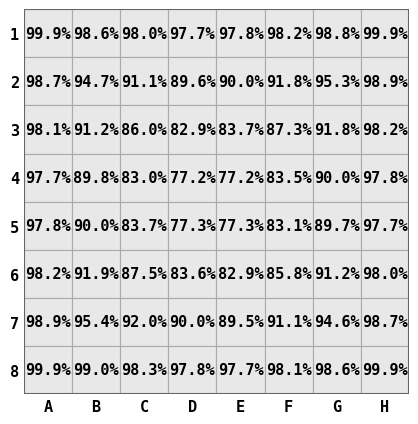

In [51]:
# Nanda probe accuracy by square - render_board style, no heatmap.
NANDA_CELL_NPZ = os.path.join(REPO_ROOT,
    'notebooks/talk_data/j3_probe_accuracy_by_cell.npz')
dc = np.load(NANDA_CELL_NPZ)
acc_cell = dc['acc']  # (8, 8) in [0, 1]
n_games_c = int(dc['n_games']) if 'n_games' in dc.files else 1000
pos_start = int(dc['pos_start']) if 'pos_start' in dc.files else 5
pos_end   = int(dc['pos_end'])   if 'pos_end'   in dc.files else 54
print(f'Loaded {acc_cell.shape} per-cell accuracy from {NANDA_CELL_NPZ}')
print(f'  n_games = {n_games_c}, positions {pos_start}..{pos_end - 1}, '
      f'mean = {acc_cell.mean():.4f}, min = {acc_cell.min():.4f}, '
      f'max = {acc_cell.max():.4f}')

state = np.zeros((8, 8), dtype=np.int8)
highlights = {(r, c): {'label': f'{100 * acc_cell[r, c]:.1f}%'}
              for r in range(8) for c in range(8)}

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')
draw_board(ax, state, highlights=highlights,
           title=None,
           show_coords=True, fontsize=11)
out_path = os.path.join(TALK_DIR, 'j3_probe_accuracy_by_cell.png')
plt.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()

Grayscale range: 70.0% .. 100.0%
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j3_probe_accuracy_by_cell_gray.png


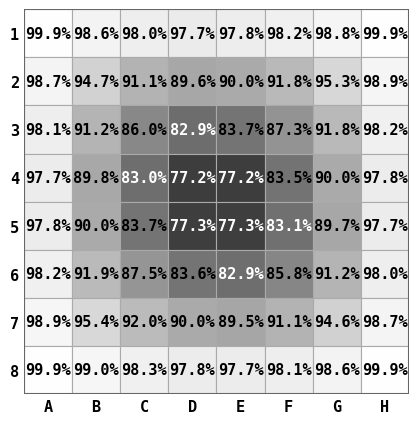

In [52]:
# Nanda probe accuracy by square - render_board style, grayscale heatmap.
# Convention: higher accuracy = LIGHTER fill.
HEATMAP_VMIN = 0.70   # tree-decoder range (adjust)   # lower bound of the grayscale mapping
HEATMAP_VMAX = 1.00   # upper bound of the grayscale mapping

# Reuse per-cell data loaded above (cell-25).
print(f'Grayscale range: {100 * HEATMAP_VMIN:.1f}% .. {100 * HEATMAP_VMAX:.1f}%')

# Normalize into [0, 1] within the visible band, with clipping.
norm = np.clip(
    (acc_cell - HEATMAP_VMIN) / max(HEATMAP_VMAX - HEATMAP_VMIN, 1e-9),
    0.0, 1.0)
# draw_board's heatmap maps value v -> fill (1-v, 1-v, 1-v).
# We want higher accuracy = lighter (whiter), so pass (1 - norm) so that
# high accuracy -> value 0 -> fill (1, 1, 1) = white.
heatmap = {(r, c): float(1.0 - norm[r, c])
           for r in range(8) for c in range(8)}

state = np.zeros((8, 8), dtype=np.int8)
highlights = {(r, c): {'label': f'{100 * acc_cell[r, c]:.1f}%'}
              for r in range(8) for c in range(8)}

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')
draw_board(ax, state, highlights=highlights, heatmap=heatmap,
           title=None,
           show_coords=True, fontsize=11)

out_path = os.path.join(TALK_DIR, 'j3_probe_accuracy_by_cell_gray.png')
plt.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()

### Mean transitions per game by square

Board style matches the decoding-accuracy heatmap.  Data is the average number of times each square flips per game (external computation, hardcoded below).  Grayscale keyed to that count; convention matches the accuracy figure — higher value = lighter fill.

Grayscale range: 1.00 .. 6.50 transitions/game
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/ogpt_mean_transitions_by_cell.png


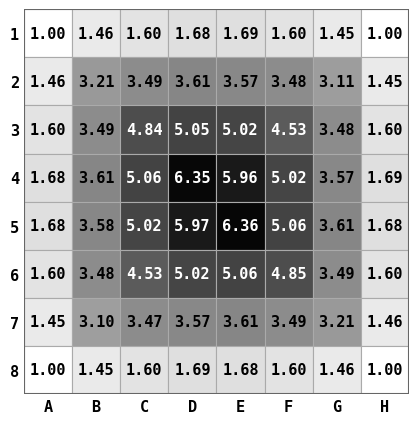

In [53]:
# Mean transitions per game by square - render_board style, grayscale heatmap.
# Convention: higher transitions = DARKER fill.

# Hardcoded flip counts (rows 0..7 = ranks 1..8; cols 0..7 = files a..h).
flips_cell = np.array([
    [1.00, 1.46, 1.60, 1.68, 1.69, 1.60, 1.45, 1.00],
    [1.46, 3.21, 3.49, 3.61, 3.57, 3.48, 3.11, 1.45],
    [1.60, 3.49, 4.84, 5.05, 5.02, 4.53, 3.48, 1.60],
    [1.68, 3.61, 5.06, 6.35, 5.96, 5.02, 3.57, 1.69],
    [1.68, 3.58, 5.02, 5.97, 6.36, 5.06, 3.61, 1.68],
    [1.60, 3.48, 4.53, 5.02, 5.06, 4.85, 3.49, 1.60],
    [1.45, 3.10, 3.47, 3.57, 3.61, 3.49, 3.21, 1.46],
    [1.00, 1.45, 1.60, 1.69, 1.68, 1.60, 1.46, 1.00],
], dtype=np.float64)

# Grayscale bounds (raw counts, not percentages).
FLIP_VMIN = 1.0
FLIP_VMAX = 6.5

print(f'Grayscale range: {FLIP_VMIN:.2f} .. {FLIP_VMAX:.2f} transitions/game')

# Normalize into [0, 1] within the visible band, with clipping.
flip_norm = np.clip(
    (flips_cell - FLIP_VMIN) / max(FLIP_VMAX - FLIP_VMIN, 1e-9),
    0.0, 1.0)
# draw_board's heatmap: v -> fill (1-v, 1-v, 1-v).  Higher transitions =
# darker means we pass `norm` directly (norm=1 -> fill (0,0,0) = black).
flip_heatmap = {(r, c): float(flip_norm[r, c])
                for r in range(8) for c in range(8)}

state = np.zeros((8, 8), dtype=np.int8)
flip_highlights = {(r, c): {'label': f'{flips_cell[r, c]:.2f}'}
                   for r in range(8) for c in range(8)}

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('white')
draw_board(ax, state, highlights=flip_highlights, heatmap=flip_heatmap,
           title=None,
           show_coords=True, fontsize=11)

out_path = os.path.join(TALK_DIR, 'ogpt_mean_transitions_by_cell.png')
plt.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()

## Section 5 — Intervention corruption vs alpha

For a chosen (game, turn), show the probe's decoded board at alphas 0, 1, 2, 3, 4, 5, 8 as a strip of 7 boards.  Target cell (3,3) is outlined in orange; cells where the probe's prediction disagrees with ground truth are outlined in red.

Data comes from `notebooks/talk_data/intervention_alpha_example.npz`, produced locally by:

```
python notebooks/prep_intervention_example.py --n-games 10 --top-k 50
```

/Users/jmorriso/Git/othello_world/notebooks/talk_boards/tile_empty.png


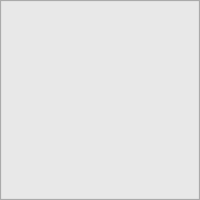

/Users/jmorriso/Git/othello_world/notebooks/talk_boards/tile_empty_box.png


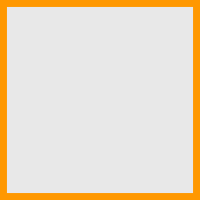

/Users/jmorriso/Git/othello_world/notebooks/talk_boards/tile_white.png


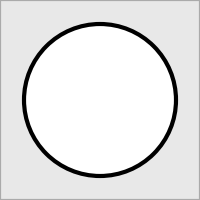

/Users/jmorriso/Git/othello_world/notebooks/talk_boards/tile_white_box.png


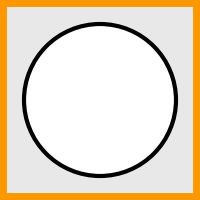

/Users/jmorriso/Git/othello_world/notebooks/talk_boards/tile_black.png


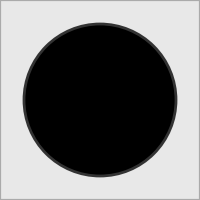

/Users/jmorriso/Git/othello_world/notebooks/talk_boards/tile_black_box.png


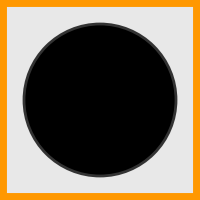

In [54]:
# Single-square tiles (one board cell each): empty, white piece, black piece -
# each plain and with our standard orange box (6 total). No white margin: axes fill the figure,
# and we preview the SAVED png (not plt.show, which pads the inline output).
from matplotlib.patches import Rectangle as _Rect, Circle as _Circ
from IPython.display import Image as _IPImage, display as _ipdisplay
ORANGE = '#ff9800'
def _square_tile(kind, out_name, box=False):
    fig = plt.figure(figsize=(1, 1)); fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1]); ax.set_axis_off()   # axes fill the whole figure -> no margin
    ax.add_patch(_Rect((-0.5, -0.5), 1.0, 1.0, facecolor='#e8e8e8',
                       edgecolor='#aaaaaa', linewidth=0.8, zorder=1))
    if kind == 'white':
        ax.add_patch(_Circ((0, 0), 0.38, facecolor='white', edgecolor='black',
                           linewidth=1.5, zorder=3))
    elif kind == 'black':
        ax.add_patch(_Circ((0, 0), 0.38, facecolor='black', edgecolor='#333333',
                           linewidth=1.0, zorder=3))
    if box:
        ax.add_patch(_Rect((-0.5, -0.5), 1.0, 1.0, fill=False, edgecolor=ORANGE,
                           linewidth=5.0, zorder=5))
    ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.5, 0.5)
    out = os.path.join(TALK_DIR, out_name)
    fig.savefig(out, dpi=200, facecolor='white')          # full 1x1 figure, no bbox padding
    plt.close(fig)
    print(out); _ipdisplay(_IPImage(filename=out))         # preview the exact saved file

for kind, base in [('empty', 'tile_empty'), ('white', 'tile_white'), ('black', 'tile_black')]:
    _square_tile(kind, base + '.png',     box=False)
    _square_tile(kind, base + '_box.png', box=True)

In [55]:
# Intervention example loader (works for any prep_intervention_example.py npz).

def load_intv(path):
    """Load an intervention-example npz and return a bundle usable by
    render_intv_board / render_intv_all_alphas."""
    d = np.load(path, allow_pickle=True)
    alphas = list(d['alphas'])
    target = tuple(d['target_rc'])
    game_idx = list(map(int, d['game_idx']))
    turns = list(map(int, d['turn']))
    index = {(int(g), int(t)): k
             for k, (g, t) in enumerate(zip(game_idx, turns))}
    print(f'Loaded {len(game_idx)} candidates from {path}   '
          f'(target = {target}, alphas = {alphas})')
    return {
        'path': path,
        'alphas': alphas,
        'target': target,
        'index': index,
        'preds_by_alpha': d['preds_by_alpha'],
        'gt_class': d['gt_class'],
        'gt_state': d['gt_state'],
        'flips_by_alpha': d['flips_by_alpha'],
        'errors_vs_gt': d['errors_vs_gt'],
    }


def probe_class_to_state(pred_class):
    """(8, 8) int in {0, 1, 2} -> (8, 8) int8 in {0, -1, +1}."""
    out = np.zeros_like(pred_class, dtype=np.int8)
    out[pred_class == 0] = 0
    out[pred_class == 1] = -1
    out[pred_class == 2] = 1
    return out


def render_intv_board(intv, game_idx, turn, alpha_idx, out_name,
                       figsize=(5, 5), show_coords=True):
    """Render a single probe-decoded board for one (game, turn, alpha).

    Orange border on the target cell; red border on wrong cells
    (probe class != ground-truth class).  `intv` is a bundle from load_intv.
    """
    key = (int(game_idx), int(turn))
    if key not in intv['index']:
        raise KeyError(f'(game_idx={game_idx}, turn={turn}) not in {intv["path"]}. '
                       f'Available (first 10): {list(intv["index"].keys())[:10]}')
    k = intv['index'][key]
    alpha = intv['alphas'][alpha_idx]
    pred = intv['preds_by_alpha'][k, alpha_idx]
    gt_class = intv['gt_class'][k]
    state = probe_class_to_state(pred)

    highlights = {}
    wrong = np.argwhere(pred != gt_class)
    for r, c in wrong:
        highlights[(int(r), int(c))] = {'border': 'red', 'border_lw': 3.5}
    tr, tc = intv['target']
    highlights[(int(tr), int(tc))] = {'border': 'orange', 'border_lw': 4.0}

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights,
               title=None,
               show_coords=show_coords, fontsize=10)
    out_path = os.path.join(TALK_DIR, out_name)
    plt.savefig(out_path, dpi=200, facecolor='white')
    print(f'  saved {out_path}')
    plt.show()


def render_intv_all_alphas(intv, game_idx, turn, prefix, figsize=(5, 5),
                            show_coords=True):
    """Render one PNG per alpha for the given pick."""
    for ai, alpha in enumerate(intv['alphas']):
        out_name = f'{prefix}_a{ai}.png'
        render_intv_board(intv, game_idx, turn, alpha_idx=ai,
                          out_name=out_name, figsize=figsize,
                          show_coords=show_coords)


# Default (3,3) bundle, used by the original picks below.
intv33 = load_intv(os.path.join(REPO_ROOT,
    'notebooks/talk_data/intervention_alpha_example.npz'))

Loaded 50 candidates from /Users/jmorriso/Git/othello_world/notebooks/talk_data/intervention_alpha_example.npz   (target = (3, 3), alphas = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0])


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g709_t35_a0.png


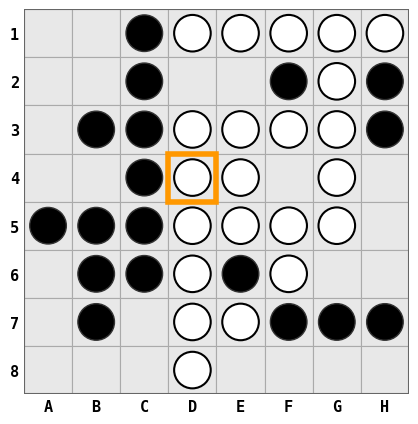

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g709_t35_a1.png


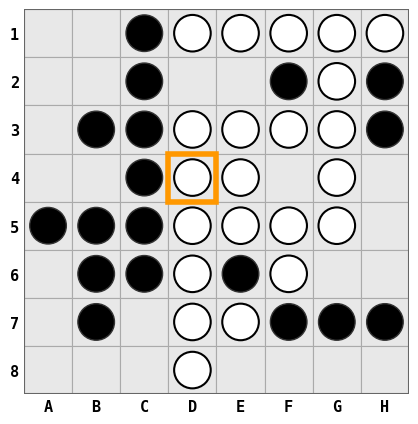

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g709_t35_a2.png


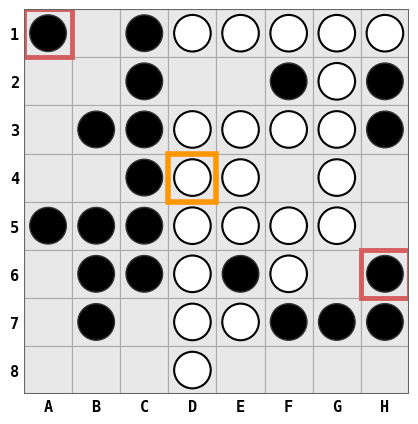

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g709_t35_a3.png


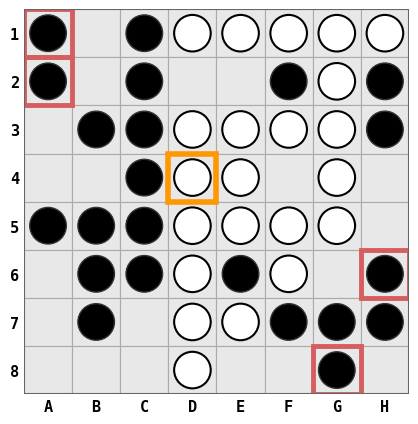

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g709_t35_a4.png


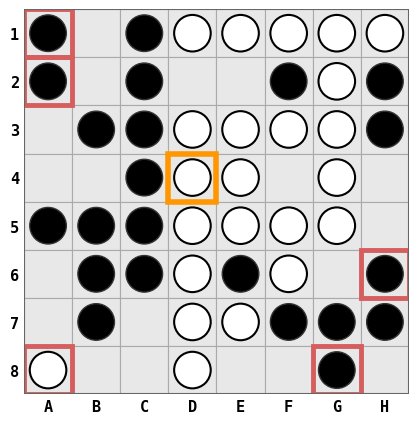

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g709_t35_a5.png


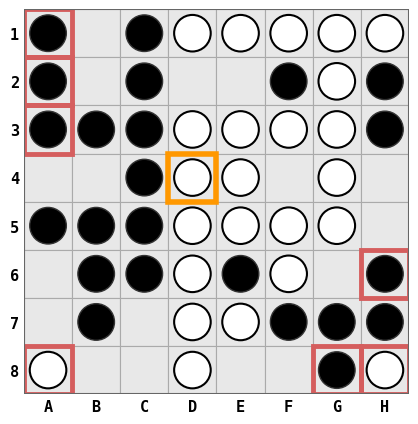

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g709_t35_a6.png


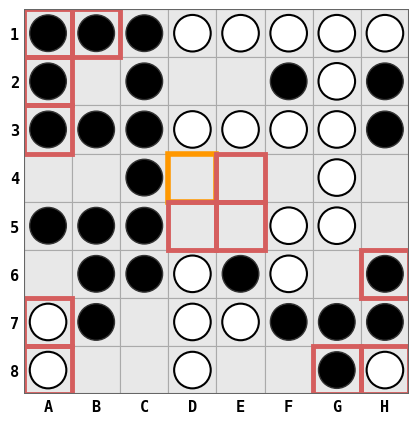

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g2473_t35_a0.png


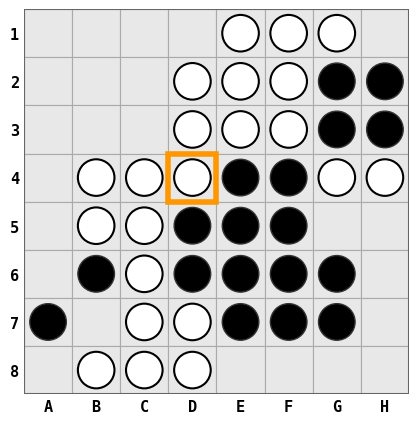

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g2473_t35_a1.png


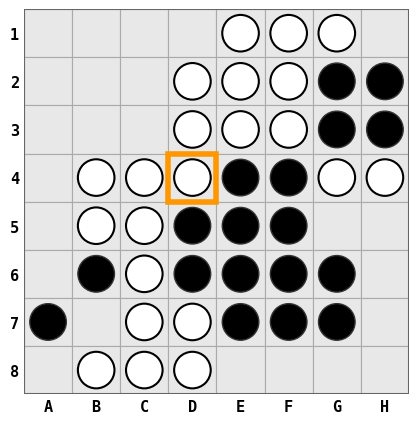

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g2473_t35_a2.png


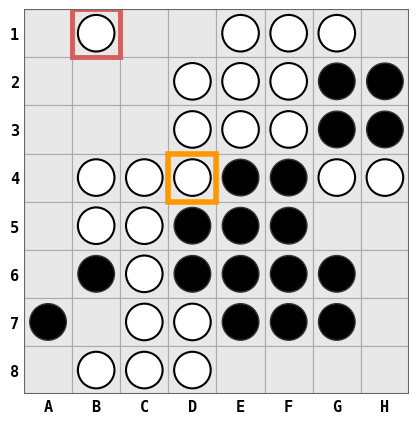

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g2473_t35_a3.png


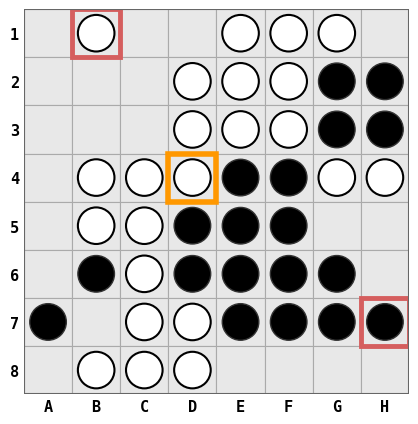

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g2473_t35_a4.png


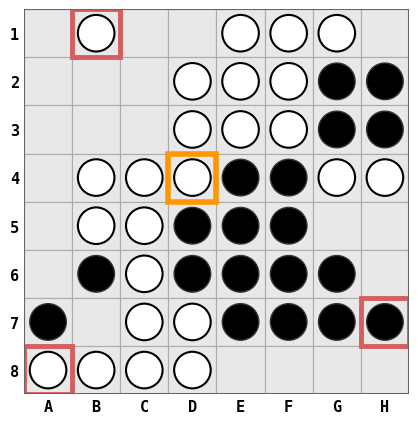

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g2473_t35_a5.png


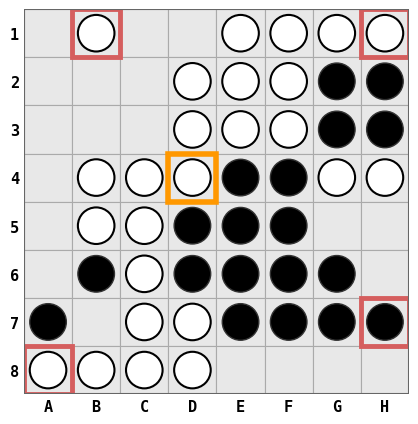

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv33_g2473_t35_a6.png


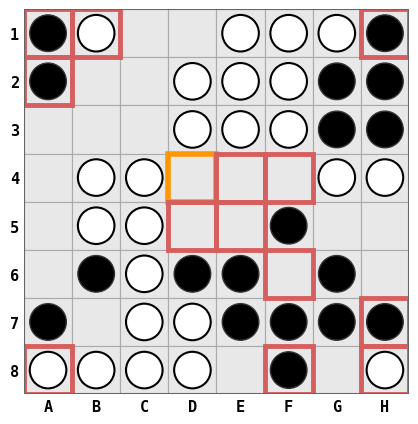

In [56]:
# Two picks from the top-50 at target (3,3):
#   (709, 35)  - flips 0,0,2,4,5,7,13   errors_vs_gt 0,0,2,4,5,7,13
#   (2473, 35) - flips 0,0,1,2,3,4,14   errors_vs_gt 0,0,1,2,3,4,14
#
# Saves 7 distinct PNGs per pick, named intv_g<game>_t<turn>_a<idx>.png
# where alpha_idx 0..6 maps to alphas 0, 1, 2, 3, 4, 5, 8.

render_intv_all_alphas(intv33, game_idx=709,  turn=35, prefix='intv33_g709_t35')
render_intv_all_alphas(intv33, game_idx=2473, turn=35, prefix='intv33_g2473_t35')

Loaded 50 candidates from /Users/jmorriso/Git/othello_world/notebooks/talk_data/intervention_alpha_example_r2c3.npz   (target = (2, 3), alphas = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0])
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23_g751_t30_a0.png


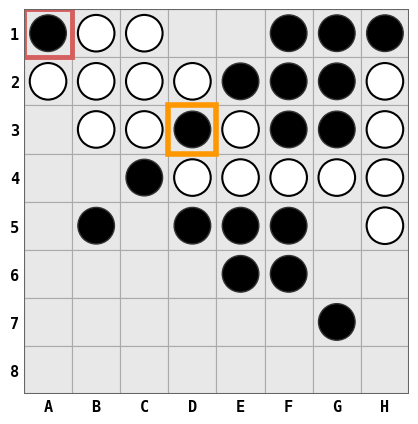

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23_g751_t30_a1.png


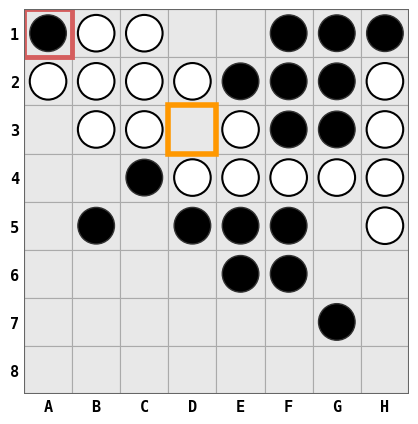

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23_g751_t30_a2.png


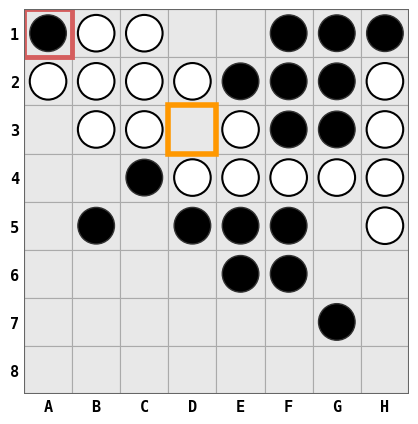

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23_g751_t30_a3.png


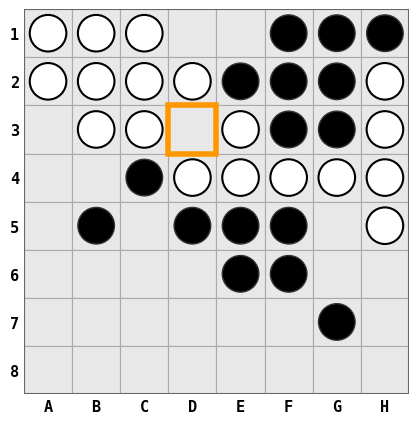

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23_g751_t30_a4.png


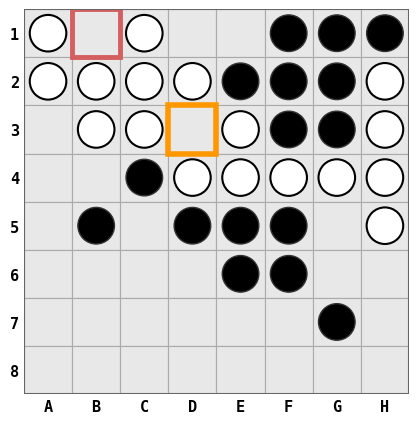

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23_g751_t30_a5.png


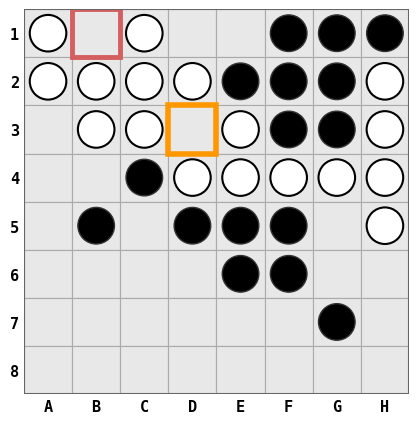

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23_g751_t30_a6.png


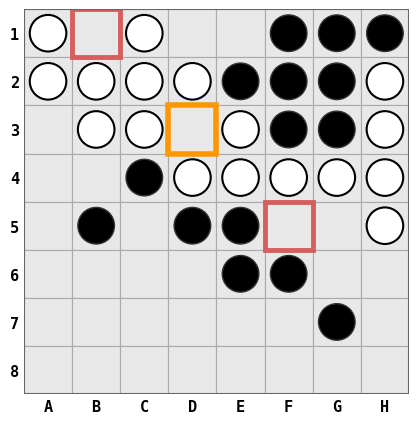

In [57]:
# Pick from the (2,3) search — earlier turns:
#   game 751, turn 30 - flips 0,1,1,2,3,3,4   errors_vs_gt 1,2,2,1,2,2,3
intv23 = load_intv(os.path.join(REPO_ROOT,
    'notebooks/talk_data/intervention_alpha_example_r2c3.npz'))

render_intv_all_alphas(intv23, game_idx=751, turn=30, prefix='intv23_g751_t30')

Loaded 50 candidates from /Users/jmorriso/Git/othello_world/notebooks/talk_data/intervention_alpha_example_r2c3_flip.npz   (target = (2, 3), alphas = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0])
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_g751_t30_a0.png


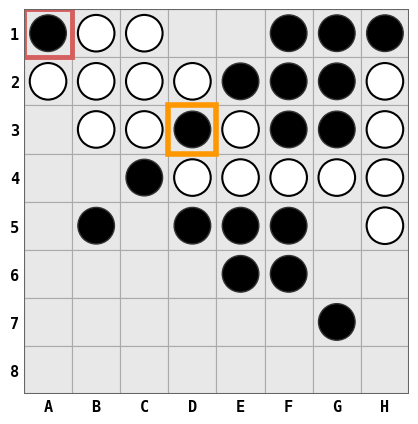

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_g751_t30_a1.png


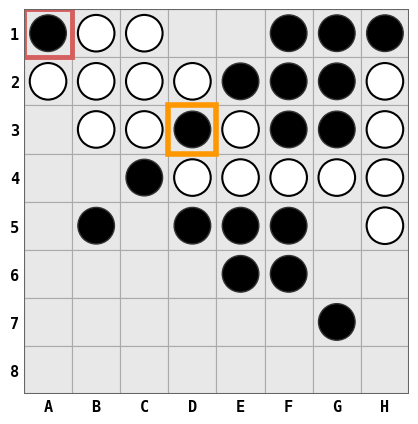

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_g751_t30_a2.png


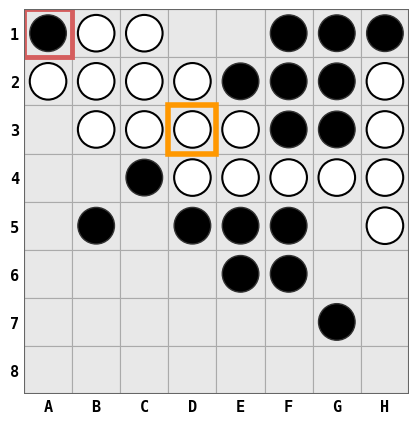

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_g751_t30_a3.png


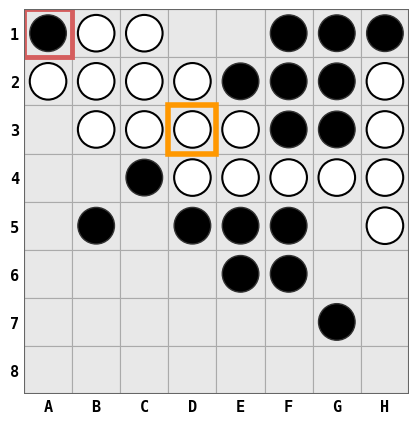

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_g751_t30_a4.png


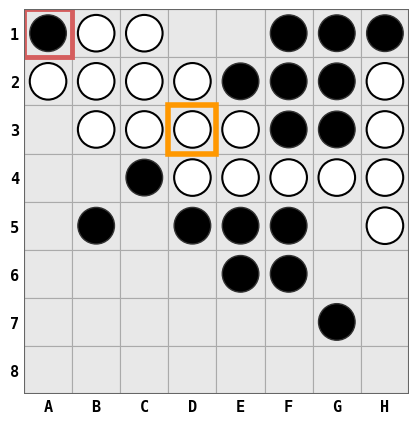

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_g751_t30_a5.png


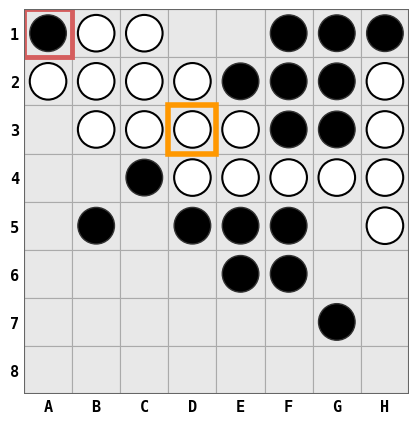

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_g751_t30_a6.png


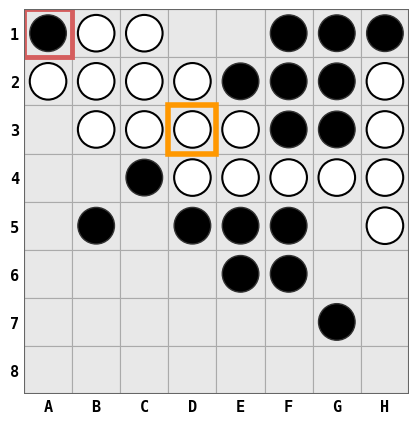

In [58]:
# Same (2,3) target, same game 751 turn 30, but FLIP intervention
# (push toward opposite color) instead of empty.
intv23_flip = load_intv(os.path.join(REPO_ROOT,
    'notebooks/talk_data/intervention_alpha_example_r2c3_flip.npz'))

render_intv_all_alphas(intv23_flip, game_idx=751, turn=30,
                       prefix='intv23flip_g751_t30')

Loaded 50 candidates from /Users/jmorriso/Git/othello_world/notebooks/talk_data/intervention_alpha_example_r2c3_flip_late.npz   (target = (2, 3), alphas = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0])
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_late_g3152_t40_a0.png


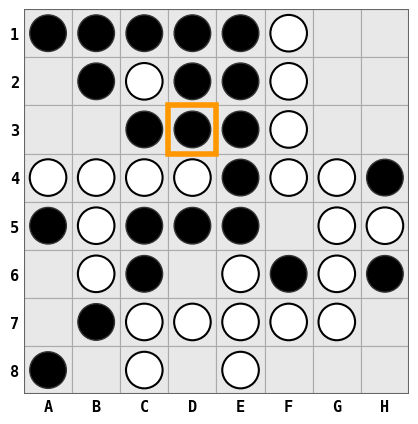

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_late_g3152_t40_a1.png


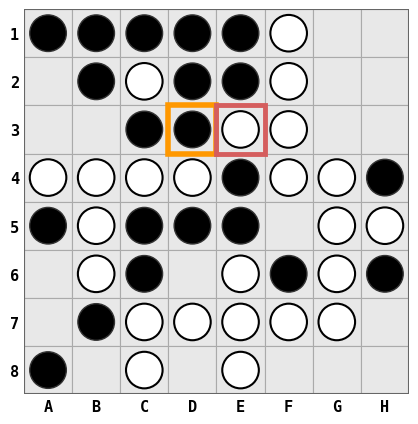

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_late_g3152_t40_a2.png


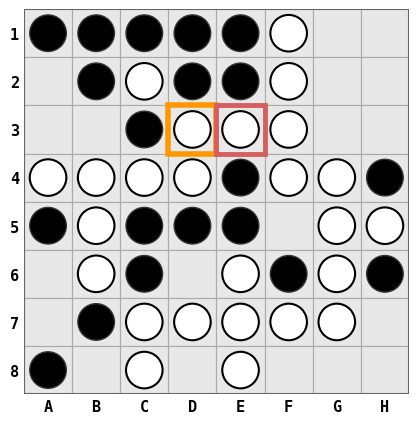

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_late_g3152_t40_a3.png


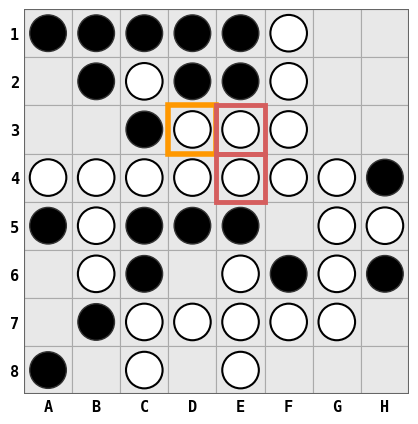

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_late_g3152_t40_a4.png


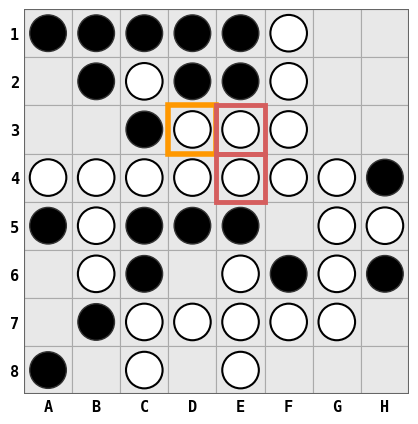

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_late_g3152_t40_a5.png


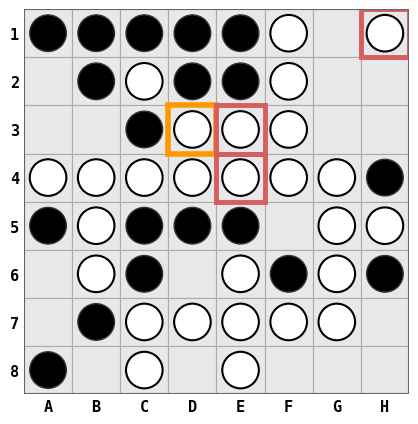

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intv23flip_late_g3152_t40_a6.png


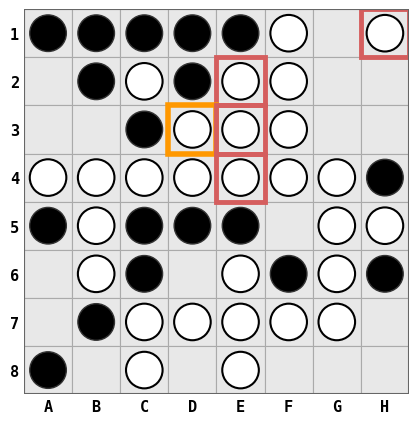

In [59]:
# Pick from the (2,3) FLIP search — later turns:
#   game 3152, turn 40 - flips 0,1,2,3,3,4,5   errors_vs_gt 0,1,2,3,3,4,5
# Clean baseline (0 errors at α=0), monotone growth of both flips and
# errors — one new wrong cell per alpha step.
intv23_flip_late = load_intv(os.path.join(REPO_ROOT,
    'notebooks/talk_data/intervention_alpha_example_r2c3_flip_late.npz'))

render_intv_all_alphas(intv23_flip_late, game_idx=3152, turn=40,
                       prefix='intv23flip_late_g3152_t40')

## Section 6 — New-squares transfer experiment

Two board variants used to measure how fast OthelloGPT learns 8 *new*
squares (vocab expanded 61 -> 69).  Geometry follows `new_squares_data.py`
(fair design):

* **Coherent (condition 0)** — the 8 new squares slot in as a 9th row
  (A9-H9, cells 64-71) directly below row 8; their flanks into the existing
  board follow local, aligned geometry (straight up + diagonals).
* **Incoherent (condition 1)** — the 8 new squares form the *same* 9th row
  and share the *same* along-the-row flanking structure, but each square's
  flanks *into the existing board* connect to **randomly chosen** cells
  (seed 42) instead of local geometry.

So the conditions are matched on everything (row layout, along-row structure,
rule count, chain lengths) except the one manipulated variable: whether a new
square's connection to the existing board is spatially **coherent** or
**arbitrary**.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/newsquares_coherent.png


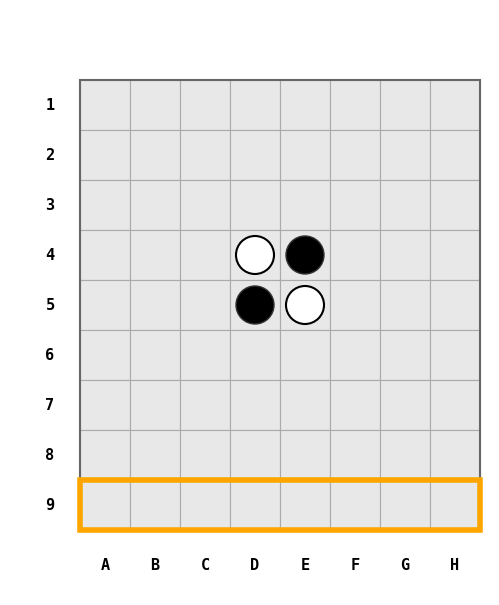

In [60]:
# Section 6a - Coherent new squares: a 9th row (A9-H9).
# Standard 8x8 board plus 8 new cells (64-71) appended as row 9, directly
# below row 8.  One orange rectangle wraps the whole new row to flag it.
# Geometry from new_squares_experiment.py (condition 0, create_coherent_rules).

CELL_FILL = '#e8e8e8'
CELL_EDGE = '#aaaaaa'
BOARD_EDGE = '#666666'
DISC_R = 0.38
START_DISCS = [(3, 3, -1), (3, 4, 1), (4, 3, 1), (4, 4, -1)]  # d4/e4/d5/e5

# Shared sizing for BOTH Section 6 figures.  A board cell is 1 data unit;
# SCALE inches/unit is fixed, and each figure is sized from its own data
# extent, so squares + coord labels render at the SAME absolute size in
# each PNG.  Fig 6b just ends up physically larger to fit the ring.
SCALE = 0.5       # inches per board cell (per data unit)
LABEL_FS = 11     # coord letter/number font size (points; absolute)
TITLE_FS = 12
DPI = 200


def _draw_cell(ax, r, c, fill=CELL_FILL):
    ax.add_patch(mpatches.Rectangle((c - 0.5, r - 0.5), 1.0, 1.0,
                 facecolor=fill, edgecolor=CELL_EDGE, linewidth=0.8, zorder=1))


def _draw_disc(ax, r, c, v):
    if v == 1:
        ax.add_patch(mpatches.Circle((c, r), DISC_R, facecolor='black',
                     edgecolor='#333333', linewidth=1.0, zorder=3))
    else:
        ax.add_patch(mpatches.Circle((c, r), DISC_R, facecolor='white',
                     edgecolor='black', linewidth=1.5, zorder=3))


def _make_fixed_scale_ax(xlim, ylim):
    """Figure whose axes fills it at exactly SCALE inches per data unit.
    xlim/ylim are (min, max) in data units; y is drawn inverted."""
    xspan = xlim[1] - xlim[0]
    yspan = ylim[1] - ylim[0]
    fig = plt.figure(figsize=(xspan * SCALE, yspan * SCALE))
    fig.patch.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])   # fill the figure -> scale == SCALE
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[1], ylim[0])     # inverted y
    ax.set_aspect('equal')
    ax.axis('off')
    return fig, ax


def _title(ax, xlim, ylim, text):
    ax.text((xlim[0] + xlim[1]) / 2, ylim[0] + 0.55, text,
            ha='center', va='center', fontsize=TITLE_FS, fontweight='bold')


# data extent: title band on top, gutters for coord labels
X_LIM = (-1.9, 7.7)
Y_LIM = (-1.9, 9.8)

fig, ax = _make_fixed_scale_ax(X_LIM, Y_LIM)

# 8x8 board + starting discs
for r in range(8):
    for c in range(8):
        _draw_cell(ax, r, c)
for r, c, v in START_DISCS:
    _draw_disc(ax, r, c, v)

# 9th row (row index 8): 8 new empty cells
for c in range(8):
    _draw_cell(ax, 8, c)

# outline of the standard 8x8 board
ax.add_patch(mpatches.Rectangle((-0.5, -0.5), 8, 8, facecolor='none',
             edgecolor=BOARD_EDGE, linewidth=1.5, zorder=7))
# one orange rectangle around all 8 new squares in row 9
ax.add_patch(mpatches.Rectangle((-0.5, 7.5), 8, 1, facecolor='none',
             edgecolor=HIGHLIGHT_COLOR, linewidth=OUTLINE_LW, zorder=8))

# coord labels (absolute font size)
for c in range(8):
    ax.text(c, 9.2, 'ABCDEFGH'[c], ha='center', va='center',
            fontsize=LABEL_FS, fontweight='bold')
for r in range(9):
    ax.text(-1.1, r, str(r + 1), ha='center', va='center',
            fontsize=LABEL_FS, fontweight='bold')

out_path = os.path.join(TALK_DIR, 'newsquares_coherent.png')
plt.savefig(out_path, dpi=DPI, facecolor='white')
print(f'  saved {out_path}')
plt.show()


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/newsquares_incoherent.png


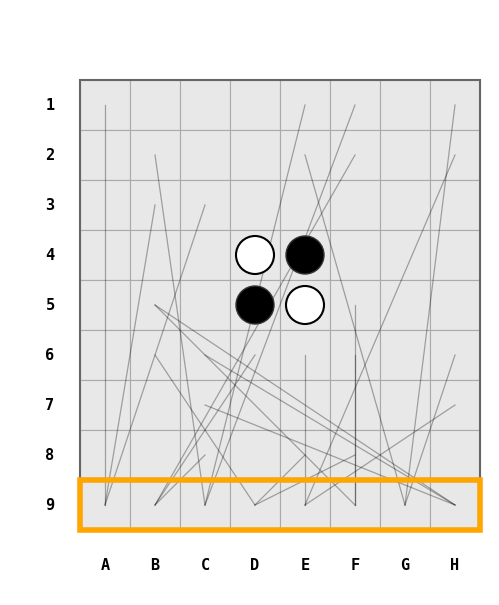

In [61]:
# Section 6b - Incoherent new squares (fair design): the SAME 9th row as the
# coherent condition, but each new square's flanks INTO the existing board
# connect to RANDOMLY chosen cells instead of local, aligned geometry.  The
# along-the-row flanks (new squares flanking each other) are SHARED with the
# coherent condition and identical -- so the ONLY difference is whether a new
# square's connection to the existing board is spatially local (coherent) or
# arbitrary (incoherent).  Rule generators inlined from new_squares_data.py
# (fair design); seed 42 = experiment default.  Reuses SCALE / helpers from 6a.
from collections import defaultdict

CENTER_CELLS = {27, 28, 35, 36}
N_NEW = 8
RULES_PER_SQUARE = 5
N_ALONG_ROW = 2
N_INTO_BOARD = RULES_PER_SQUARE - N_ALONG_ROW   # 3 into-board flanks per square
LINE_COLOR = 'black'
LINE_ALPHA = 0.32


def _rule_len(r):
    return len(r['opponents']) + 1


def _pick(cands, n):
    """Pick n rules, preferring distinct directions then shorter chains."""
    ordered = sorted(cands, key=lambda r: (len(r['opponents']), r['direction']))
    sel, dirs = [], set()
    for c in ordered:
        if c['direction'] not in dirs and len(sel) < n:
            sel.append(c); dirs.add(c['direction'])
    for c in ordered:
        if len(sel) >= n:
            break
        if c not in sel:
            sel.append(c)
    k = 0
    while len(sel) < n and ordered:
        sel.append(dict(ordered[k % len(ordered)])); k += 1
    return sel[:n]


def _coherent_into_board_candidates(i):
    """Flanks INTO the existing board from new square 64+i (straight up +
    diagonals through existing cells).  Used here only to length-match the
    incoherent (random) board connections one-for-one."""
    new_cell = 64 + i
    col = i
    cands = []
    chain = []
    for row in range(7, -1, -1):
        cell = row * 8 + col
        if cell in CENTER_CELLS:
            break
        chain.append(cell)
        if len(chain) >= 2:
            cands.append({'target': new_cell, 'opponents': list(chain[:-1]),
                          'terminal': chain[-1], 'direction': 'up'})
    chain = []
    r, c = 7, col + 1
    while r >= 0 and c < 8:
        cell = r * 8 + c
        if cell in CENTER_CELLS:
            break
        chain.append(cell)
        if len(chain) >= 2:
            cands.append({'target': new_cell, 'opponents': list(chain[:-1]),
                          'terminal': chain[-1], 'direction': 'diag_up_right'})
        r -= 1
        c += 1
    chain = []
    r, c = 7, col - 1
    while r >= 0 and c >= 0:
        cell = r * 8 + c
        if cell in CENTER_CELLS:
            break
        chain.append(cell)
        if len(chain) >= 2:
            cands.append({'target': new_cell, 'opponents': list(chain[:-1]),
                          'terminal': chain[-1], 'direction': 'diag_up_left'})
        r -= 1
        c -= 1
    return cands


def create_incoherent_rules(rng):
    """Fair design: the shared along-row block (identical to coherent, so it is
    omitted from the drawing) plus RANDOM into-board flanks whose chain lengths
    match coherent's into-board rules one-for-one."""
    playable = [c for c in range(64) if c not in CENTER_CELLS]
    rules = []
    for i in range(N_NEW):
        for r in _pick(_coherent_into_board_candidates(i), N_INTO_BOARD):
            n_opp = max(1, _rule_len(r) - 1)
            cells = rng.choice(playable, size=n_opp + 1, replace=False)
            rules.append({'target': 64 + i, 'opponents': cells[:-1].tolist(),
                          'terminal': int(cells[-1]),
                          'direction': 'random_into_board'})
    return rules


rng = np.random.RandomState(42)          # experiment default seed
inc_rules = create_incoherent_rules(rng)

# one line per into-board rule: new-row square -> its (random) first cell
board_adj = defaultdict(list)
for rule in inc_rules:
    board_adj[rule['target']].append(rule['opponents'][0])

# same data extent / proportions as fig 6a (9th row below the board)
X_LIM = (-1.9, 7.7)
Y_LIM = (-1.9, 9.8)
fig, ax = _make_fixed_scale_ax(X_LIM, Y_LIM)

# 8x8 board + starting discs (helpers/consts from Section 6a)
for r in range(8):
    for c in range(8):
        _draw_cell(ax, r, c)
for r, c, v in START_DISCS:
    _draw_disc(ax, r, c, v)

# 9th row (row index 8): 8 new empty cells -- SAME layout as the coherent fig
for c in range(8):
    _draw_cell(ax, 8, c)

# random board connections: each new-row square -> its random into-board cells
for i in range(8):
    for cell in board_adj[64 + i]:
        r0, c0 = cell // 8, cell % 8
        ax.plot([i, c0], [8, r0], color=LINE_COLOR,
                alpha=LINE_ALPHA, linewidth=0.9, zorder=2)

# board outline + orange rectangle around the 8 new squares
ax.add_patch(mpatches.Rectangle((-0.5, -0.5), 8, 8, facecolor='none',
             edgecolor=BOARD_EDGE, linewidth=1.5, zorder=7))
ax.add_patch(mpatches.Rectangle((-0.5, 7.5), 8, 1, facecolor='none',
             edgecolor=HIGHLIGHT_COLOR, linewidth=OUTLINE_LW, zorder=8))

# coord labels (same absolute font size as fig 6a)
for c in range(8):
    ax.text(c, 9.2, 'ABCDEFGH'[c], ha='center', va='center',
            fontsize=LABEL_FS, fontweight='bold')
for r in range(9):
    ax.text(-1.1, r, str(r + 1), ha='center', va='center',
            fontsize=LABEL_FS, fontweight='bold')

out_path = os.path.join(TALK_DIR, 'newsquares_incoherent.png')
plt.savefig(out_path, dpi=DPI, facecolor='white')
print(f'  saved {out_path}')
plt.show()


### Section 6c — rule panels

For one new square (**D9**), all of its *into-board* rules under each condition.  In every panel: **1** = the move (blank square), a **white** disc = an opponent piece, a **black** disc = the own/terminal piece; each referenced cell is boxed in orange and numbered in flank order.  The along-row flanks are identical across conditions and omitted here — only the board connections differ: **coherent** flanks are aligned runs, **incoherent** flanks reference random scattered cells.

In [ ]:
# Section 6c - Rule panels: all into-board rules for one new square, coherent
# vs incoherent.  Per cell: 1 = the move (blank square), white disc = opponent,
# black disc = own/terminal; every referenced cell boxed in orange and numbered
# in flank order (target -> opponents -> terminal).  Self-contained (own rule
# generators, fair design from new_squares_data.py).  Along-row rules are shared
# between conditions and omitted here -- only the into-board flanks differ.
CEN = {27, 28, 35, 36}
SQ = 3                              # chosen new square: column 3 = D9 (cell 67)
DR = 0.40   # disc radius: room for the number to sit inside the border
PANEL_HL = 'orange'
PANEL_CELL = '#eeeeee'; PANEL_EDGE = '#bbbbbb'; PANEL_BOARD = '#666666'


def _rp_pick(cands, n):
    o = sorted(cands, key=lambda r: (len(r['opponents']), r['direction']))
    sel, dirs = [], set()
    for c in o:
        if c['direction'] not in dirs and len(sel) < n:
            sel.append(c); dirs.add(c['direction'])
    for c in o:
        if len(sel) >= n:
            break
        if c not in sel:
            sel.append(c)
    k = 0
    while len(sel) < n and o:
        sel.append(dict(o[k % len(o)])); k += 1
    return sel[:n]


def _rp_coh_into(i):
    nc = 64 + i; col = i; C = []; ch = []
    for row in range(7, -1, -1):
        cell = row * 8 + col
        if cell in CEN:
            break
        ch.append(cell)
        if len(ch) >= 2:
            C.append({'target': nc, 'opponents': list(ch[:-1]), 'terminal': ch[-1], 'direction': 'up'})
    ch = []; r, c = 7, col + 1
    while r >= 0 and c < 8:
        cell = r * 8 + c
        if cell in CEN:
            break
        ch.append(cell)
        if len(ch) >= 2:
            C.append({'target': nc, 'opponents': list(ch[:-1]), 'terminal': ch[-1], 'direction': 'dr'})
        r -= 1; c += 1
    ch = []; r, c = 7, col - 1
    while r >= 0 and c >= 0:
        cell = r * 8 + c
        if cell in CEN:
            break
        ch.append(cell)
        if len(ch) >= 2:
            C.append({'target': nc, 'opponents': list(ch[:-1]), 'terminal': ch[-1], 'direction': 'dl'})
        r -= 1; c -= 1
    return C


def _rp_coh_rules(i):
    return _rp_pick(_rp_coh_into(i), 3)


def _rp_inc_rules(i, rng):
    play = [c for c in range(64) if c not in CEN]
    out = []
    for r in _rp_pick(_rp_coh_into(i), 3):
        L = len(r['opponents']) + 1
        cells = rng.choice(play, size=L, replace=False).tolist()
        out.append({'target': 64 + i, 'opponents': cells[:-1], 'terminal': cells[-1], 'direction': 'random'})
    return out


def _rp_rc(cell):
    return (8, cell - 64) if cell >= 64 else (cell // 8, cell % 8)


def _rp_draw(ax, rule):
    # Incoherent rules (direction=="random") are drawn with the new square
    # FLOATING just off the board (a square "around the board", as in Audition B)
    # numbered as the move -- no 9th row.  Coherent rules keep the 9th row.
    incoh = rule.get('direction') == 'random'
    nrows = 8 if incoh else 9
    TPOS = (3.5, -3.0)                             # farthest-left ring position (Audition B); (row, col)
    for r in range(nrows):
        for c in range(8):
            ax.add_patch(mpatches.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor=PANEL_CELL,
                         edgecolor=PANEL_EDGE, linewidth=0.5, zorder=1))
    ax.add_patch(mpatches.Rectangle((-0.5, -0.5), 8, 8, facecolor='none', edgecolor=PANEL_BOARD, linewidth=1.2, zorder=3))
    if not incoh:
        ax.add_patch(mpatches.Rectangle((-0.5, 7.5), 8, 1, facecolor='none', edgecolor='#999999', linewidth=1.0, zorder=3))
    seq = [('target', rule['target'])] + [('opp', o) for o in rule['opponents']] + [('term', rule['terminal'])]
    for k, (role, cell) in enumerate(seq, 1):
        if role == 'target' and incoh:
            r, c = TPOS
            ax.add_patch(mpatches.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor='white',
                         edgecolor=PANEL_EDGE, linewidth=0.8, zorder=2))   # the floating new square
        else:
            r, c = _rp_rc(cell)
        ax.add_patch(mpatches.Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor='none', edgecolor=PANEL_HL, linewidth=2.6, zorder=4))
        if role == 'target':                       # the move -> blank cell
            ax.text(c, r, str(k), ha='center', va='center', fontsize=9, fontweight='bold', color='black', zorder=6)
        else:
            face = 'white' if role == 'opp' else 'black'
            txt = 'black' if role == 'opp' else 'white'
            ax.add_patch(mpatches.Circle((c, r), DR, facecolor=face, edgecolor='black', linewidth=1.4, zorder=5))
            ax.text(c, r, str(k), ha='center', va='center', fontsize=9, fontweight='bold', color=txt, zorder=6)
    for c in range(8):                             # coordinate labels A-H (bottom) / 1-8 or 1-9 (left)
        ax.text(c, nrows - 0.05, 'ABCDEFGH'[c], ha='center', va='center', fontsize=11, fontweight='bold')
    for r in range(nrows):
        ax.text(-1.0, r, str(r + 1), ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_xlim((-4.2, 7.7) if incoh else (-1.4, 7.7))
    ax.set_ylim((8.4, -0.7) if incoh else (9.4, -0.7))
    ax.set_aspect('equal'); ax.axis('off')


_rp_coh = _rp_coh_rules(SQ)
_rp_inc = _rp_inc_rules(SQ, np.random.RandomState(42))
fig, axes = plt.subplots(2, 3, figsize=(10.5, 7)); fig.patch.set_facecolor('white')
for j in range(3):
    _rp_draw(axes[0, j], _rp_coh[j])
for j in range(3):
    _rp_draw(axes[1, j], _rp_inc[j])
axes[0, 0].text(-0.32, 0.5, 'COHERENT', transform=axes[0, 0].transAxes, rotation=90, va='center', ha='center', fontsize=13, fontweight='bold')
axes[1, 0].text(-0.32, 0.5, 'INCOHERENT', transform=axes[1, 0].transAxes, rotation=90, va='center', ha='center', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0.03, 0, 1, 0.94])
out_path = os.path.join(TALK_DIR, f"newsquares_rules_{'ABCDEFGH'[SQ]}9.png")
fig.savefig(out_path, dpi=200, facecolor='white')
print(f'  saved {out_path}')
plt.show()


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/newsquares_rules_D9_cols.png


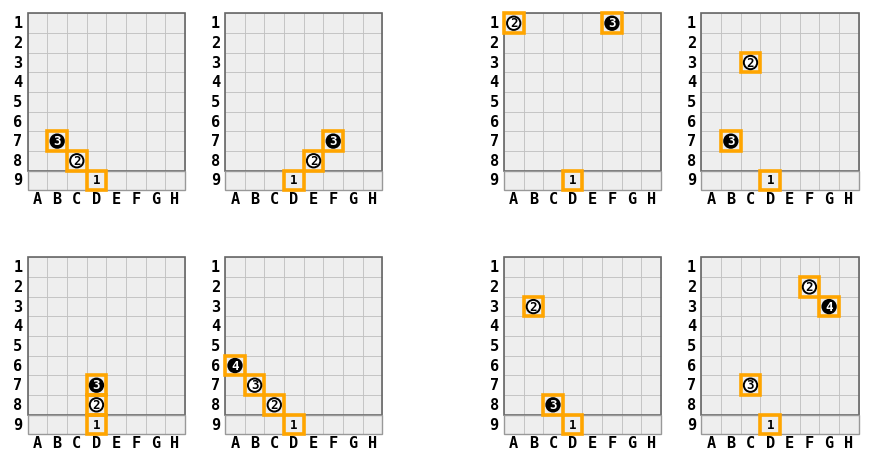

In [63]:
# Section 6c (2-column variant): coherent (left 2x2) vs incoherent (right 2x2),
# 4 into-board rules each. No titles/labels -- add them on the slide. Reuses the
# _rp_* helpers + SQ / CEN defined in the Section 6c cell above; run that first.
_coh4 = _rp_pick(_rp_coh_into(SQ), 4)
_rng = np.random.RandomState(42)
_play = [c for c in range(64) if c not in CEN]
_inc4 = []
for _r in _rp_pick(_rp_coh_into(SQ), 4):
    _L = len(_r['opponents']) + 1
    _cells = _rng.choice(_play, size=_L, replace=False).tolist()
    _inc4.append({'target': 64 + SQ, 'opponents': _cells[:-1], 'terminal': _cells[-1], 'direction': 'random'})

fig = plt.figure(figsize=(11, 6)); fig.patch.set_facecolor('white')
gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 0.35, 1, 1], wspace=0.12, hspace=0.12)
for _k, (_r, _c) in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)]):     # coherent, left 2x2
    _rp_draw(fig.add_subplot(gs[_r, _c]), _coh4[_k])
for _k, (_r, _c) in enumerate([(0, 3), (0, 4), (1, 3), (1, 4)]):     # incoherent, right 2x2
    _rp_draw(fig.add_subplot(gs[_r, _c]), _inc4[_k])
_out = os.path.join(TALK_DIR, f"newsquares_rules_{'ABCDEFGH'[SQ]}9_cols.png")
fig.savefig(_out, dpi=200, facecolor='white', bbox_inches='tight'); print('  saved', _out); plt.show()

### Section 6 — figure auditions (A / B / C)

Scratch cells to compare figure options.  **Run cell 6a first** (it defines the
shared drawing helpers), then run the *setup* cell, then A / B / C:

* **A** — incoherent as a *row* + random board connections
* **B** — incoherent as a *ring* + along-row lines (blue) + random board connections
* **C** — coherent 9th row + along-row (blue) + local into-board lines

Once you pick, tell me the pair and I'll write them into cells 6a/6b and delete these.

In [64]:
# --- Section 6 auditions: shared extras.  Run cell 6a first (defines
# _draw_cell / _draw_disc / _make_fixed_scale_ax / START_DISCS / BOARD_EDGE /
# HIGHLIGHT_COLOR / OUTLINE_LW / LABEL_FS).  Then run the setup + A / B / C
# below to compare; keep the winners, delete the rest.
from collections import defaultdict

LINE = 'black'                 # all flank lines are the same colour
A_RAND = 0.30                  # into-board / random flanks (faint)
A_ROW = 0.55                   # along-row flanks (same colour, a touch more solid)
CEN = {27, 28, 35, 36}


def _board_bg(ax):
    for r in range(8):
        for c in range(8):
            _draw_cell(ax, r, c)
    for r, c, v in START_DISCS:
        _draw_disc(ax, r, c, v)
    ax.add_patch(mpatches.Rectangle((-0.5, -0.5), 8, 8, facecolor='none',
                 edgecolor=BOARD_EDGE, linewidth=1.5, zorder=7))


def _pick(cands, n):
    ordered = sorted(cands, key=lambda r: (len(r['opponents']), r['direction']))
    sel, dirs = [], set()
    for c in ordered:
        if c['direction'] not in dirs and len(sel) < n:
            sel.append(c); dirs.add(c['direction'])
    for c in ordered:
        if len(sel) >= n:
            break
        if c not in sel:
            sel.append(c)
    k = 0
    while len(sel) < n and ordered:
        sel.append(dict(ordered[k % len(ordered)])); k += 1
    return sel[:n]


def _coh_into_board(i):
    """Coherent into-board flanks for new square 64+i (up + diagonals through
    existing cells).  Returns rule dicts with opponents/terminal."""
    nc = 64 + i; col = i; cands = []
    ch = []
    for row in range(7, -1, -1):
        cell = row * 8 + col
        if cell in CEN: break
        ch.append(cell)
        if len(ch) >= 2:
            cands.append({'target': nc, 'opponents': list(ch[:-1]), 'terminal': ch[-1], 'direction': 'up'})
    ch = []; r, c = 7, col + 1
    while r >= 0 and c < 8:
        cell = r * 8 + c
        if cell in CEN: break
        ch.append(cell)
        if len(ch) >= 2:
            cands.append({'target': nc, 'opponents': list(ch[:-1]), 'terminal': ch[-1], 'direction': 'dr'})
        r -= 1; c += 1
    ch = []; r, c = 7, col - 1
    while r >= 0 and c >= 0:
        cell = r * 8 + c
        if cell in CEN: break
        ch.append(cell)
        if len(ch) >= 2:
            cands.append({'target': nc, 'opponents': list(ch[:-1]), 'terminal': ch[-1], 'direction': 'dl'})
        r -= 1; c -= 1
    return cands


def _rand_into_first(rng):
    """3 random first-cells per new square (incoherent board connections)."""
    play = [c for c in range(64) if c not in CEN]
    return {i: [int(rng.choice(play)) for _ in range(3)] for i in range(8)}


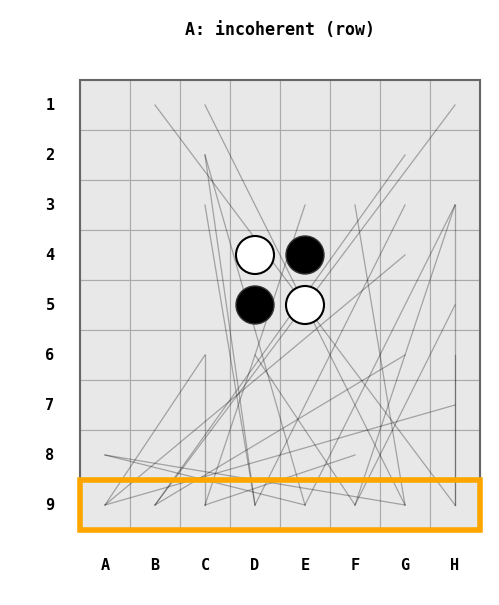

In [65]:
# Audition A - incoherent as a ROW + 3 random board connections per square
fig, ax = _make_fixed_scale_ax((-1.9, 7.7), (-1.9, 9.8)); _board_bg(ax)
for c in range(8):
    _draw_cell(ax, 8, c)
d = _rand_into_first(np.random.RandomState(42))
for i in range(8):
    for cell in d[i]:
        ax.plot([i, cell % 8], [8, cell // 8], color=LINE, alpha=A_RAND, lw=0.9, zorder=2)
ax.add_patch(mpatches.Rectangle((-0.5, 7.5), 8, 1, facecolor='none',
             edgecolor=HIGHLIGHT_COLOR, linewidth=OUTLINE_LW, zorder=8))
for c in range(8):
    ax.text(c, 9.2, 'ABCDEFGH'[c], ha='center', va='center', fontsize=LABEL_FS, fontweight='bold')
for r in range(9):
    ax.text(-1.1, r, str(r + 1), ha='center', va='center', fontsize=LABEL_FS, fontweight='bold')
ax.text(3.5, -1.4, 'A: incoherent (row)', ha='center', fontsize=12, fontweight='bold')
plt.show()


In [ ]:
# Audition B - incoherent as a RING + along-row flanks + 3 random board flanks
R = 6.5; bcx, bcy = 3.5, 3.5
ring = {i: (bcx + R * np.cos(np.pi / 2 - i * 2 * np.pi / 8),
            bcy - R * np.sin(np.pi / 2 - i * 2 * np.pi / 8)) for i in range(8)}
fig, ax = _make_fixed_scale_ax((-4.2, 11.2), (-5.4, 11.2)); _board_bg(ax)
d = _rand_into_first(np.random.RandomState(42))
for i in range(8):                      # random board connections (incoherence)
    x, y = ring[i]
    for cell in d[i]:
        ax.plot([x, cell % 8], [y, cell // 8], color=LINE, alpha=A_RAND, lw=0.9, zorder=2)
for i in range(7):                      # shared along-row flanks (same colour)
    x0, y0 = ring[i]; x1, y1 = ring[i + 1]
    ax.plot([x0, x1], [y0, y1], color=LINE, alpha=A_ROW, lw=1.4, zorder=4)
for i in range(8):
    x, y = ring[i]
    ax.add_patch(mpatches.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor='white',
                 edgecolor=HIGHLIGHT_COLOR, linewidth=OUTLINE_LW, zorder=5))
for c in range(8):
    ax.text(c, 8.05, 'ABCDEFGH'[c], ha='center', va='center', fontsize=LABEL_FS, fontweight='bold')
for r in range(8):
    ax.text(-1.05, r, str(r + 1), ha='center', va='center', fontsize=LABEL_FS, fontweight='bold')
_ring_out = os.path.join(TALK_DIR, 'newsquares_incoherent_ring.png')
fig.savefig(_ring_out, dpi=DPI, facecolor='white'); print('  saved', _ring_out)
plt.show()


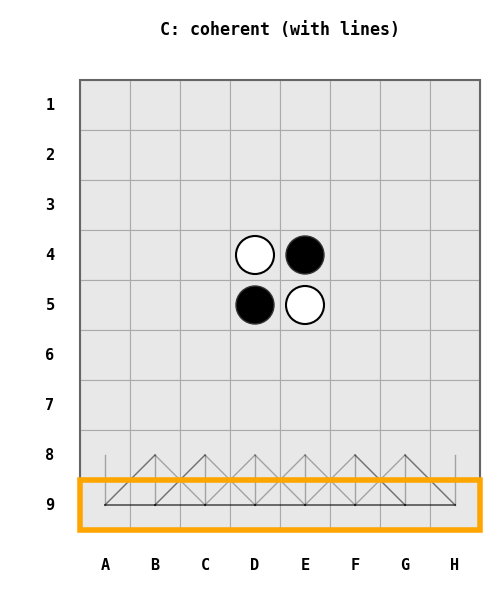

In [67]:
# Audition C - coherent 9th row + along-row flanks + 3 local into-board flanks
fig, ax = _make_fixed_scale_ax((-1.9, 7.7), (-1.9, 9.8)); _board_bg(ax)
for c in range(8):
    _draw_cell(ax, 8, c)
for i in range(7):                      # shared along-row flanks (same colour)
    ax.plot([i, i + 1], [8, 8], color=LINE, alpha=A_ROW, lw=1.4, zorder=4)
for i in range(8):                      # 3 into-board flanks, line to the adjacent (first) cell
    for rule in _pick(_coh_into_board(i), 3):
        a = rule['opponents'][0]
        ax.plot([i, a % 8], [8, a // 8], color=LINE, alpha=A_RAND, lw=1.0, zorder=2)
ax.add_patch(mpatches.Rectangle((-0.5, 7.5), 8, 1, facecolor='none',
             edgecolor=HIGHLIGHT_COLOR, linewidth=OUTLINE_LW, zorder=8))
for c in range(8):
    ax.text(c, 9.2, 'ABCDEFGH'[c], ha='center', va='center', fontsize=LABEL_FS, fontweight='bold')
for r in range(9):
    ax.text(-1.1, r, str(r + 1), ha='center', va='center', fontsize=LABEL_FS, fontweight='bold')
ax.text(3.5, -1.4, 'C: coherent (with lines)', ha='center', fontsize=12, fontweight='bold')
plt.show()


## Section 7 - New-squares transfer: IL learning curves (all-rules)

New-square legal-move probability mass (`IL_prob`) vs **fraction of training** (`step / total_steps`) - the matched-exposure view (Control 1) that controls for the two conditions' different total batch counts.  Same as Panel B of `plot_new_squares_il.py`, in the B&W monospace style.  Data: `experiments/new_squares/gpt_cond_00{2,3}.json`.

In [68]:
# New-squares IL learning curves (fraction-of-training x-axis) - B&W style.
import json
import matplotlib.ticker as mticker
MONO = {'family': 'monospace'}

def _load_il(cid):
    d = json.load(open(os.path.join(REPO_ROOT, f'experiments/new_squares/gpt_cond_{cid:03d}.json')))
    frac = np.array(d['eval_steps'], float) / d['total_steps']   # matched exposure
    return frac, np.array(d['IL_prob'], float), d['condition_name']

COH_F, COH_IL, COH_NAME = _load_il(2)   # coherent_all
INC_F, INC_IL, INC_NAME = _load_il(3)   # incoherent_all
Y_MAX = 0.16

def _style(ax, title):
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
    for s in ('right', 'top'):
        ax.spines[s].set_visible(False)
    ax.set_xlim(0, 1); ax.set_ylim(0, Y_MAX)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{y:.2f}'))
    ax.tick_params(axis='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
    for tk in ax.get_xticklabels() + ax.get_yticklabels():
        tk.set_fontfamily('monospace')
    ax.set_xlabel('amount of training (matched exposure)', fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.set_ylabel('Probability on newly legal squares', fontdict=MONO, fontsize=12, color='black', labelpad=8)

def _single(frac, il, title, out_name):
    fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    ax.plot(frac, il, color='black', linewidth=1.2, marker='s', markersize=3.4,
            markerfacecolor='black', markeredgecolor='black')
    _style(ax, title); plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    print('  saved', out); plt.show()
print(f'coherent_all  final IL={COH_IL[-1]:.4f}   incoherent_all final IL={INC_IL[-1]:.4f}')

coherent_all  final IL=0.1138   incoherent_all final IL=0.1119


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_coherent_all.png


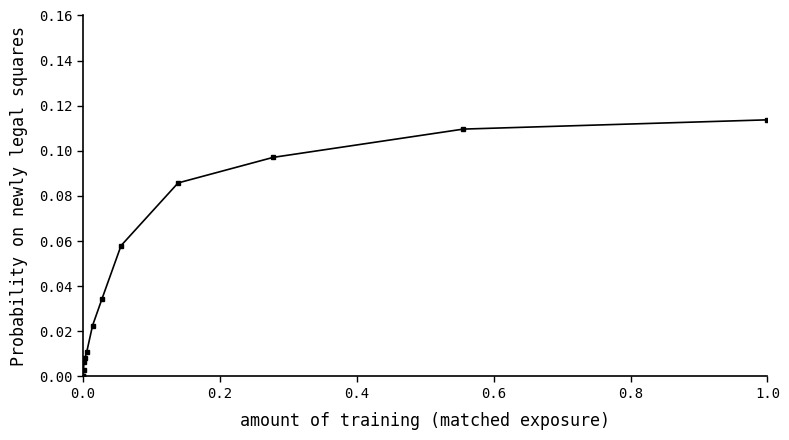

In [69]:
# Coherent (all rules) - IL vs fraction of training.
_single(COH_F, COH_IL, 'Coherent (all rules)', 'nsq_il_coherent_all.png')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_incoherent_all.png


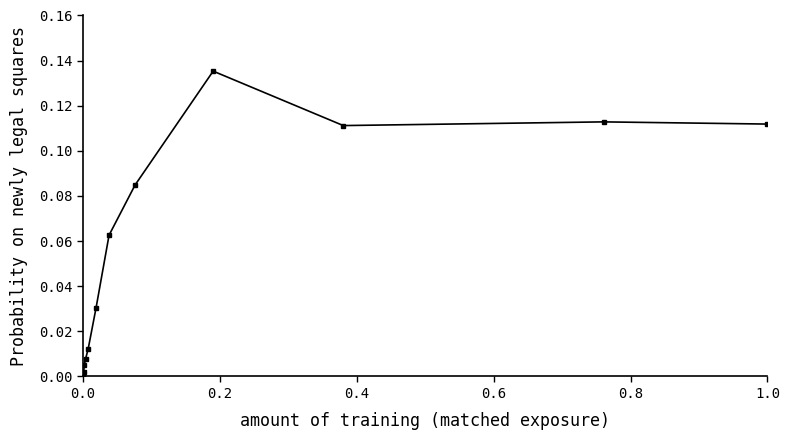

In [70]:
# Incoherent (all rules) - IL vs fraction of training.
_single(INC_F, INC_IL, 'Incoherent (all rules)', 'nsq_il_incoherent_all.png')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_both_all.png


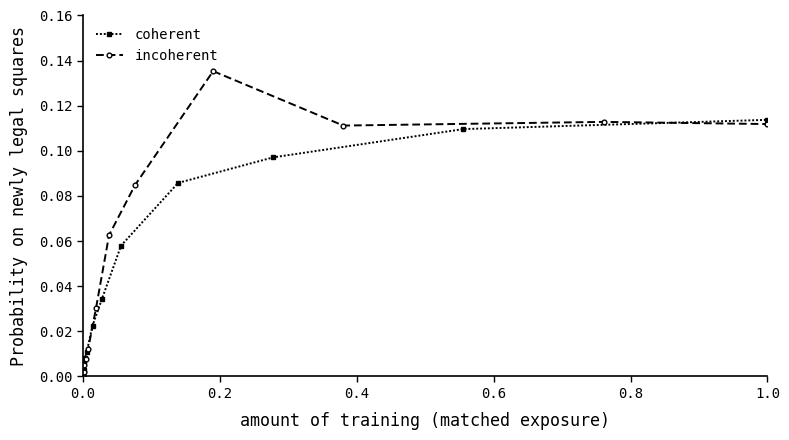

In [71]:
# Both overlaid - two dotted line styles.
fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.plot(COH_F, COH_IL, color='black', linewidth=1.4, linestyle=(0, (1, 1)),
        marker='s', markersize=3.4, markerfacecolor='black', markeredgecolor='black', label='coherent')
ax.plot(INC_F, INC_IL, color='black', linewidth=1.4, linestyle=(0, (4, 2)),
        marker='o', markersize=3.4, markerfacecolor='white', markeredgecolor='black', label='incoherent')
_style(ax, '') #Coherent Geometry vs Incoherent Geometry
ax.legend(loc='upper left', frameon=False, prop=MONO, fontsize=11)
plt.tight_layout()
out = os.path.join(TALK_DIR, 'nsq_il_both_all.png'); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('  saved', out); plt.show()

### Section 7b - Same curves vs raw number of batches (NOT matched for exposure)

IL_prob vs actual training step (`eval_steps`).  The two conditions have different total batch counts (coherent 35994, incoherent 26295), so they end at different x - this is the raw learning-curve view (Panel A of `plot_new_squares_il.py`), not the matched-exposure one above.

In [72]:
# Raw-batch (unmatched) versions - reuse IL data, plot vs eval_steps.
def _load_steps(cid):
    d = json.load(open(os.path.join(REPO_ROOT, f'experiments/new_squares/gpt_cond_{cid:03d}.json')))
    return np.array(d['eval_steps'], float), np.array(d['IL_prob'], float)
COH_S, _ = _load_steps(2)
INC_S, _ = _load_steps(3)
X_MAX_B = float(max(COH_S[-1], INC_S[-1]))

def _style_b(ax, title):
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
    for s in ('right', 'top'):
        ax.spines[s].set_visible(False)
    ax.set_xlim(0, X_MAX_B); ax.set_ylim(0, Y_MAX)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{y:.2f}'))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}k'))
    ax.tick_params(axis='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
    for tk in ax.get_xticklabels() + ax.get_yticklabels():
        tk.set_fontfamily('monospace')
    ax.set_xlabel('number of batches (training step)', fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.set_ylabel('New-square legal prob (IL)', fontdict=MONO, fontsize=12, color='black', labelpad=8)

def _single_b(steps, il, title, out_name):
    fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    ax.plot(steps, il, color='black', linewidth=1.2, marker='s', markersize=3.4,
            markerfacecolor='black', markeredgecolor='black')
    _style_b(ax, title); plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    print('  saved', out); plt.show()
print(f'coherent ends at {int(COH_S[-1])} batches, incoherent ends at {int(INC_S[-1])} batches')

coherent ends at 35994 batches, incoherent ends at 26295 batches


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_coherent_all_batches.png


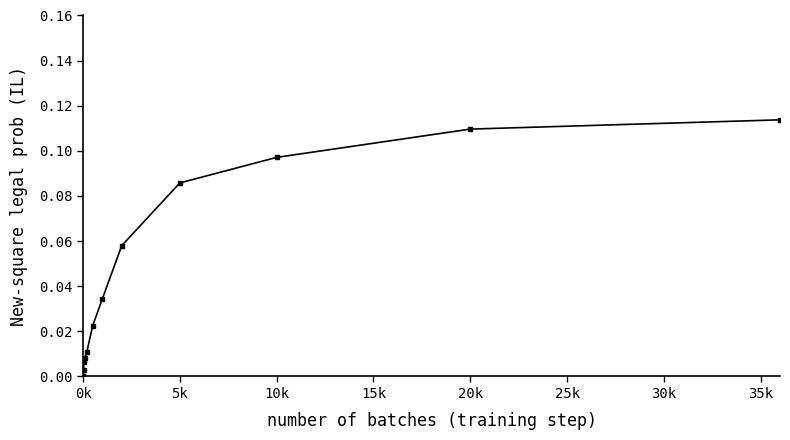

In [73]:
# Coherent (all rules) - IL vs number of batches.
_single_b(COH_S, COH_IL, 'Coherent (all rules) - vs batches', 'nsq_il_coherent_all_batches.png')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_incoherent_all_batches.png


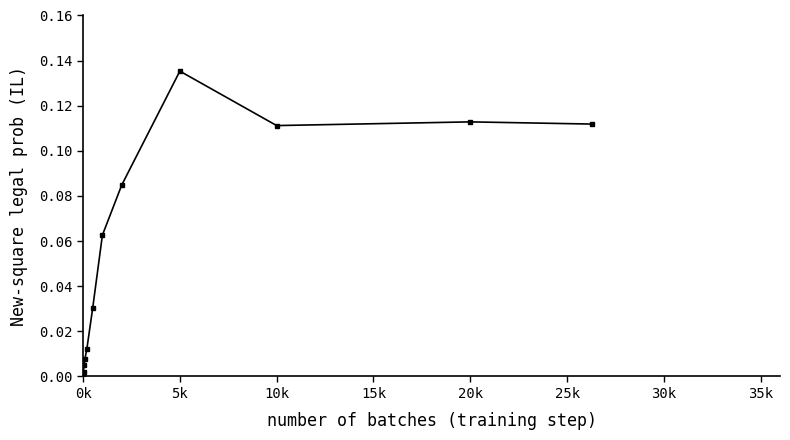

In [74]:
# Incoherent (all rules) - IL vs number of batches.
_single_b(INC_S, INC_IL, 'Incoherent (all rules) - vs batches', 'nsq_il_incoherent_all_batches.png')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_both_all_batches.png


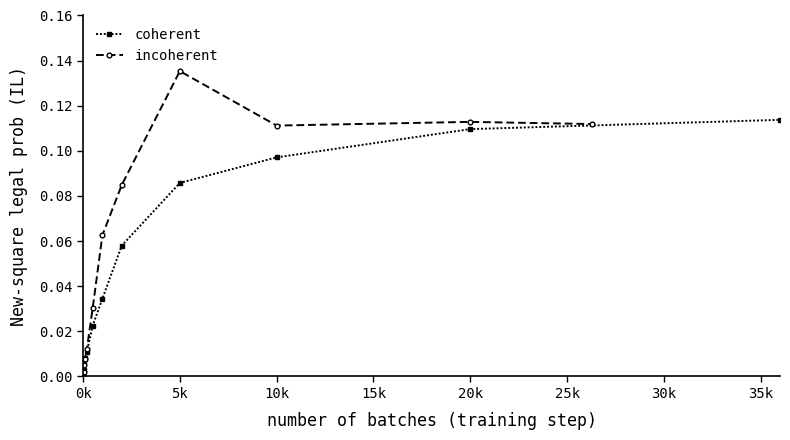

In [75]:
# Both overlaid vs number of batches - two dotted line styles.
fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.plot(COH_S, COH_IL, color='black', linewidth=1.4, linestyle=(0, (1, 1)),
        marker='s', markersize=3.4, markerfacecolor='black', markeredgecolor='black', label='coherent')
ax.plot(INC_S, INC_IL, color='black', linewidth=1.4, linestyle=(0, (4, 2)),
        marker='o', markersize=3.4, markerfacecolor='white', markeredgecolor='black', label='incoherent')
_style_b(ax, 'Coherent vs Incoherent - vs batches')
ax.legend(loc='upper left', frameon=False, prop=MONO, fontsize=11)
plt.tight_layout()
out = os.path.join(TALK_DIR, 'nsq_il_both_all_batches.png'); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('  saved', out); plt.show()

## Section 7c - Othello-MLP (J1B): IL learning curves (all-rules, overlaid)

The J1B analog of Section 7, coherent vs incoherent **overlaid** (two dotted styles).  Two views:
- **Headline (`*_matchexp.png`)** - **matched exposure** on a **0-1 linear** axis, matching the OGPT Section-7 format.  x = fraction of each condition's *own* total rule-firing exposure (like OGPT's `step / total_steps`); x=1 is anchored at the 2000-game convergence budget.  Data: `j1b_cond_00{2,3}_lin.json` (linear-spaced schedule so points spread evenly).
- **Companion (`nsq_il_both_all_mlp.png`)** - **log x** over the full 10..20000-game schedule, showing the fast rise *and* the plateau out to 20k.  Data: `j1b_cond_00{2,3}.json`.

y = **`IL_prob_frac`** = fraction of the model's probability mass on the newly-legal squares (scale-free; J1B's raw prob-OR isn't a probability).  Accuracy versions (`nsq_ilacc_*`) also emitted.

**Result:** both learn fast (rising from ~0.30/~0.52 by a few % of exposure).  Coherent is marginally quicker off the line, then **incoherent overtakes (~0.07-0.10 exposure) and plateaus higher** (mass-fraction 0.835 vs 0.763, +9.5%; top-1 acc 0.917 vs 0.871, +5.2%).  The crossover survives putting exposure on the x-axis, so it is not an exposure artifact.  The higher incoherent ceiling traces to **rule decorrelation**, not capture-noise: coherent's flanks are nested lines sharing ~6x more cells (mean pairwise Jaccard 0.267 vs 0.042), so a single capture-flipped cell corrupts several rules at once, while incoherent's disjoint-cell flanks fail independently and error-average in the prob-OR.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_both_all_mlp_matchexp.png


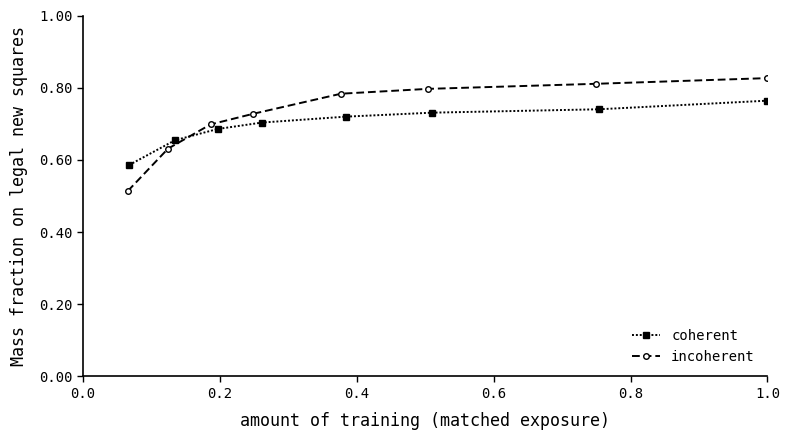

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_ilacc_both_all_mlp_matchexp.png


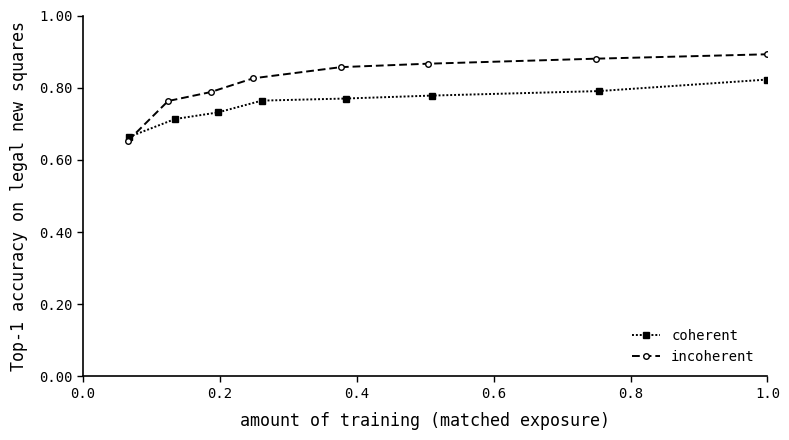

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_il_both_all_mlp.png


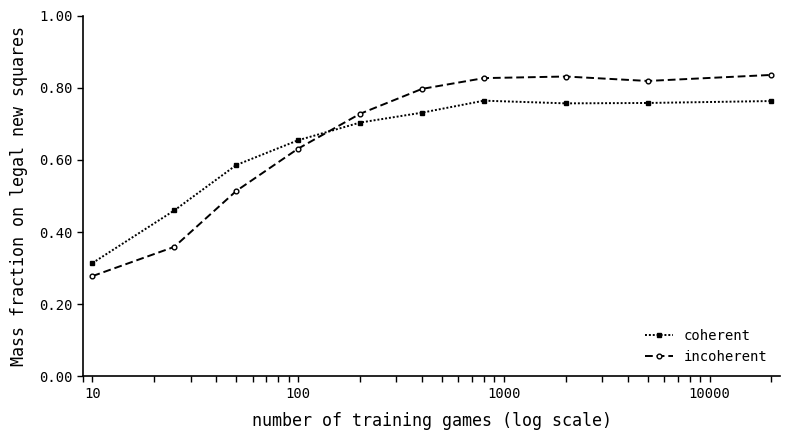

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/nsq_ilacc_both_all_mlp.png


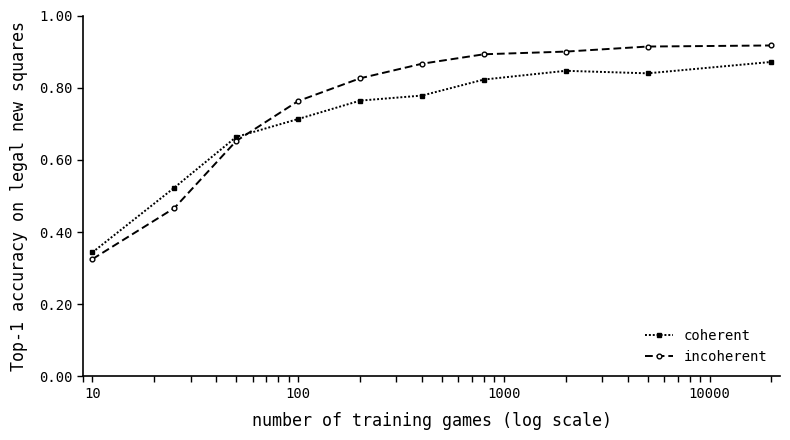

In [119]:
# J1B (Othello-MLP): coherent vs incoherent, overlaid - two dotted styles.
# Headline: MATCHED EXPOSURE on a 0-1 linear axis (x = fraction of each condition's
#   own total rule-firing exposure), matching the OGPT Section-7 format.
# Companion: LOG x over the full 10..20000-game schedule (shows the plateau to 20k).
import json as _json
import matplotlib.ticker as _mtick

ANCHOR_GAMES = 800   # x=1 anchored near convergence so the axis shows the rise, not the plateau
def _load_lin(cid, key):
    d = _json.load(open(os.path.join(REPO_ROOT, f'experiments/new_squares/j1b_cond_{cid:03d}_lin.json')))
    x = np.array(d['matched_exposure_x'], float)                 # per-condition own exposure (scaled)
    g = d['matched_exposure_games']
    D = d['n_train_games']
    y = np.array([d[key][D.index(s)] for s in g], float)
    x = x / x[g.index(ANCHOR_GAMES)]                             # re-anchor x=1 at ANCHOR_GAMES
    m = x <= 1.0 + 1e-9                                          # keep the rise (drop the flat tail)
    return x[m], y[m]

def _load_geom(cid, key):
    d = _json.load(open(os.path.join(REPO_ROOT, f'experiments/new_squares/j1b_cond_{cid:03d}.json')))
    return np.array(d['n_train_games'], float), np.array(d[key], float)

def _matchexp(key, ylabel, out_name):
    cx, cy = _load_lin(2, key); nx, ny = _load_lin(3, key)
    fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    ax.plot(cx, cy, color='black', linewidth=1.4, linestyle=(0, (1, 1)),
            marker='s', markersize=4.0, markerfacecolor='black', markeredgecolor='black', label='coherent')
    ax.plot(nx, ny, color='black', linewidth=1.4, linestyle=(0, (4, 2)),
            marker='o', markersize=4.0, markerfacecolor='white', markeredgecolor='black', label='incoherent')
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
    for s in ('right', 'top'):
        ax.spines[s].set_visible(False)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.0); ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.xaxis.set_major_formatter(_mtick.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.tick_params(axis='both', which='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
    for tk in ax.get_xticklabels() + ax.get_yticklabels():
        tk.set_fontfamily('monospace')
    ax.set_xlabel('amount of training (matched exposure)', fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.set_ylabel(ylabel, fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.legend(loc='lower right', frameon=False, prop=MONO, fontsize=11)
    plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    print('  saved', out); plt.show()

def _logfull(key, ylabel, out_name):
    cx, cy = _load_geom(2, key); nx, ny = _load_geom(3, key)
    fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    ax.plot(cx, cy, color='black', linewidth=1.4, linestyle=(0, (1, 1)),
            marker='s', markersize=3.4, markerfacecolor='black', markeredgecolor='black', label='coherent')
    ax.plot(nx, ny, color='black', linewidth=1.4, linestyle=(0, (4, 2)),
            marker='o', markersize=3.4, markerfacecolor='white', markeredgecolor='black', label='incoherent')
    ax.set_xscale('log')
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
    for s in ('right', 'top'):
        ax.spines[s].set_visible(False)
    ax.set_xlim(9, 22000); ax.set_ylim(0, 1.0); ax.set_xticks([10, 100, 1000, 10000])
    ax.xaxis.set_major_formatter(_mtick.FuncFormatter(lambda x, _: f'{int(x)}'))
    ax.xaxis.set_minor_formatter(_mtick.NullFormatter())
    ax.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.tick_params(axis='both', which='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
    for tk in ax.get_xticklabels() + ax.get_yticklabels():
        tk.set_fontfamily('monospace')
    ax.set_xlabel('number of training games (log scale)', fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.set_ylabel(ylabel, fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.legend(loc='lower right', frameon=False, prop=MONO, fontsize=11)
    plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    print('  saved', out); plt.show()

# HEADLINE - matched-exposure, 0-1 linear (OGPT-format).
_matchexp('IL_prob_frac', 'Mass fraction on legal new squares', 'nsq_il_both_all_mlp_matchexp.png')
_matchexp('IL_acc',       'Top-1 accuracy on legal new squares', 'nsq_ilacc_both_all_mlp_matchexp.png')
# COMPANION - log x, full schedule (shows the plateau out to 20k).
_logfull('IL_prob_frac', 'Mass fraction on legal new squares', 'nsq_il_both_all_mlp.png')
_logfull('IL_acc',       'Top-1 accuracy on legal new squares', 'nsq_ilacc_both_all_mlp.png')

## Section 8 - By-move top-1 legality: OGPT vs random-OGPT vs J1B

At each position, rank the 64 cells by the model's legality score, take the top-1 cell, and check whether it is actually legal.  Binned by move.  OGPT and random-OGPT span moves 1-59; J1B spans 6-59 (chunk positions start mid-game).  The headline **overall** is computed over the shared 6-59 range so the three are directly comparable; each model's native-range overall is also printed.  (J3B skipped.)

In [76]:
DATA_DIR = os.path.join(REPO_ROOT, 'notebooks/talk_data')  # npz inputs
# By-move top-1 legality comparison (B&W monospace).
_BM = {m: np.load(os.path.join(DATA_DIR, f'{m}_top1_by_move.npz'), allow_pickle=True)
       for m in ['ogpt', 'ogpt_random', 'j1b']}
SHARED_LO = max(int(np.where(d['n_by_move'] > 0)[0].min()) for d in _BM.values())  # 6
SHARED_HI = min(int(np.where(d['n_by_move'] > 0)[0].max()) for d in _BM.values())  # 59
def _matched_overall(d):
    n = d['n_by_move'][SHARED_LO:SHARED_HI+1]
    top = np.nan_to_num(d['top1_by_move'][SHARED_LO:SHARED_HI+1]) * n
    return top.sum() / max(n.sum(), 1)
print(f'shared move range: {SHARED_LO}-{SHARED_HI}')
for m, d in _BM.items():
    print(f"  {m:12s} native={float(d['overall'])*100:6.3f}%   matched({SHARED_LO}-{SHARED_HI})={_matched_overall(d)*100:6.3f}%")

shared move range: 6-59
  ogpt         native=99.827%   matched(6-59)=99.811%
  ogpt_random  native=13.528%   matched(6-59)=14.407%
  j1b          native=98.267%   matched(6-59)=98.267%


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/bymove_top1_legality.png


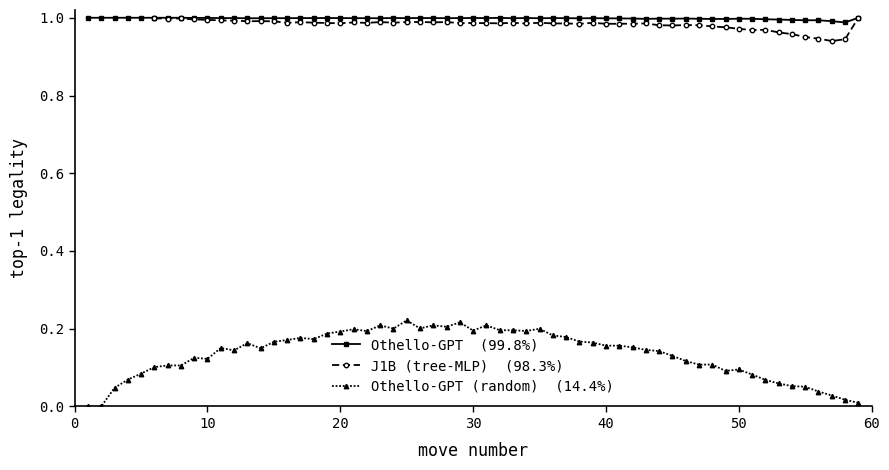

In [118]:
# Figure: per-move top-1 legality, three models.
_SPEC = [('ogpt',        'Othello-GPT',        'solid',        's', 'black', 'black'),
         ('j1b',         'J1B (tree-MLP)',     (0, (4, 2)),    'o', 'white', 'black'),
         ('ogpt_random', 'Othello-GPT (random)', (0, (1, 1)),  '^', 'black', 'black')]
fig, ax = plt.subplots(figsize=(9.0, 4.8)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
for key, lab, ls, mk, mfc, mec in _SPEC:
    d = _BM[key]; x = d['turns']; y = d['top1_by_move']
    ov = _matched_overall(d) * 100
    ax.plot(x, y, color='black', linewidth=1.3, linestyle=ls, marker=mk, markersize=3.2,
            markerfacecolor=mfc, markeredgecolor=mec, label=f'{lab}  ({ov:.1f}%)')
for s in ('left', 'bottom'):
    ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
for s in ('right', 'top'):
    ax.spines[s].set_visible(False)
ax.set_xlim(0, 60); ax.set_ylim(0, 1.02)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f'{y:.1f}'))
ax.tick_params(axis='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
for tk in ax.get_xticklabels() + ax.get_yticklabels():
    tk.set_fontfamily('monospace')
ax.set_xlabel('move number', fontdict=MONO, fontsize=12, color='black', labelpad=8)
ax.set_ylabel('top-1 legality', fontdict=MONO, fontsize=12, color='black', labelpad=8)
ax.legend(loc='lower center', frameon=False, prop=MONO, fontsize=10, ncol=1)
plt.tight_layout()
out = os.path.join(TALK_DIR, 'bymove_top1_legality.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white'); print('  saved', out); plt.show()

## Section 9 - Top-1 illegal move prediction by square (heatmap)

8x8 board heatmap of **top-1 illegal move prediction**, in the **same `render_board` grayscale style as the J3 ordinal tree-MLP figure** (Section 4c): higher illegal rate = darker fill, exact value labelled in each cell.

Metric: at each position take the model's single top-1 predicted cell (over the 60 movable cells); if it is illegal, tally that square.  Both models use the **same metric on synthetic games**.  Plotted quantity is set by `METRIC` (`'rate'` = % of positions, N-independent; or `'count'`).

**Each model has its OWN scale** (`J1B_VMIN/J1B_VMAX`, `OGPT_VMIN/OGPT_VMAX`) so you can tune them independently - OGPT's illegal rate is ~10x smaller than J1B's, so it needs a tighter band to show structure.  Data: `notebooks/talk_data/{j1b,ogpt}_illegal_by_square.npz`.

In [78]:
# ===================== knobs (edit these) =====================
METRIC = 'rate'          # 'rate' (% of positions) or 'count' (raw # illegal top-1)
# --- separate grayscale band per model (darker = more illegal) ---
# rate mode is in PERCENT; count mode is raw counts.  Suggested values printed below.
N_SHADES = 6            # discrete grayscale shades (white->black, inclusive)
J1B_VMIN,  J1B_VMAX  = 0.02, 0.0485   # Othello-MLP (J1B)  [max color-agreement, 100k]
OGPT_VMIN, OGPT_VMAX = 0.000, 0.0086  # Othello-GPT        [max color-agreement]
# =============================================================

DATA_DIR = os.path.join(REPO_ROOT, 'notebooks/talk_data')   # npz inputs

def _load_sq(model):
    d = np.load(os.path.join(DATA_DIR, f'{model}_illegal_by_square.npz'), allow_pickle=True)
    data = d['sq_illegal_rate']*100 if METRIC == 'rate' else d['sq_illegal_count'].astype(float)
    return data, int(d['n_total'])

def _fmt(v):
    return f'{v:.3f}' if METRIC == 'rate' else (f'{int(v):,}' if v >= 1000 else f'{int(v)}')

def draw_illegal_square(model, title, vmin, vmax, out_name):
    data, n = _load_sq(model)
    # grayscale band, quantized into N_SHADES discrete levels (higher illegal -> darker).
    norm = np.clip((data - vmin) / max(vmax - vmin, 1e-12), 0.0, 1.0)
    level = np.clip((norm * N_SHADES).astype(int), 0, N_SHADES - 1)   # 0..N_SHADES-1
    shade = level / (N_SHADES - 1)                                    # -> {0, .., 1}
    heatmap = {(r, c): float(shade[r, c]) for r in range(8) for c in range(8)}
    CENTER = {(3, 3), (3, 4), (4, 3), (4, 4)}   # starting squares: moves impossible
    highlights = {(r, c): {'label': _fmt(data[r, c])}
                  for r in range(8) for c in range(8) if (r, c) not in CENTER}
    state = np.zeros((8, 8), dtype=np.int8)
    state[3, 3] = -1; state[3, 4] = 1; state[4, 3] = 1; state[4, 4] = -1  # start pieces
    fig, ax = plt.subplots(figsize=(5, 5)); fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights, heatmap=heatmap,
               title=None, show_coords=True, fontsize=11)
    out = os.path.join(TALK_DIR, out_name)
    plt.savefig(out, dpi=200, facecolor='white')
    print(f'  saved {out}'); plt.show()

# report each map's own min/max so you can set the bands above
_unit = '%' if METRIC == 'rate' else ' counts'
for _m in ('j1b', 'ogpt'):
    _d, _n = _load_sq(_m); _nz = _d[_d > 0]
    print(f'{_m.upper():5s} N={_n:,}  overall={_d.sum():.4f}{_unit}  '
          f'per-square max={_nz.max():.4f}{_unit}  (suggested VMAX)')

J1B   N=4,961,233  overall=1.6552%  per-square max=0.0496%  (suggested VMAX)
OGPT  N=5,845,189  overall=0.2244%  per-square max=0.0116%  (suggested VMAX)


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j1b_illegal_by_square.png


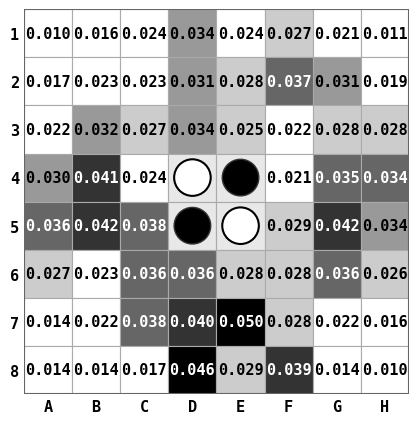

In [79]:
# J1B (Othello-MLP) - J3-style grayscale, its OWN scale.
draw_illegal_square('j1b', 'Top-1 illegal per square - Othello-MLP (J1B)',
                    J1B_VMIN, J1B_VMAX, 'j1b_illegal_by_square.png')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/ogpt_illegal_by_square.png


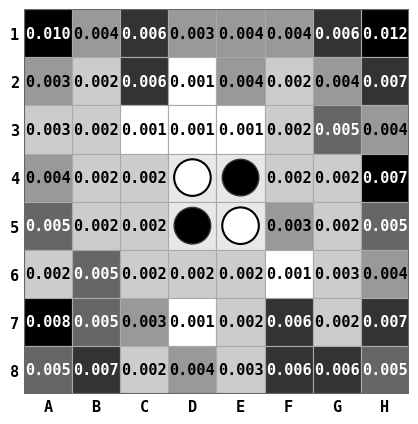

In [80]:
# Othello-GPT - same metric & style, its OWN scale.
draw_illegal_square('ogpt', 'Top-1 illegal per square - Othello-GPT',
                    OGPT_VMIN, OGPT_VMAX, 'ogpt_illegal_by_square.png')

## Section 10 - Top-1 illegal move prediction by MOVE (when the mistakes occur)

Temporal counterpart to the Section 9 spatial heatmaps: **top-1 illegal rate = 1 - top-1 legality** at each move number, for Othello-MLP (J1B) and Othello-GPT.  Shows *when* in the game each model's top-1 pick tends to be illegal.  Data: `notebooks/talk_data/{j1b,ogpt}_top1_by_move.npz`.

Like Section 9, **each model has its own y-scale** (`J1B_YMAX`/`OGPT_YMAX`, `None` = auto per-model max) since J1B's error rate is ~10x OGPT's.  The final panel overlays both **normalized to their own peak**, so you can compare the *shape* of the pattern regardless of magnitude.  B&W monospace style.

In [81]:
# ===================== knobs =====================
J1B_YMAX  = None     # e.g. 6.5 ; None = auto (per-model max)
OGPT_YMAX = None     # e.g. 1.4 ; None = auto
# =================================================
DATA_DIR = os.path.join(REPO_ROOT, 'notebooks/talk_data')

def _illegal_by_move(model):
    d = np.load(os.path.join(DATA_DIR, f'{model}_top1_by_move.npz'), allow_pickle=True)
    t = d['top1_by_move']; n = d['n_by_move']
    ill = np.where(n > 0, (1.0 - np.nan_to_num(t)) * 100.0, np.nan)   # % illegal
    # Drop the final move: it's the forced last move (0 illegal), an artifactual
    # dip to zero -- stop the line one move earlier.
    valid = np.where(n > 0)[0]
    if len(valid):
        ill[valid.max()] = np.nan
    return d['turns'], ill

J1B_X, J1B_ILL = _illegal_by_move('j1b')
OG_X,  OG_ILL  = _illegal_by_move('ogpt')

def _style_m(ax, title, ymax):
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
    for s in ('right', 'top'):
        ax.spines[s].set_visible(False)
    ax.set_xlim(0, 60); ax.set_ylim(0, ymax)
    ax.tick_params(axis='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
    for tk in ax.get_xticklabels() + ax.get_yticklabels():
        tk.set_fontfamily('monospace')
    ax.set_xlabel('move number', fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.set_ylabel('top-1 illegal rate (%)', fontdict=MONO, fontsize=12, color='black', labelpad=8)

def _single_m(x, ill, title, ymax, out_name):
    ymax = float(np.nanmax(ill)) * 1.1 if ymax is None else ymax
    fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    ax.plot(x, ill, color='black', linewidth=1.2, marker='s', markersize=3.4,
            markerfacecolor='black', markeredgecolor='black')
    _style_m(ax, title, ymax); plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    print('  saved', out); plt.show()
print(f'J1B  peak illegal {np.nanmax(J1B_ILL):.3f}%  |  OGPT peak {np.nanmax(OG_ILL):.3f}%')

J1B  peak illegal 5.981%  |  OGPT peak 1.200%


  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/j1b_illegal_by_move.png


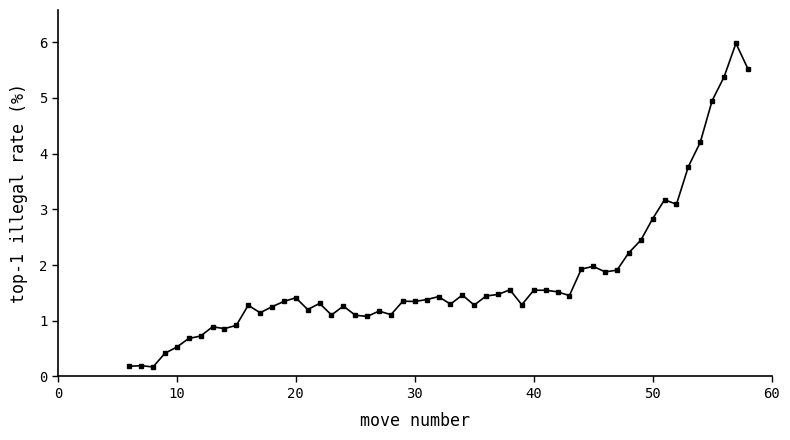

In [82]:
# J1B (Othello-MLP) - illegal rate by move, own scale.
_single_m(J1B_X, J1B_ILL, 'Top-1 illegal by move - Othello-MLP (J1B)', J1B_YMAX,
          'j1b_illegal_by_move.png')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/ogpt_illegal_by_move.png


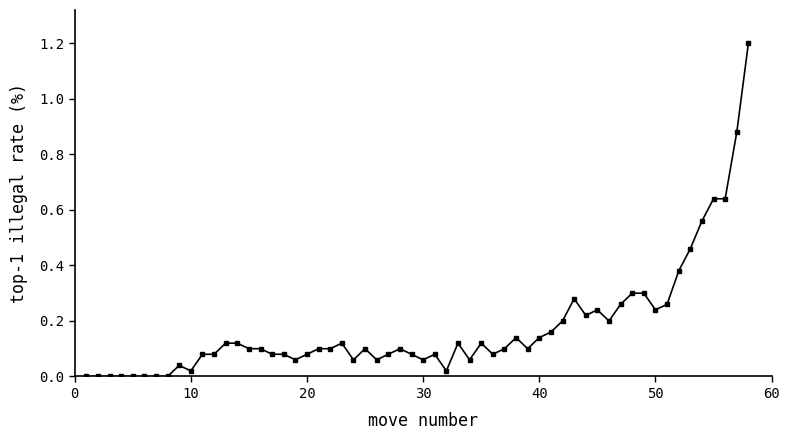

In [83]:
# Othello-GPT - illegal rate by move, own scale.
_single_m(OG_X, OG_ILL, 'Top-1 illegal by move - Othello-GPT', OGPT_YMAX,
          'ogpt_illegal_by_move.png')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/illegal_by_move_shape.png


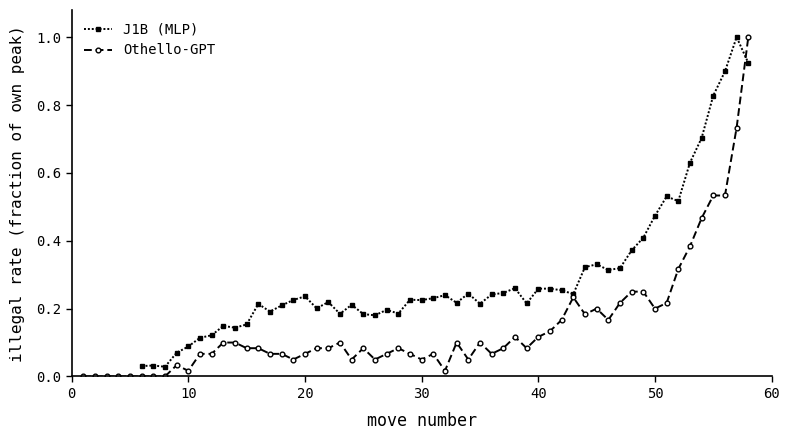

In [84]:
# Shape comparison - each normalized to its own peak (pattern, not magnitude).
fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.plot(J1B_X, J1B_ILL/np.nanmax(J1B_ILL), color='black', linewidth=1.4, linestyle=(0, (1, 1)),
        marker='s', markersize=3.4, markerfacecolor='black', markeredgecolor='black', label='J1B (MLP)')
ax.plot(OG_X, OG_ILL/np.nanmax(OG_ILL), color='black', linewidth=1.4, linestyle=(0, (4, 2)),
        marker='o', markersize=3.4, markerfacecolor='white', markeredgecolor='black', label='Othello-GPT')
for s in ('left', 'bottom'):
    ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
for s in ('right', 'top'):
    ax.spines[s].set_visible(False)
ax.set_xlim(0, 60); ax.set_ylim(0, 1.08)
ax.tick_params(axis='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
for tk in ax.get_xticklabels() + ax.get_yticklabels():
    tk.set_fontfamily('monospace')
ax.set_xlabel('move number', fontdict=MONO, fontsize=12, color='black', labelpad=8)
ax.set_ylabel('illegal rate (fraction of own peak)', fontdict=MONO, fontsize=11.5, color='black', labelpad=8)
ax.legend(loc='upper left', frameon=False, prop=MONO, fontsize=11)
plt.tight_layout()
out = os.path.join(TALK_DIR, 'illegal_by_move_shape.png'); plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('  saved', out); plt.show()

## Pie chart - 25% black / 75% white

Simple two-slice pie, B&W style, no text.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/pie_25_75.png


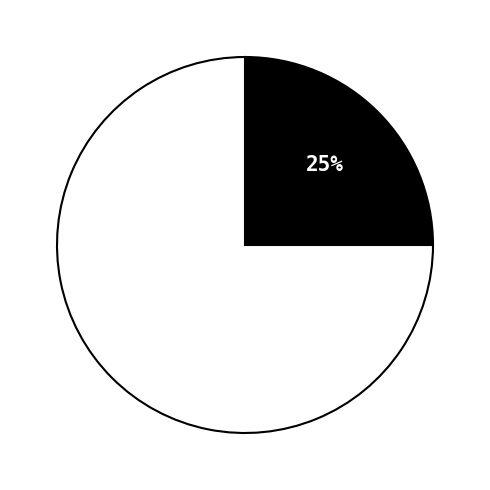

In [85]:
# 25/75 pie - black + white; '25%' in white centered in the black wedge.
fig, ax = plt.subplots(figsize=(5, 5)); fig.patch.set_facecolor('white')
wedges, _ = ax.pie([25, 75], colors=['black', 'white'], startangle=90,
                   counterclock=False,
                   wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
w = wedges[0]                                   # the black slice
ang = np.deg2rad((w.theta1 + w.theta2) / 2.0)
ax.text(0.6 * np.cos(ang), 0.6 * np.sin(ang), '25%', ha='center', va='center',
        color='white', fontsize=15, fontweight='bold', family='monospace')
ax.set_aspect('equal'); plt.tight_layout()
out = os.path.join(TALK_DIR, 'pie_25_75.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('  saved', out); plt.show()

### Section 11a - Order-blind decoder ceiling by move number

Best per-cell board-state accuracy any decoder can reach from an order-blind moveset (`mean_max_decoder_acc`), vs move number.  Robust to sample size (unlike the raw board counts).  Data: `notebooks/talk_data/consist_boards_by_k.csv`.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/consist_decoder_ceiling_by_move.png


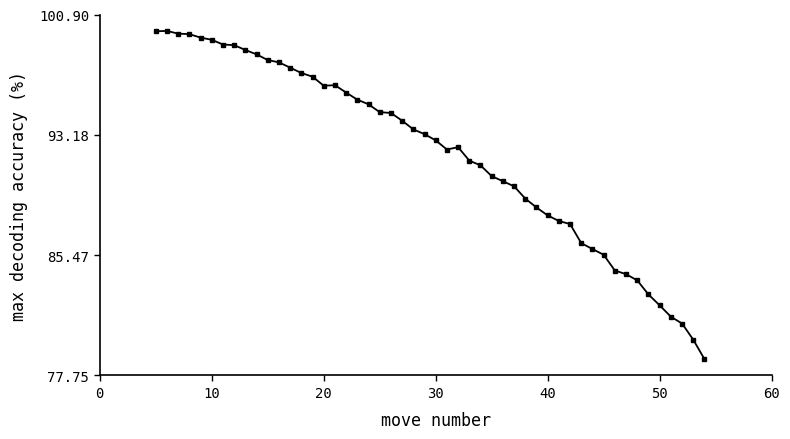

In [86]:
# Order-blind decoder ceiling vs move number - B&W monospace.
import csv as _csv2
import matplotlib.ticker as _mtick
MONO = {'family': 'monospace'}
_dc = [r for r in _csv2.DictReader(open(os.path.join(REPO_ROOT, 'notebooks/talk_data/consist_boards_by_k.csv')))
       if r['k'] != 'overall']
_k = np.array([int(r['k']) for r in _dc]); _oo = np.argsort(_k); _k = _k[_oo]
_acc = np.array([float(r['mean_max_decoder_acc']) for r in _dc])[_oo] * 100

fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.plot(_k, _acc, color='black', linewidth=1.3, marker='s', markersize=3.4,
        markerfacecolor='black', markeredgecolor='black')
for s in ('left', 'bottom'):
    ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
for s in ('right', 'top'):
    ax.spines[s].set_visible(False)
ax.set_xlim(0, 60)
ax.yaxis.set_major_locator(_mtick.LinearLocator(4))
ax.tick_params(axis='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontfamily('monospace')
ax.set_xlabel('move number', fontdict=MONO, fontsize=12, color='black', labelpad=8)
ax.set_ylabel('max decoding accuracy (%)', fontdict=MONO, fontsize=12, color='black', labelpad=8)
plt.tight_layout()
out = os.path.join(TALK_DIR, 'consist_decoder_ceiling_by_move.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white'); print('  saved', out); plt.show()

## Section 11 - Board states compatible with a moveset, by move number

For an order-blind moveset, how many distinct board states are consistent with it (the ambiguity an order-blind predictor faces).  Mean and max distinct boards per moveset vs move number.  Data: `notebooks/talk_data/consist_boards_by_k.csv` from `analyze_late_ambiguity.py`.  Set `LOG_Y = True` if the max dwarfs the mean.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/consist_boards_mean_by_move.png


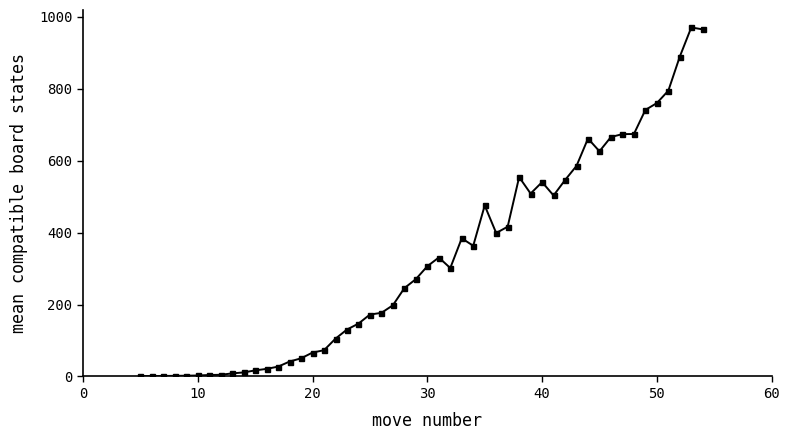

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/consist_boards_max_by_move.png


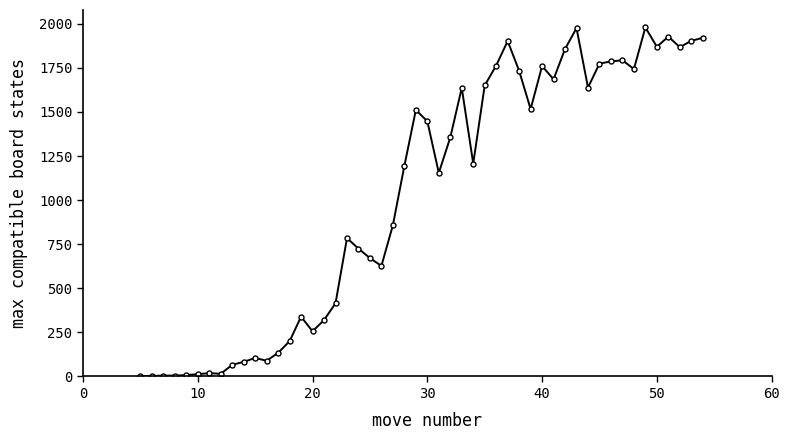

In [87]:
# Compatible board states per moveset vs move number - SEPARATE mean and max plots (B&W monospace).
import csv as _csv
MONO = {'family': 'monospace'}
CB_CSV = os.path.join(REPO_ROOT, 'notebooks/talk_data/consist_boards_by_k.csv')
_rows = [r for r in _csv.DictReader(open(CB_CSV)) if r['k'] != 'overall']
_k = np.array([int(r['k']) for r in _rows])
_mean = np.array([float(r['mean_distinct']) for r in _rows])
_max = np.array([float(r['max_distinct']) for r in _rows])
_o = np.argsort(_k); _k, _mean, _max = _k[_o], _mean[_o], _max[_o]

def _cb_plot(y, ylab, title, out_name, marker='s', mfc='black'):
    fig, ax = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    ax.plot(_k, y, color='black', linewidth=1.4, marker=marker, markersize=3.6,
            markerfacecolor=mfc, markeredgecolor='black')
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
    for s in ('right', 'top'):
        ax.spines[s].set_visible(False)
    ax.set_ylim(bottom=0); ax.set_xlim(0, 60)
    ax.tick_params(axis='both', direction='out', length=4, width=1.0, colors='black', labelsize=10)
    for tk in ax.get_xticklabels() + ax.get_yticklabels():
        tk.set_fontfamily('monospace')
    ax.set_xlabel('move number', fontdict=MONO, fontsize=12, color='black', labelpad=8)
    ax.set_ylabel(ylab, fontdict=MONO, fontsize=12, color='black', labelpad=8)
    plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name)
    plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white'); print('  saved', out); plt.show()

_cb_plot(_mean, 'mean compatible board states', 'Compatible boards per moveset (mean)',
         'consist_boards_mean_by_move.png', marker='s', mfc='black')
_cb_plot(_max, 'max compatible board states', 'Compatible boards per moveset (max)',
         'consist_boards_max_by_move.png', marker='o', mfc='white')

### Section 11b - all compatible boards for one moveset

Pick a moveset at a given move number and render **every** consistent board it maps to (same board style as the rest of the notebook), one image each - to show how diverse the board states are for a single order-blind moveset.  `ROW` selects the moveset (the `moveset_idx` / row in `consist_boards_per_moveset.csv`); change it to explore others.

Boards come from `consist_board_examples.pkl`, which stores the most-diverse movesets per move (bump `--n-examples` when running to browse more rows; `--max-example-boards` caps how many boards are saved per moveset).

row 30 not among saved movesets for move 8; available rows: [1, 26, 65]
move 8  moveset row 65: 5 distinct boards (showing 5), max_decoder_acc=0.9858
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/compat_m8_row65_b0.png


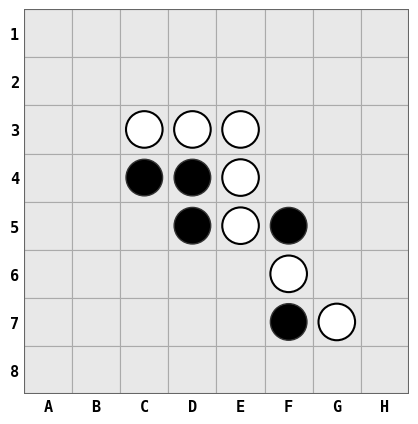

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/compat_m8_row65_b1.png


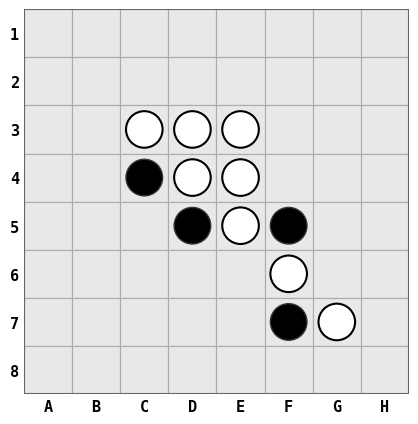

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/compat_m8_row65_b2.png


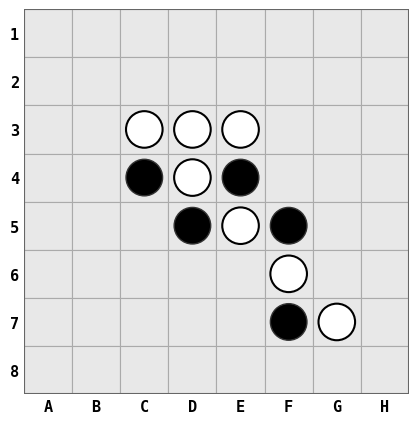

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/compat_m8_row65_b3.png


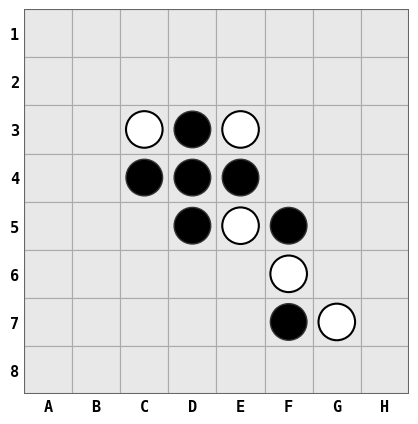

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/compat_m8_row65_b4.png


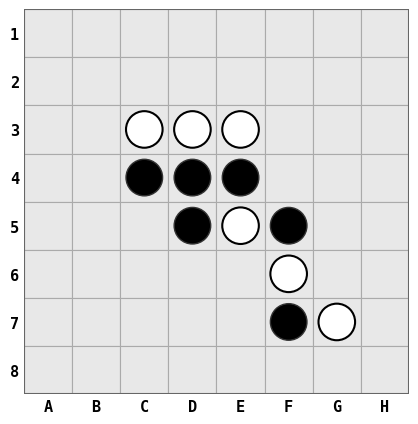

In [88]:
# All compatible boards for one moveset, as separate images.
import pickle as _pkl
MOVE_NUMBER = 8       # move number (must be in the examples pkl)
ROW = 30              # moveset row = 'moveset_idx' in the per-moveset CSV; explore others
CB_EXAMPLES = os.path.join(REPO_ROOT, 'notebooks/talk_data/consist_board_examples.pkl')

_ex = _pkl.load(open(CB_EXAMPLES, 'rb'))
_lst = _ex[MOVE_NUMBER]
_by_idx = {e['moveset_idx']: e for e in _lst if 'moveset_idx' in e}
if _by_idx:
    if ROW in _by_idx:
        _e = _by_idx[ROW]
    else:
        print(f'row {ROW} not among saved movesets for move {MOVE_NUMBER}; '
              f'available rows: {sorted(_by_idx)}')
        _e = _lst[0]
else:                                    # older pkl w/o moveset_idx -> ROW = list index
    _e = _lst[ROW % len(_lst)]

_boards = _e['boards']
_counts = _e.get('board_counts', [None] * len(_boards))
print(f"move {MOVE_NUMBER}  moveset row {_e.get('moveset_idx', '?')}: "
      f"{_e['n_distinct']} distinct boards (showing {len(_boards)}), "
      f"max_decoder_acc={_e['max_decoder_acc']:.4f}")

for _i, (_b, _cnt) in enumerate(zip(_boards, _counts)):
    _ttl = f'move {MOVE_NUMBER}  board {_i + 1}/{len(_boards)}'
    if _cnt is not None:
        _ttl += f'  (freq {_cnt})'
    render_board(np.asarray(_b, dtype=np.int8), highlight_cells=[],
                 out_name=f"compat_m{MOVE_NUMBER}_row{_e.get('moveset_idx', 'x')}_b{_i}.png",
                 title=_ttl)

### Section 11c - Two maximally-different boards from one moveset

A single moveset and the **two** consistent boards that differ the most, rendered as **two separate figures** (plain, no annotations).  `PAIR_MOVE` sets the move number.

move 30 row 0: 1447 distinct boards; the two shown differ in 16/64 cells
  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/consist_two_boards_A.png


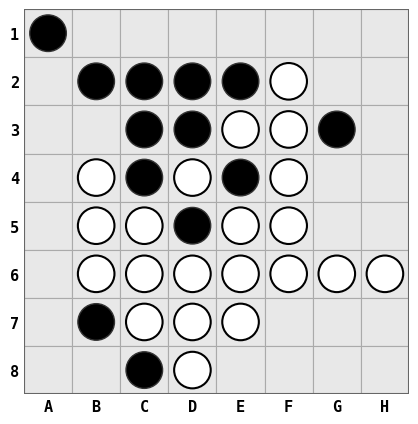

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/consist_two_boards_B.png


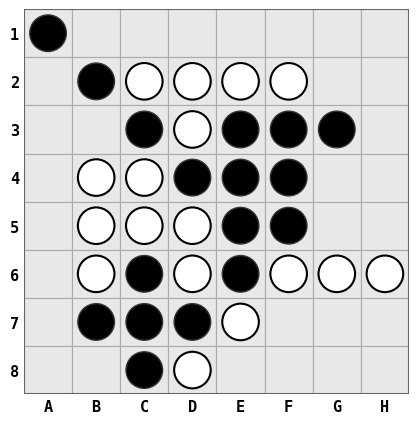

In [89]:
# Two maximally-different consistent boards from one moveset - as TWO separate figures, no titles.
import pickle as _pkl2b, itertools as _it
PAIR_MOVE = 30      # move number to draw the moveset from
_ex2 = _pkl2b.load(open(os.path.join(REPO_ROOT, 'notebooks/talk_data/consist_board_examples.pkl'), 'rb'))
_best = None
for _e in _ex2[PAIR_MOVE]:
    _B = [np.asarray(b, np.int8) for b in _e['boards']]
    for _i, _j in _it.combinations(range(len(_B)), 2):
        _h = int((_B[_i].ravel() != _B[_j].ravel()).sum())
        if _best is None or _h > _best[0]:
            _best = (_h, _e.get('moveset_idx'), _B[_i], _B[_j], _e['n_distinct'])
_h, _row, _ba, _bb, _nd = _best
_diff = (_ba != _bb)
print(f'move {PAIR_MOVE} row {_row}: {_nd} distinct boards; the two shown differ in {_h}/64 cells')
for _bd, _fname in [(_ba, 'consist_two_boards_A.png'), (_bb, 'consist_two_boards_B.png')]:
    fig, ax = plt.subplots(figsize=(5, 5)); fig.patch.set_facecolor('white')
    draw_board(ax, _bd, highlights={}, show_coords=True, fontsize=8)
    _out = os.path.join(TALK_DIR, _fname)
    plt.savefig(_out, dpi=200, facecolor='white')
    print('  saved', _out); plt.show()

## Patterns of error

How a forfeit desyncs the model's turn-parity and causes a **delayed** illegal prediction (game 56383).  **55** White - model spreads over its legal moves.  **Forfeit** - it's Black's turn but every open square is illegal for Black (all red) -> Black must pass.  **56** White plays instead - model still fine.  **57** Black - fine (but already leaking prob onto an illegal square).  **58** White - still parity-confused, the model puts **99.4% on an illegal square** (A2).  Green = legal, red = illegal; illegal squares under 2% left blank; the forfeit board has no probabilities (the model makes no legal prediction there).  Data: `forfeit_example_game.pkl` (+ `forfeit_sequence_probs.pkl`).

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/forfeit_seq_m55.png


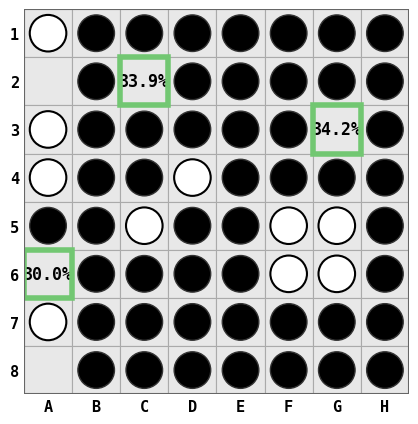

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/forfeit_seq_forfeit.png


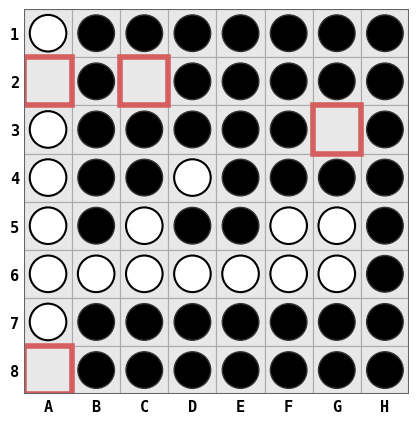

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/forfeit_seq_m56.png


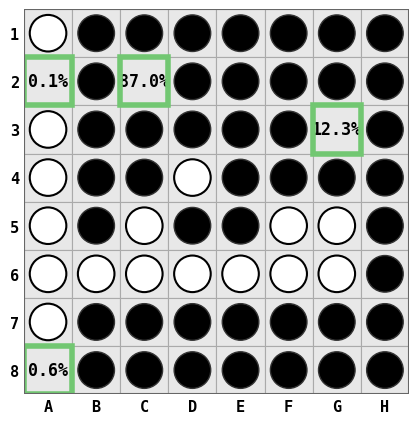

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/forfeit_seq_m57.png


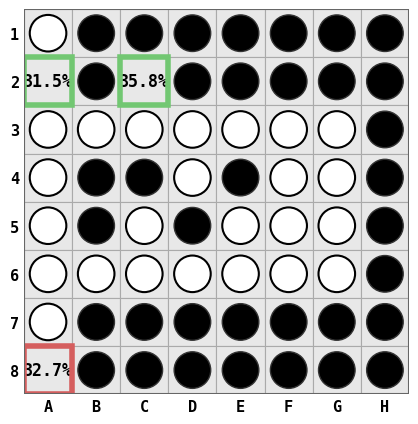

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/forfeit_seq_m58.png


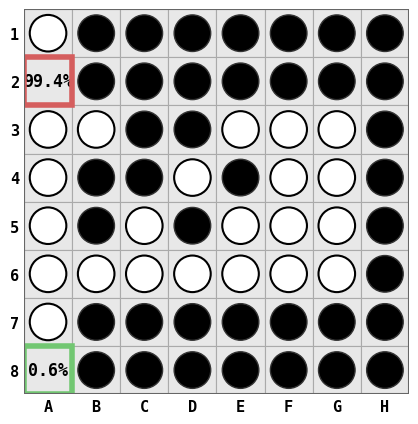

In [90]:
# Patterns of error - sequence with a dedicated Black-forfeit board.
# green box = legal, red = illegal; illegal squares assigned <2% get no box/label.
# The forfeit board shows every open square illegal for Black (all red, no probs).
import pickle as _pkls
from data.othello import OthelloBoardState as _OBS
_fes = _pkls.load(open(os.path.join(REPO_ROOT, 'forfeit_example_game.pkl'), 'rb'))
_seq = _pkls.load(open(os.path.join(REPO_ROOT, 'notebooks/talk_data/forfeit_sequence_probs.pkl'), 'rb'))
_ms = _fes['moves_seq']
_DIRS = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
def _flips(state, color, sq):
    _r, _c = sq // 8, sq % 8; _n = 0
    for _dr, _dc in _DIRS:
        _buf = 0; _cr, _cc = _r, _c
        while True:
            _cr += _dr; _cc += _dc
            if not (0 <= _cr < 8 and 0 <= _cc < 8): break
            if state[_cr, _cc] == 0: break
            elif state[_cr, _cc] == color: _n += _buf; break
            else: _buf += 1
    return _n
def _board_after(n):
    _b = _OBS()
    for _mv in _ms[:n]: _b.update([_mv])
    return np.asarray(_b.state, dtype=np.int8)

# (title, kind, n, filename)  kind 'move' = model probs for move n; 'forfeit' = Black-illegal board after n moves
_STEPS = [
    ('move 55: White',                 'move',    55, 'forfeit_seq_m55.png'),
    ('Black forfeits - no legal move',  'forfeit', 56, 'forfeit_seq_forfeit.png'),
    ('move 56: White plays',            'move',    56, 'forfeit_seq_m56.png'),
    ('move 57: Black',                  'move',    57, 'forfeit_seq_m57.png'),
    ('move 58: White (illegal 99.4%)',  'move',    58, 'forfeit_seq_m58.png'),
]
for _title, _kind, _n, _fname in _STEPS:
    _st = _board_after(_n)
    _hl = {}
    if _kind == 'forfeit':                          # Black to move: every empty illegal -> red, no labels
        for _cl in range(64):
            _r, _c = _cl // 8, _cl % 8
            if _st[_r, _c] == 0:
                _legal = _flips(_st, 1, _cl) > 0
                _hl[(_r, _c)] = {'border': 'green' if _legal else 'red', 'border_lw': 4.0}
    else:                                           # model's move probabilities
        for _cl, _info in _seq[_n]['squares'].items():
            _r, _c = _cl // 8, _cl % 8
            if not (_info['legal'] or _info['prob'] >= 0.02):
                continue
            _hl[(_r, _c)] = {'border': 'green' if _info['legal'] else 'red', 'border_lw': 4.0,
                             'label': f"{100 * _info['prob']:.1f}%"}
    fig, ax = plt.subplots(figsize=(5, 5)); fig.patch.set_facecolor('white')
    draw_board(ax, _st, highlights=_hl, title=None, show_coords=True, fontsize=12)
    _out = os.path.join(TALK_DIR, _fname)
    plt.savefig(_out, dpi=200, facecolor='white')
    print('  saved', _out); plt.show()

## Section 12 - Marginal legal move: legality flips, probability barely moves

Collaborator example (reconstructed from the SVG).  Flip the single piece at **F4** (orange box) and compare the model's per-cell legal-move probabilities before vs after.

The point is **H2**: the model makes it legal by only a hair - its probability (`.08`) is just barely above the illegal moves (which sit at ~`.00`).  Flipping F4 switches H2's *true* legality (**green -> red**), yet its probability barely moves (`.08 -> .08`) - it stays right at that marginal level.  H2 is boxed in **both** panels so the legality switch is visible against the flat probability.  Other legal cells are green-boxed with their probability; illegal cells (blank) are ~`.00`.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_H2_marginal.png


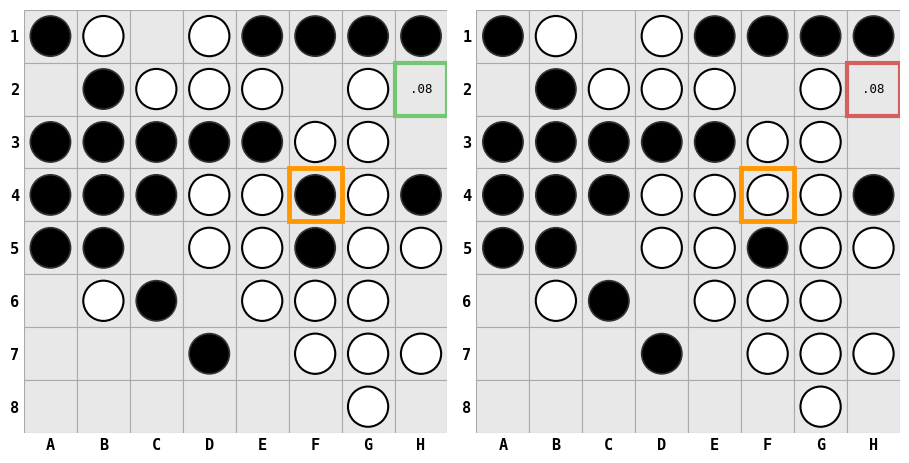

In [91]:
# Section 12 - H2 marginal-legal intervention (reconstructed from the SVG).
# Only the relevant square (H2) is boxed (green=legal / red=illegal) and labeled with its probability.
from matplotlib.patches import Rectangle as _Rect, Circle as _Circ
GREEN, RED, ORANGE = '#72c772', '#d55e5e', '#ff9800'
def _ix(s): return (int(s[1]) - 1) * 8 + 'ABCDEFGH'.index(s[0])
def _grid(rows):
    m = {'.': 0, 'B': 1, 'W': -1}
    return [[m[ch] for ch in row] for row in rows]
def _flip(state, cell):
    r, c = divmod(cell, 8); s = [row[:] for row in state]; s[r][c] *= -1; return s

def _panel(ax, state, relevant, rel_legal, rel_prob, intervened, title):
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 7.5); ax.set_aspect('equal'); ax.invert_yaxis()
    if title:
        ax.set_title(title, fontsize=11, fontfamily='monospace', fontweight='bold', pad=6)
    for r in range(8):
        for c in range(8):
            v = state[r][c]
            ax.add_patch(_Rect((c-0.5, r-0.5), 1, 1, facecolor='#e8e8e8',
                               edgecolor='#aaaaaa', lw=0.8, zorder=1))
            if v != 0:
                ax.add_patch(_Circ((c, r), 0.38, facecolor=('black' if v>0 else 'white'),
                                   edgecolor=('#333333' if v>0 else 'black'),
                                   lw=(1.2 if v>0 else 1.5), zorder=3))
    # relevant square: colored box + probability, in BOTH panels
    rr, rc = divmod(relevant, 8)
    ax.text(rc, rr, f'{rel_prob:.2f}'[1:], ha='center', va='center',
            fontsize=9, fontfamily='monospace', color='black', zorder=4)
    ax.add_patch(_Rect((rc-0.5, rr-0.5), 1, 1, fill=False,
                       edgecolor=(GREEN if rel_legal else RED), lw=3.0, zorder=5))
    ir, ic = divmod(intervened, 8)
    ax.add_patch(_Rect((ic-0.5, ir-0.5), 1, 1, fill=False, edgecolor=ORANGE, lw=3.5, zorder=6))
    ax.set_xticks(range(8)); ax.set_xticklabels(list('ABCDEFGH'), fontsize=11, fontfamily='monospace', fontweight='bold')
    ax.set_yticks(range(8)); ax.set_yticklabels(range(1, 9), fontsize=11, fontfamily='monospace', fontweight='bold')
    ax.tick_params(length=0)
    for s in ('top','right','bottom','left'): ax.spines[s].set_visible(False)

F4 = _ix('F4'); H2 = _ix('H2')
rows = ['BW.WBBBB','.BWWW.W.','BBBBBWW.','BBBWWBWB','BB.WWBWW','.WB.WWW.','...B.WWW','......W.']
before = _grid(rows); after = _flip(before, F4)
P_H2 = 0.08   # marginal legal prob, ~same before and after

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.9)); fig.patch.set_facecolor('white')
_panel(axes[0], before, H2, True,  P_H2, F4, None)
_panel(axes[1], after,  H2, False, P_H2, F4, None)
plt.tight_layout()
out = os.path.join(TALK_DIR, 'intervention_H2_marginal.png')
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('  saved', out); plt.show()

## Section 12b - Intervention element (orange up-arrow, size-scaled)

A standalone, transparent element to drop onto the intervention slides. The **orange** matches the target-square box (F4) in Sections 12/13, so colour still identifies *which* square is hit; the **arrow length encodes the intervention size**. Anchor each PNG by its **bottom-left** in the same slide spot and the arrow grows upward from a common baseline as size increases (the "turn up the intervention" reveal). Saves `intervention_arrow_size{1,2,3,4,8}.png` to `TALK_DIR`.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_arrow_size1.png


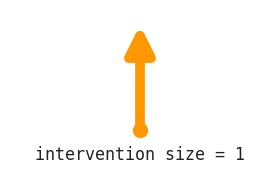

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_arrow_size2.png


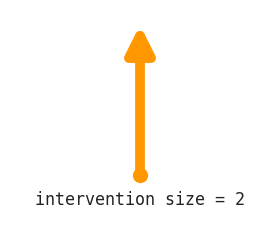

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_arrow_size3.png


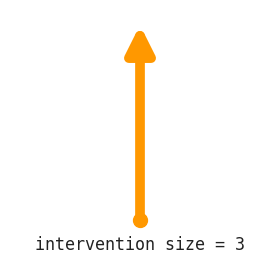

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_arrow_size4.png


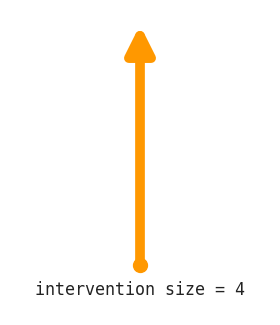

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_arrow_size5.png


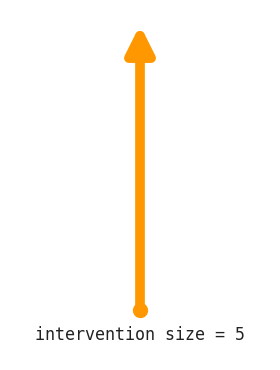

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_arrow_size8.png


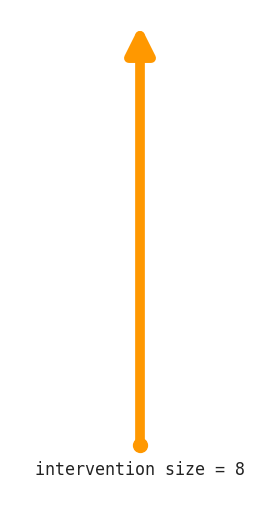

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_arrow_plain.png


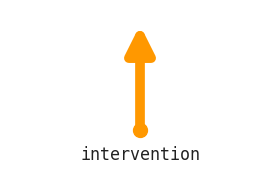

In [92]:
# Section 12b - standalone "intervention" element: orange up-arrow whose LENGTH
# encodes the intervention size, with 'intervention size = N' underneath.
# Transparent + tightly cropped so it can be placed freely on a slide.
INT_ORANGE = '#ff9800'            # matches the F4 target-square box (Sections 12/13)
_AW, _LABEL_H, _PAD = 2.6, 0.5, 0.15   # fixed width -> every arrow PNG same width
_BASE_H, _PER_H = 0.6, 0.45       # arrow length = BASE_H + PER_H*size
                                  # (set _BASE_H=0 for strictly proportional length)

def make_intervention_arrow(size, out_name=None, label=True, label_text=None):
    arrow_h = _BASE_H + _PER_H * size
    H = _LABEL_H + arrow_h + _PAD
    fig = plt.figure(figsize=(_AW, H))
    ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, _AW); ax.set_ylim(0, H); ax.axis('off')
    foot, head = _LABEL_H, _LABEL_H + arrow_h
    ax.annotate('', xy=(_AW/2, head), xytext=(_AW/2, foot),
                arrowprops=dict(arrowstyle='-|>', color=INT_ORANGE, lw=7,
                                mutation_scale=40, shrinkA=0, shrinkB=0))
    ax.plot([_AW/2], [foot], marker='o', ms=10, color=INT_ORANGE, zorder=4)
    if label:
        ax.text(_AW/2, _LABEL_H/2,
                label_text if label_text is not None else f'intervention size = {size}',
                ha='center', va='center', fontsize=12, color='#222222')
    if out_name:
        p = os.path.join(TALK_DIR, out_name)
        fig.savefig(p, dpi=200, transparent=True)   # no tight crop -> uniform width across sizes
        print('  saved', p)
    plt.show()

# Anchor each image bottom-left at the same slide spot -> arrow grows upward.
for _s in (1, 2, 3, 4, 5, 8):
    make_intervention_arrow(_s, out_name=f'intervention_arrow_size{_s}.png')
# plain version: same length as size 1, labelled just 'intervention'
make_intervention_arrow(1, out_name='intervention_arrow_plain.png', label_text='intervention')

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_H2_noprob.png


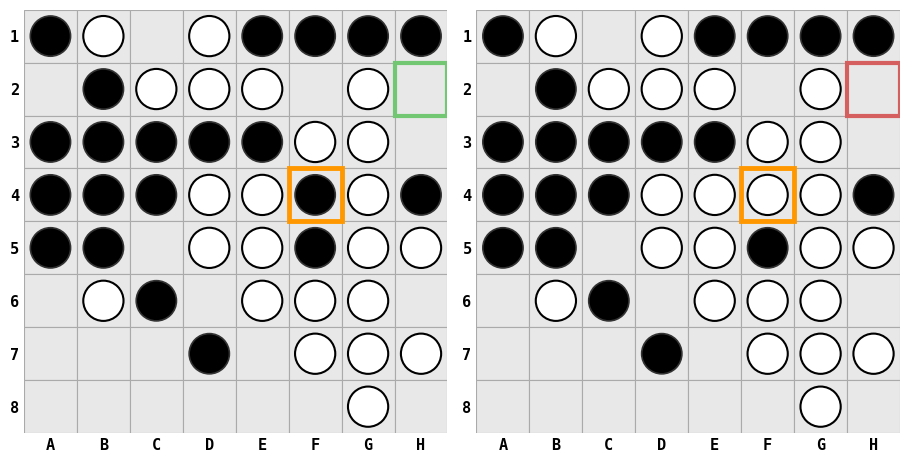

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_H2_before_noprob.png


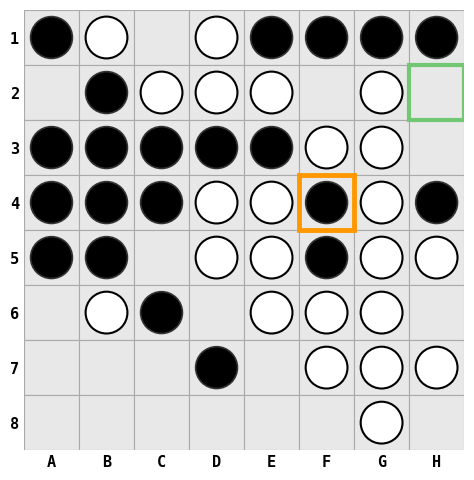

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_H2_after_noprob.png


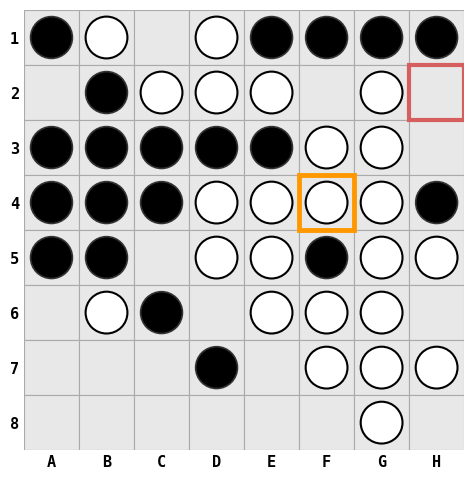

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_H2_noprob_nobox.png


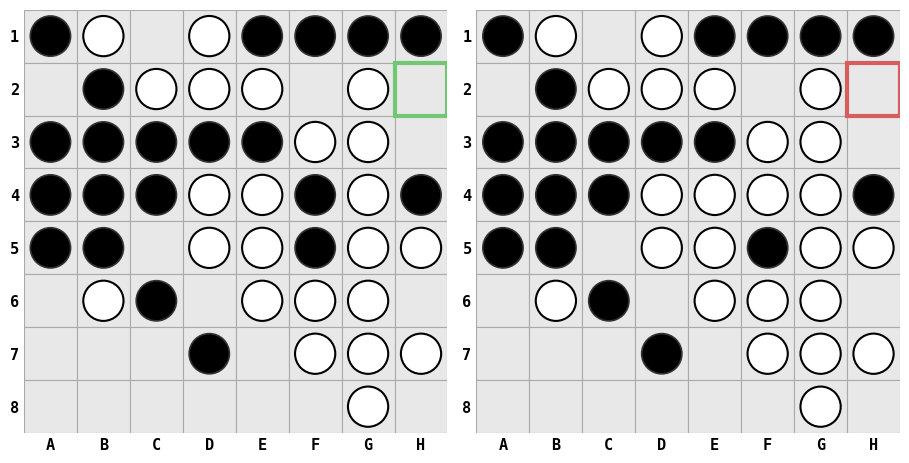

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_H2_before_noprob_nobox.png


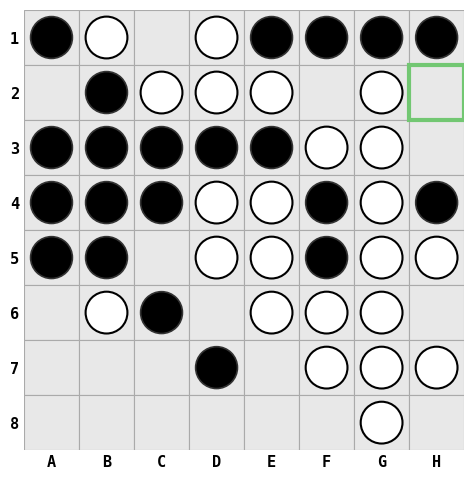

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_H2_after_noprob_nobox.png


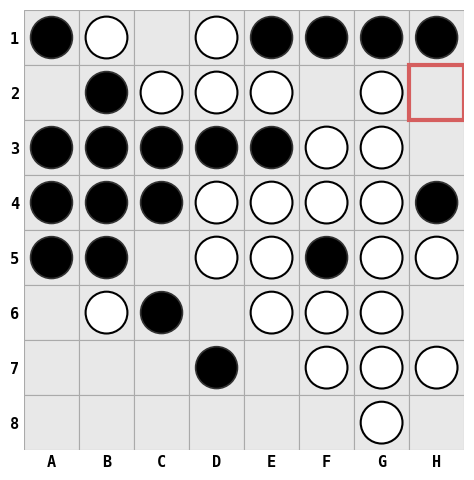

In [93]:
# Section 12b - no-probability version of the Section 12 board, to pair with the
# intervention-size arrows. Board + H2 legality box (green=legal, red=illegal);
# the .08 labels are removed. Flags: show_prob re-adds the numbers; show_titles
# toggles the Before/After captions; show_target toggles the orange F4 box
# (off -> the piece still visibly flips black<->white, just no highlight).
from matplotlib.patches import Rectangle as _Rect2, Circle as _Circ2
_GREEN, _RED, _ORANGE = '#72c772', '#d55e5e', '#ff9800'
def _ix2(s): return (int(s[1]) - 1) * 8 + 'ABCDEFGH'.index(s[0])
def _grid2(rows):
    m = {'.': 0, 'B': 1, 'W': -1}
    return [[m[ch] for ch in row] for row in rows]
def _flip2(state, cell):
    r, c = divmod(cell, 8); s = [row[:] for row in state]; s[r][c] *= -1; return s

def _panel_np(ax, state, relevant, rel_legal, intervened, title=None,
              show_prob=False, show_target=True, rel_prob=0.08):
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 7.5); ax.set_aspect('equal'); ax.invert_yaxis()
    if title:
        ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    for r in range(8):
        for c in range(8):
            v = state[r][c]
            ax.add_patch(_Rect2((c-0.5, r-0.5), 1, 1, facecolor='#e8e8e8',
                               edgecolor='#aaaaaa', lw=0.8, zorder=1))
            if v != 0:
                ax.add_patch(_Circ2((c, r), 0.38, facecolor=('black' if v>0 else 'white'),
                                   edgecolor=('#333333' if v>0 else 'black'),
                                   lw=(1.2 if v>0 else 1.5), zorder=3))
    rr, rc = divmod(relevant, 8)
    if show_prob:
        ax.text(rc, rr, f'{rel_prob:.2f}'[1:], ha='center', va='center', fontsize=9, zorder=4)
    ax.add_patch(_Rect2((rc-0.5, rr-0.5), 1, 1, fill=False,
                       edgecolor=(_GREEN if rel_legal else _RED), lw=3.0, zorder=5))
    if show_target:
        ir, ic = divmod(intervened, 8)
        ax.add_patch(_Rect2((ic-0.5, ir-0.5), 1, 1, fill=False, edgecolor=_ORANGE, lw=3.5, zorder=6))
    ax.set_xticks(range(8)); ax.set_xticklabels(list('ABCDEFGH'), fontsize=11, fontweight='bold')
    ax.set_yticks(range(8)); ax.set_yticklabels(range(1, 9), fontsize=11, fontweight='bold'); ax.tick_params(length=0)
    for s in ('top','right','bottom','left'): ax.spines[s].set_visible(False)

_F4, _H2 = _ix2('F4'), _ix2('H2')
_rows = ['BW.WBBBB','.BWWW.W.','BBBBBWW.','BBBWWBWB','BB.WWBWW','.WB.WWW.','...B.WWW','......W.']
_before = _grid2(_rows); _after = _flip2(_before, _F4)

def render_H2_noprob(show_prob=False, show_titles=True, show_target=True, out_name=None):
    """Two-panel Before/After board, probabilities off by default."""
    if out_name is None:
        out_name = 'intervention_H2_noprob.png' if show_target else 'intervention_H2_noprob_nobox.png'
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.9)); fig.patch.set_facecolor('white')
    _panel_np(axes[0], _before, _H2, True,  _F4, 'Before' if show_titles else None, show_prob, show_target)
    _panel_np(axes[1], _after,  _H2, False, _F4, 'After'  if show_titles else None, show_prob, show_target)
    plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name)
    plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white'); print('  saved', out); plt.show()

def render_H2_single(after=False, show_target=True, out_name=None):
    """Single board (no caption) for free composition beside the arrows."""
    state, leg = (_after, False) if after else (_before, True)
    if out_name is None:
        tag = '' if show_target else '_nobox'
        out_name = f"intervention_H2_{'after' if after else 'before'}_noprob{tag}.png"
    fig, ax = plt.subplots(figsize=(4.9, 4.9)); fig.patch.set_facecolor('white')
    _panel_np(ax, state, _H2, leg, _F4, show_target=show_target)
    plt.tight_layout()
    out = os.path.join(TALK_DIR, out_name)
    plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='white'); print('  saved', out); plt.show()

# with the orange F4 target box
render_H2_noprob(show_target=True, show_titles=False)
render_H2_single(after=False, show_target=True)
render_H2_single(after=True,  show_target=True)
# without the orange box (piece still flips colour)
render_H2_noprob(show_target=False, show_titles=False)
render_H2_single(after=False, show_target=False)
render_H2_single(after=True,  show_target=False)

## Section 13 - True legality flips, model probability barely moves (right direction)

From your `multi_intervention_probs` data (single-piece color flips), Othello-verified.  A flip changes the *true* legality of a square, and the model's probability moves the **right way but only a hair** - it under-responds to the flip (same theme as H2):

- **newly legal** (F1): flip C4; F1 becomes legal; prob `.000 -> .002` (**+.0015**), box **red -> green**
- **newly illegal** (H7): flip D3; H7 becomes illegal; prob `.096 -> .094` (**-.002**), box **green -> red**

Box = **true legality** (green=legal, red=illegal); the relevant square is labelled with its probability (3 decimals).  Orange = the flipped piece.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/legalityflip_newly_legal_before.png


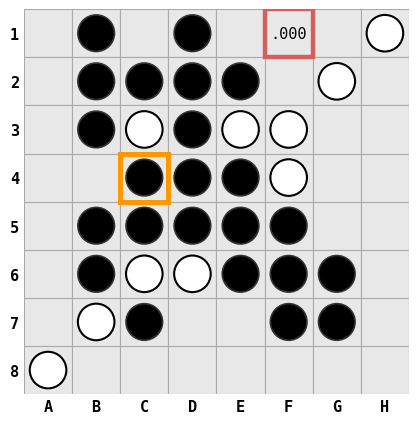

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/legalityflip_newly_legal_after.png


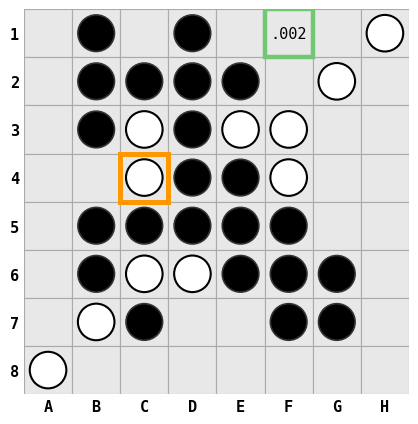

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/legalityflip_newly_illegal_before.png


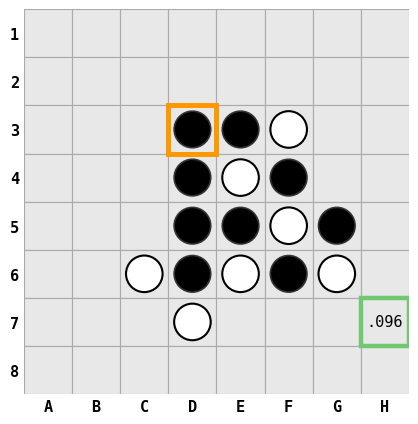

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/legalityflip_newly_illegal_after.png


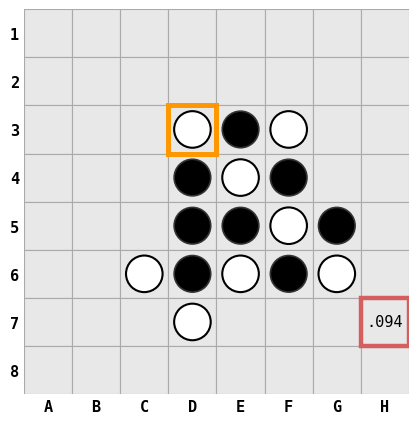

In [94]:
# Section 13 - true-legality flip with a tiny probability move; separate before/after board images,
# no titles/coordinates (Othello-verified).
from matplotlib.patches import Rectangle as _Rect, Circle as _Circ
GREEN, RED, ORANGE = '#72c772', '#d55e5e', '#ff9800'
def _ix(s): return (int(s[1]) - 1) * 8 + 'ABCDEFGH'.index(s[0])
def _grid(rows):
    m = {'.': 0, 'B': 1, 'W': -1}
    return [[m[ch] for ch in row] for row in rows]
def _flip(state, cell):
    r, c = divmod(cell, 8); s = [row[:] for row in state]; s[r][c] *= -1; return s

def _board(state, relevant, is_legal, prob, flipped, out_name):
    fig, ax = plt.subplots(figsize=(5, 5)); fig.patch.set_facecolor('white')
    ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 7.5); ax.set_aspect('equal'); ax.invert_yaxis()
    for r in range(8):
        for c in range(8):
            v = state[r][c]
            ax.add_patch(_Rect((c-0.5, r-0.5), 1, 1, facecolor='#e8e8e8',
                               edgecolor='#aaaaaa', lw=0.8, zorder=1))
            if v != 0:
                ax.add_patch(_Circ((c, r), 0.38, facecolor=('black' if v>0 else 'white'),
                                   edgecolor=('#333333' if v>0 else 'black'),
                                   lw=(1.2 if v>0 else 1.5), zorder=3))
    rr, rc = divmod(relevant, 8)
    ax.text(rc, rr, f'{prob:.3f}'[1:], ha='center', va='center',
            fontsize=11, fontfamily='monospace', color='black', zorder=4)
    ax.add_patch(_Rect((rc-0.5, rr-0.5), 1, 1, fill=False,
                       edgecolor=(GREEN if is_legal else RED), lw=3.2, zorder=5))
    ir, ic = divmod(flipped, 8)
    ax.add_patch(_Rect((ic-0.5, ir-0.5), 1, 1, fill=False, edgecolor=ORANGE, lw=3.6, zorder=6))
    ax.set_xticks(range(8)); ax.set_xticklabels(list('ABCDEFGH'), fontsize=11, fontfamily='monospace', fontweight='bold')
    ax.set_yticks(range(8)); ax.set_yticklabels([str(i) for i in range(1, 9)], fontsize=11, fontfamily='monospace', fontweight='bold')
    ax.tick_params(length=0)
    for _sp in ('top', 'right', 'bottom', 'left'): ax.spines[_sp].set_visible(False)
    out = os.path.join(TALK_DIR, out_name)
    plt.savefig(out, dpi=200, facecolor='white')
    print('  saved', out); plt.show()

EXAMPLES = [
  dict(name='newly_legal', mover='White', relevant='F1', flip='C4',
       rows=['.B.B...W','.BBBB.W.','.BWBWW..','..BBBW..','.BBBBB..','.BWWBBB.','.WB..BB.','W.......'],
       p_before=0.0001, p_after=0.0016, legal_before=False, legal_after=True),
  dict(name='newly_illegal', mover='Black', relevant='H7', flip='D3',
       rows=['........','........','...BBW..','...BWB..','...BBWB.','..WBWBW.','...W....','........'],
       p_before=0.096, p_after=0.094, legal_before=True, legal_after=False),
]
for ex in EXAMPLES:
    rel = _ix(ex['relevant']); fl = _ix(ex['flip'])
    before = _grid(ex['rows']); after = _flip(before, fl)
    _board(before, rel, ex['legal_before'], ex['p_before'], fl, f"legalityflip_{ex['name']}_before.png")
    _board(after,  rel, ex['legal_after'],  ex['p_after'],  fl, f"legalityflip_{ex['name']}_after.png")

### Section 13c - Concept: what matters is how much probability is shifted

General illustration: an intervention makes one square **lose** probability (red) and another **gain** probability (green).  The quantity to measure is the **size of the probability shift** - shown as arrows in the margins, off the board so they're easy to read.

  saved /Users/jmorriso/Git/othello_world/notebooks/talk_boards/intervention_prob_shift_concept.png


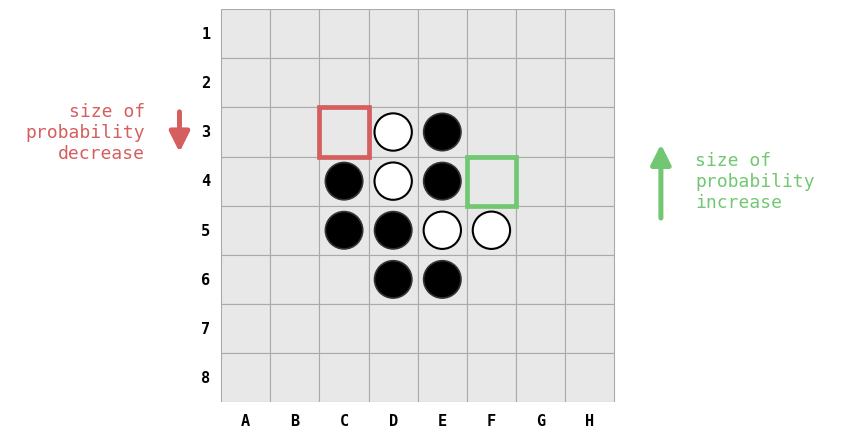

In [95]:
# Section 13c - concept figure: size of probability shift (arrows off the board).
# Board is sized to EXACTLY 3.93in x 3.93in (matches the other figures); coord font matches too.
from matplotlib.patches import Rectangle as _Rect, Circle as _Circ
GREEN, RED = '#72c772', '#d55e5e'
def _ix(s): return (int(s[1]) - 1) * 8 + 'ABCDEFGH'.index(s[0])
def _grid(rows):
    m = {'.': 0, 'B': 1, 'W': -1}
    return [[m[ch] for ch in row] for row in rows]
_rows = ['........','........','...WB...','..BWB...','..BBWW..','...BB...','........','........']
_state = _grid(_rows)
DEC = _ix('C3')   # loses probability (red box)
INC = _ix('F4')   # gains probability (green box)

# --- exact board size: 3.93 in for the 8-cell board (data-square axes box) ---
BOARD_IN = 3.93
_PX = BOARD_IN / 8.0                       # inches per board cell/unit
_XLIM = (-4.8, 12.4); _YLIM = (-0.5, 7.5)  # board + off-board margins for arrows/labels
_XR = _XLIM[1]-_XLIM[0]; _YR = _YLIM[1]-_YLIM[0]
_AW = _XR*_PX; _AH = _YR*_PX               # axes size (inches); _AW/_XR == _AH/_YR -> square cells
_TOP, _BOT = 0.72, 0.42                    # inch margins for the title / bottom coords
_FW = _AW; _FH = _TOP + _AH + _BOT
fig = plt.figure(figsize=(_FW, _FH)); fig.patch.set_facecolor('white')
ax = fig.add_axes([0.0, _BOT/_FH, _AW/_FW, _AH/_FH])   # data-square box (no set_aspect needed)
ax.set_xlim(*_XLIM); ax.set_ylim(*_YLIM); ax.invert_yaxis()
for r in range(8):
    for c in range(8):
        v = _state[r][c]
        ax.add_patch(_Rect((c-0.5, r-0.5), 1, 1, facecolor='#e8e8e8', edgecolor='#aaaaaa', lw=0.8, zorder=1))
        if v != 0:
            ax.add_patch(_Circ((c, r), 0.38, facecolor=('black' if v>0 else 'white'),
                               edgecolor=('#333333' if v>0 else 'black'), lw=(1.2 if v>0 else 1.5), zorder=3))
dr, dc = divmod(DEC, 8); ir, ic = divmod(INC, 8)
ax.add_patch(_Rect((dc-0.5, dr-0.5), 1, 1, fill=False, edgecolor=RED, lw=3.4, zorder=5))
ax.add_patch(_Rect((ic-0.5, ir-0.5), 1, 1, fill=False, edgecolor=GREEN, lw=3.4, zorder=5))
# coordinates - same font as the other board figures (monospace, size 8)
for c in range(8):
    ax.text(c, 7.72, 'ABCDEFGH'[c], ha='center', va='top', fontsize=11, fontfamily='monospace', fontweight='bold')
for r in range(8):
    ax.text(-0.72, r, str(r+1), ha='right', va='center', fontsize=11, fontfamily='monospace', fontweight='bold')
# Arrow LENGTHS schematically encode the size of the shift (magnitudes on a 0..1 scale).
DEC_MAG, INC_MAG, ARROW_SCALE = 0.55, 0.95, 1.7
_ld = DEC_MAG * ARROW_SCALE; _li = INC_MAG * ARROW_SCALE   # full arrow lengths (in cells)
# LEFT margin: red DOWN arrow (length = decrease magnitude) + label at the losing square's row
ax.annotate('', xy=(-1.35, dr + _ld/2), xytext=(-1.35, dr - _ld/2),
            arrowprops=dict(arrowstyle='-|>', color=RED, lw=3.6, mutation_scale=30))
ax.text(-2.05, dr, 'size of\nprobability\ndecrease', ha='right', va='center',
        fontsize=13, fontfamily='monospace', color=RED)
# RIGHT margin: green UP arrow (length = increase magnitude) + label at the gaining square's row
ax.annotate('', xy=(8.45, ir - _li/2), xytext=(8.45, ir + _li/2),
            arrowprops=dict(arrowstyle='-|>', color=GREEN, lw=3.6, mutation_scale=30))
ax.text(9.15, ir, 'size of\nprobability\nincrease', ha='left', va='center',
        fontsize=13, fontfamily='monospace', color=GREEN)
ax.axis('off')
out = os.path.join(TALK_DIR, 'intervention_prob_shift_concept.png')
fig.savefig(out, dpi=200, facecolor='white')   # no bbox='tight' -> board stays exactly 3.93in
print('  saved', out); plt.show()

## Section 14 - Heuristics from decision trees

How the interpretable heuristics are derived: one flanking **pattern** (top) and
two small **decision trees** (below) that decide whether the pattern is present.
Nodes test only the model's actual features - *played on an even turn* / *odd
turn* (never colour/mine-yours). Each highlighted **root-to-leaf path = one
heuristic**; the "pattern active" leaf matches the "pattern absent" style but
with an orange border + text. Saves `heuristic_tree_pattern.png` to `TALK_DIR`.

In [ ]:
# Section 14 - flanking pattern (small board) + two decision trees.
import torch
from matplotlib.patches import FancyBboxPatch

_ORANGE, _GREEN = '#ff9800', '#72c772'
_GREY_FILL, _GREY_EC, _GREY_TC = '#f0f0f0', '#bbbbbb', '#777777'
def _alg(idx): return 'ABCDEFGH'[idx % 8] + str(idx // 8 + 1)
def _rc(i): return (i // 8, i % 8)

_pats = torch.load(os.path.join(REPO_ROOT, 'hand_crafted_flanking_patterns.pt'),
                   map_location='cpu', weights_only=False)['patterns']
def _central(p):
    return all(0 < r < 7 and 0 < c < 7
               for r, c in map(_rc, [p['target'], p['terminal']] + p['opponents']))
_cand = [p for p in _pats if p['length'] == 2 and p['direction'] == (0, 1) and _central(p)]
_pat = _cand[len(_cand) // 2] if _cand else _pats[0]
_T, _K, _OPP = _pat['target'], _pat['terminal'], _pat['opponents']

_state = np.zeros((8, 8), dtype=np.int8)
_state[_rc(_K)] = 1
for _o in _OPP: _state[_rc(_o)] = -1

def _node(ax, x, y, text, fc=_GREY_FILL, ec='#888888', tc='#111111', w=0.32, h=0.17, lw=1.8, fs=12):
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle='round,pad=0.012',
                                facecolor=fc, edgecolor=ec, linewidth=lw, zorder=3))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, color=tc, zorder=4)

def _edge(ax, x0, y0, x1, y1, label, hi=False):
    ax.plot([x0, x1], [y0 - 0.085, y1 + 0.085], color=(_ORANGE if hi else '#999999'),
            lw=(3.8 if hi else 1.6), zorder=1)
    ax.text((x0 + x1) / 2 + 0.035, (y0 + y1) / 2, label, ha='left', va='center',
            fontsize=11, color=(_ORANGE if hi else '#666666'), fontweight='bold', zorder=4)

def _draw_tree(ax, root_q, mid_q):
    ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    _node(ax, 0.48, 0.88, root_q)
    _edge(ax, 0.48, 0.88, 0.22, 0.52, 'no')
    _node(ax, 0.22, 0.52, 'pattern\nabsent', fc=_GREY_FILL, ec=_GREY_EC, tc=_GREY_TC)
    _edge(ax, 0.48, 0.88, 0.64, 0.52, 'yes', hi=True)
    _node(ax, 0.64, 0.52, mid_q)
    _edge(ax, 0.64, 0.52, 0.42, 0.14, 'no')
    _node(ax, 0.42, 0.14, 'pattern\nabsent', fc=_GREY_FILL, ec=_GREY_EC, tc=_GREY_TC)
    _edge(ax, 0.64, 0.52, 0.80, 0.14, 'yes', hi=True)
    _node(ax, 0.80, 0.14, 'pattern\nactive', fc=_GREY_FILL, ec=_ORANGE, tc=_ORANGE, lw=2.4)

fig = plt.figure(figsize=(10, 8)); fig.patch.set_facecolor('white')
axb = fig.add_axes([0.375, 0.72, 0.25, 0.25])          # small centered board (~half size)
draw_board(axb, _state, highlights={_rc(_T): {'border': _ORANGE, 'border_lw': 4.0}}, show_coords=True)

ax1 = fig.add_axes([0.02, 0.02, 0.47, 0.64])
ax2 = fig.add_axes([0.51, 0.02, 0.47, 0.64])
# two DISSIMILAR heuristics for this pattern: one reads the opponent run,
# the other reads the endpoints (landing empty + terminal placed by mover)
_c1, _c2 = _alg(_OPP[0]), _alg(_OPP[1])
_draw_tree(ax1, f'{_c1} played\non odd turn?', f'{_c2} played\non odd turn?')   # the run
_draw_tree(ax2, f'{_alg(_T)} empty?', f'{_alg(_K)} played\non even turn?')        # the endpoints

_out = os.path.join(TALK_DIR, 'heuristic_tree_pattern.png')
fig.savefig(_out, dpi=200, bbox_inches='tight', facecolor='white'); print('  saved', _out); plt.show()

## Section 15 - Intervention: a little boost, then collateral

A cleaner "limited success" example than Section 13 (found by `find_collateral_example.py`).
Position: **flip F4 -> move G3** (White to move).  A small intervention boosts G3's
probability a little **with no collateral**; pushing harder makes the boost **collapse**
while it **corrupts more and more other squares**.  Renders the board (`collateral_example_F4G3.png`)
and the size sweep (`collateral_example_F4G3_sweep.png`).

In [ ]:
# Section 15 - collateral example: flip F4 -> newly-legal move G3 (White to move).
# Data precomputed by find_collateral_example.py (OGPT, projection push at block 4,
# collateral = board cells whose Nanda-probe decode changes vs the un-intervened decode).
from matplotlib.patches import Rectangle as _Rect, Circle as _Circ
_GREEN, _ORANGE = '#72c772', '#ff9800'
_BOARD = [0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, -1, 1, 1, 1, 0, 0, 1, 0, 1, -1, 0, 0, 0, 0, 1, 0, -1, -1, -1, 0, 0, 1, 1, -1, 1, -1, -1, 1, 1, 0, 1, 0, 1, 0, -1, 1, 0, 0, 0, -1, 1, 1, 1, -1, -1, 0, -1, 0, 1, -1, 0, 0, -1]
_FLIP, _MOVE = 'F4', 'G3'
# (intervention_size, P(move), collateral_squares)
_SWEEP = [(1.0, 0.01104236114770174, 0), (2.0, 0.07411915063858032, 0), (3.0, 0.06647775322198868, 0), (4.0, 0.023754237219691277, 1), (5.0, 0.004485998768359423, 3), (6.0, 0.0015438484260812402, 6), (8.0, 0.0008525193552486598, 12), (10.0, 0.0009171576239168644, 15), (12.0, 0.0009314804337918758, 19), (16.0, 0.0004709380737040192, 24)]

def _ix(s): return (int(s[1]) - 1) * 8 + 'ABCDEFGH'.index(s[0])

# --- board figure: flipped piece (orange), newly-legal move (green) ---
_st = np.array(_BOARD).reshape(8, 8)
fig, ax = plt.subplots(figsize=(5, 5)); fig.patch.set_facecolor('white')
ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 7.5); ax.set_aspect('equal'); ax.invert_yaxis()
for r in range(8):
    for c in range(8):
        v = _st[r, c]
        ax.add_patch(_Rect((c-0.5, r-0.5), 1, 1, facecolor='#e8e8e8', edgecolor='#aaaaaa', lw=0.8, zorder=1))
        if v != 0:
            ax.add_patch(_Circ((c, r), 0.40, facecolor=('black' if v>0 else 'white'),
                               edgecolor=('#333333' if v>0 else 'black'), lw=(1.2 if v>0 else 1.5), zorder=3))
_fr, _fc = divmod(_ix(_FLIP), 8); _mr, _mc = divmod(_ix(_MOVE), 8)
ax.add_patch(_Rect((_fc-0.5, _fr-0.5), 1, 1, fill=False, edgecolor=_ORANGE, lw=3.6, zorder=6))
ax.add_patch(_Rect((_mc-0.5, _mr-0.5), 1, 1, fill=False, edgecolor=_GREEN, lw=3.4, zorder=6))
ax.set_xticks(range(8)); ax.set_xticklabels(list('ABCDEFGH'), fontsize=11, fontweight='bold')
ax.set_yticks(range(8)); ax.set_yticklabels(range(1, 9), fontsize=11, fontweight='bold'); ax.tick_params(length=0)
for _s in ('top','right','bottom','left'): ax.spines[_s].set_visible(False)
_out = os.path.join(TALK_DIR, 'collateral_example_F4G3.png')
plt.savefig(_out, dpi=200, facecolor='white'); print('  saved', _out); plt.show()

# --- size sweep: P(move) vs collateral squares (twin axis) ---
_sz = [r[0] for r in _SWEEP]; _pm = [r[1] for r in _SWEEP]; _co = [r[2] for r in _SWEEP]
fig, ax1 = plt.subplots(figsize=(8.0, 4.5)); fig.patch.set_facecolor('white'); ax1.set_facecolor('white')
ax1.plot(_sz, _pm, '-o', color=_GREEN, lw=2.2, label='P(move)')
ax1.set_xlabel('intervention size', fontsize=12); ax1.set_ylabel('P(move)', color=_GREEN, fontsize=12)
ax1.tick_params(axis='y', labelcolor=_GREEN)
ax2 = ax1.twinx()
ax2.plot(_sz, _co, '--s', color='#333333', lw=2.0, label='corrupted squares')
ax2.set_ylabel('corrupted squares', color='#333333', fontsize=12)
for _sp in ('top',): ax1.spines[_sp].set_visible(False); ax2.spines[_sp].set_visible(False)
_out2 = os.path.join(TALK_DIR, 'collateral_example_F4G3_sweep.png')
plt.tight_layout(); plt.savefig(_out2, dpi=200, facecolor='white'); print('  saved', _out2); plt.show()

## Section 15b - A3→A2 collateral example: per-size boards

Reconstructed generator for the `a3a2_*` talk figures (the per-size board view, vs. Section 15's single-board + sweep-plot view). Base position where **A2 is illegal** for white; the **intervention flips A3** (white→black), which makes A2 legal and lifts P(A2) from .000 → .001. As the intervention **size** grows, **collateral corruption** spreads to more cells (orange boxes; here every corrupted cell decodes to black) while P(A2) climbs (.003 → .029 → .105 → .106).

Emits the 8 original PNGs (`a3a2_size01_{before,after}_{prob,noprob}.png`, `a3a2_size{04,05,08,10}.png`) **plus** `a3a2_size01_before_noprob_nobox.png` — identical to the before/no-prob board but **without the orange box** on the intervention square (the piece still shows, just unhighlighted). Box legend: **orange** = intervention/collateral cell, **green** = target legal, **red** = target illegal.

In [ ]:
# Section 15b - A3->A2 collateral example (per-size boards). Renders via board_style.draw_board
# so the format (white margin, outer border, coords, stones) matches every other board figure.
_A_ROWS = ['...B.B.B', '...BBBB.', 'WWWWBB..', 'WWWWWBBB', '...BBBB.',
           '........', '........', '........']
_A_MAP = {'.': 0, 'B': 1, 'W': -1}
def _a_cell(alg):                      # 'A2' -> (row, col), row 0 = rank 1
    return (int(alg[1]) - 1, 'ABCDEFGH'.index(alg[0]))

# boxed: cells outlined orange (intervention + collateral). flips: {cell: value} corrupted-
# decode overrides on the base board. intervention_boxes=False drops the orange outlines.
def render_a3a2(boxed, target='A2', target_legal=False, prob=0.0, show_prob=False,
                intervention_boxes=True, flips=None, out_name='a3a2.png'):
    state = np.array([[_A_MAP[ch] for ch in row] for row in _A_ROWS])
    for cell, v in (flips or {}).items():
        r, c = _a_cell(cell); state[r, c] = v
    highlights = {}
    if intervention_boxes:
        for cell in boxed:
            highlights[_a_cell(cell)] = {'border': 'orange', 'border_lw': OUTLINE_LW}
    tspec = {'border': ('green' if target_legal else 'red'), 'border_lw': OUTLINE_LW}
    if show_prob:
        tspec['label'] = ('%.3f' % prob)[1:]
    highlights[_a_cell(target)] = tspec
    fig, ax = plt.subplots(figsize=(5, 5)); fig.patch.set_facecolor('white')
    draw_board(ax, state, highlights=highlights, show_coords=True)
    out = os.path.join(TALK_DIR, out_name)
    plt.savefig(out, dpi=200, facecolor='white')     # match render_board (no bbox_inches='tight')
    print('  saved', out); plt.show()

# size 1: before/after x prob/noprob  (intervention = flip A3 white->black)
for _sp in (False, True):
    _tag = '_prob' if _sp else '_noprob'
    render_a3a2(['A3'], target_legal=False, prob=0.000, show_prob=_sp, flips=None,
                out_name='a3a2_size01_before%s.png' % _tag)
    render_a3a2(['A3'], target_legal=True,  prob=0.001, show_prob=_sp, flips={'A3': 1},
                out_name='a3a2_size01_after%s.png' % _tag)

# NEW: size-1 before, no prob, WITHOUT the orange intervention box
render_a3a2(['A3'], target_legal=False, prob=0.000, show_prob=False,
            intervention_boxes=False, flips=None,
            out_name='a3a2_size01_before_noprob_nobox.png')

# size sweep: collateral corruption grows (every corrupted cell -> black)
_A_SWEEP = {4:  (['A3','A4'],               0.003),
            5:  (['A3','A4','A7'],          0.029),
            8:  (['A1','A3','A4','A7'],      0.105),
            10: (['A1','A3','B3','A4','B4','A7'], 0.106)}
for _size, (_cells, _p) in _A_SWEEP.items():
    render_a3a2(_cells, target_legal=True, prob=_p, show_prob=True,
                flips={_c: 1 for _c in _cells}, out_name='a3a2_size%02d.png' % _size)

## Section 16 - Othello-GPT intervention margins (survival + density)

For each intervention, board cells are classified **always-legal**, **always-illegal**,
**newly-legal** (legal only in the counterfactual), **newly-illegal** (legal only in the
original). Four probability margins are computed per relevant cell; a **surgical** edit
keeps newly-legal/illegal cells on the correct side of the always-legal/illegal ranges.

- **Survival** = fraction of (sample, cell) margins >= threshold (reproduces
  `plot_intervention_4panel.py`).
- **Density** = the distribution of those margins.

Data: `experiments/multi_intervention_probs_cd0/raw_samples.json`. Deck B&W style.

In [ ]:
# Section 16 - intervention margin curves (survival + density), deck B&W style.
import json
import matplotlib.ticker as mticker

CD0_DIR = os.path.join(REPO_ROOT, 'experiments/multi_intervention_probs_cd0')
X_MIN, X_MAX = -0.20, 0.20


def _load_interventions(results_dir):
    data = json.load(open(os.path.join(results_dir, 'raw_samples.json')))
    out = []
    for cond in data:
        for n_str in data[cond]:
            for s in data[cond][n_str]:
                if not all(k in s for k in ('orig_probs', 'intv_probs',
                                            'original_legal', 'counterfactual_legal')):
                    continue
                out.append((np.array(s['intv_probs']),
                            set(s['original_legal']), set(s['counterfactual_legal'])))
    return out


def _four_margins(samples):
    m1, m2, m3, m4 = [], [], [], []
    for ip, orig, cf in samples:
        AL, NL, NI = orig & cf, cf - orig, orig - cf
        AI = set(range(64)) - (orig | cf)
        ai = [ip[c] for c in AI if ip[c] >= 0]
        al = [ip[c] for c in AL if ip[c] >= 0]
        if not ai or not al:
            continue
        max_ai, min_al, max_al = max(ai), min(al), max(al)
        for c in NL:
            if ip[c] < 0:
                continue
            m1.append(ip[c] - max_ai)      # P(newly legal) - max P(always illegal)
            m2.append(min_al - ip[c])      # min P(always legal) - P(newly legal)
        for c in NI:
            if ip[c] < 0:
                continue
            m3.append(max_al - ip[c])      # max P(always legal) - P(newly illegal)
            m4.append(ip[c] - max_ai)      # P(newly illegal) - max P(always illegal)
    return [np.array(v) for v in (m1, m2, m3, m4)]


_samples = _load_interventions(CD0_DIR)
m1, m2, m3, m4 = _four_margins(_samples)
print(f'{len(_samples)} interventions; N per margin =', [len(v) for v in (m1, m2, m3, m4)])

PANELS = [(m1, 'P(newly legal) - max P(always illegal)'),
          (m2, 'min P(always legal) - P(newly legal)'),
          (m3, 'max P(always legal) - P(newly illegal)'),
          (m4, 'P(newly illegal) - max P(always illegal)')]


def _bw(ax):
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('black'); ax.spines[s].set_linewidth(1.2)
    for s in ('right', 'top'):
        ax.spines[s].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.0, colors='black', labelsize=9)


def _annot(ax, vals):
    ax.text(0.04, 0.92, f'>=0: {np.mean(vals >= 0) * 100:.1f}%',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=0.8))


# ---- survival curves ----
thr = np.linspace(X_MIN, X_MAX, 400)
fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), sharex=True, sharey=True)
fig.patch.set_facecolor('white')
for ax, (vals, title) in zip(axes.ravel(), PANELS):
    ax.plot(thr, [np.mean(vals >= t) for t in thr], color='black', lw=1.3)
    ax.axvline(0, color='black', ls=(0, (2, 3)), lw=0.8, alpha=0.6)
    _annot(ax, vals); ax.set_title(title, fontsize=8.5); _bw(ax)
    ax.set_xlim(X_MIN, X_MAX); ax.set_ylim(0, 1.03)
for ax in axes[1, :]:
    ax.set_xlabel('Probability margin', fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel('Fraction >= threshold', fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(TALK_DIR, 'intervention_survival_bw.png'), dpi=200, bbox_inches='tight')
plt.show()

# ---- density distributions ----
bins = np.linspace(X_MIN, X_MAX, 61)
fig, axes = plt.subplots(2, 2, figsize=(9, 6.5), sharex=True)
fig.patch.set_facecolor('white')
for ax, (vals, title) in zip(axes.ravel(), PANELS):
    ax.hist(np.clip(vals, X_MIN, X_MAX), bins=bins, histtype='step',
            color='black', lw=1.2, density=True)   # edge bins accumulate the tails
    ax.axvline(0, color='black', ls=(0, (2, 3)), lw=0.8, alpha=0.6)
    _annot(ax, vals); ax.set_title(title, fontsize=8.5); _bw(ax)
    ax.set_xlim(X_MIN, X_MAX)
for ax in axes[1, :]:
    ax.set_xlabel('Probability margin', fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel('Density', fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(TALK_DIR, 'intervention_density_bw.png'), dpi=200, bbox_inches='tight')
plt.show()
